# Deep SRQ PATH MCP N-player Pool Evaluation



In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    display_evaluation_boxplots,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)

SCENARIOS = robust_lbf_scenarios()
for scenario in SCENARIOS:
    print(f"{scenario.key}: {scenario.name}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes
lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes


In [2]:
EVAL_EPISODES = 50 
USE_GPU = True
SRE_SOLVER_WORKERS = DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS
EVAL_NUM_ENVS = 16
PATH_POOL_NPLAYER_SOLVER = "path_mcp_nplayer_pool"
PATH_MCP_HYPERPARAMETER_OVERRIDES = {
    "agent": {
        "sre_num_repeats": 5,
        "target_equilibrium_update_steps": 4,
        "sre_policy_cache_enabled": True,
        "sre_policy_cache_size": 8192,
        "sre_candidate_selection": "joint_nominal_welfare",
        "sre_exploitability_filter_enabled": False,
        "sre_approx_cache_enabled": False,
    },
}

print(f"Evaluation episodes per matchup: {EVAL_EPISODES}")
print(f"PATH MCP N-player pool workers: {SRE_SOLVER_WORKERS}")
print(f"Vectorized evaluation envs: {EVAL_NUM_ENVS}")
print(f"N-player PATH solver: {PATH_POOL_NPLAYER_SOLVER}")
print(f"PATH MCP hyperparameter overrides: {PATH_MCP_HYPERPARAMETER_OVERRIDES}")
print(f"Robust epsilons: {ROBUST_EPSILONS}")


Evaluation episodes per matchup: 50
PATH MCP N-player pool workers: 8
Vectorized evaluation envs: 16
N-player PATH solver: path_mcp_nplayer_pool
PATH MCP hyperparameter overrides: {'agent': {'sre_num_repeats': 5, 'target_equilibrium_update_steps': 4, 'sre_policy_cache_enabled': True, 'sre_policy_cache_size': 8192, 'sre_candidate_selection': 'joint_nominal_welfare', 'sre_exploitability_filter_enabled': False, 'sre_approx_cache_enabled': False}}
Robust epsilons: (0.01, 0.1, 0.5, 1.0)


## Robust epsilon 0.01

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

...

lbf_10x10_3p_8f_levels123 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

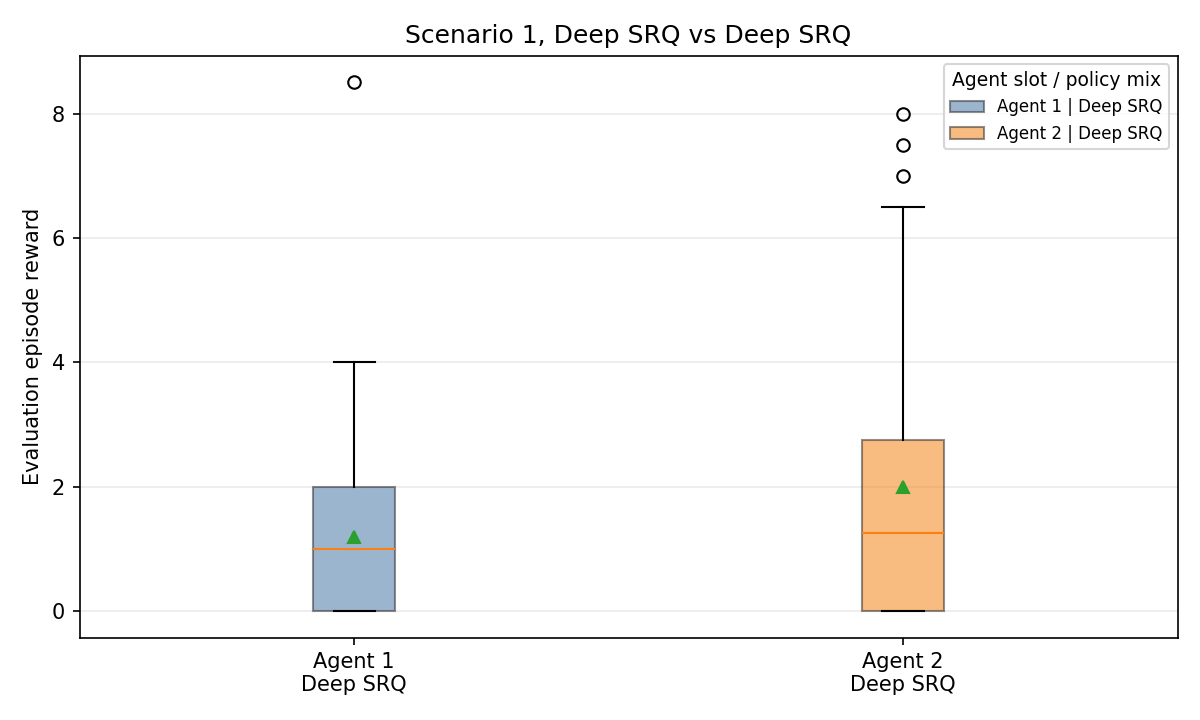

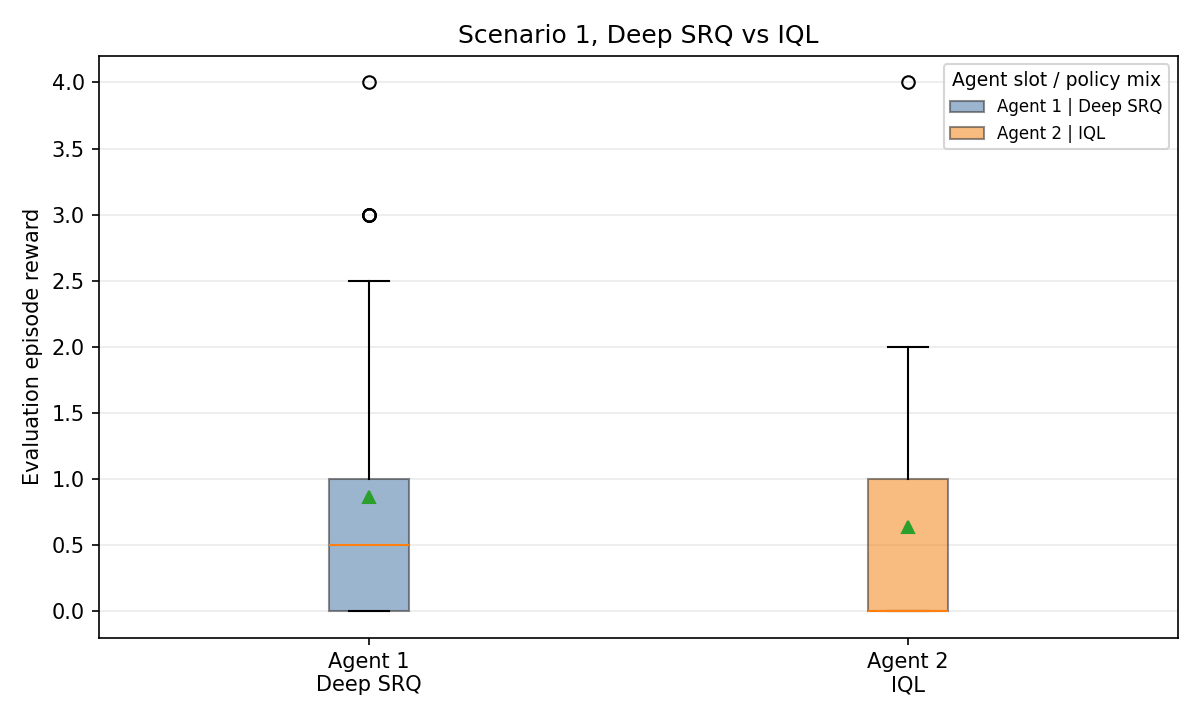

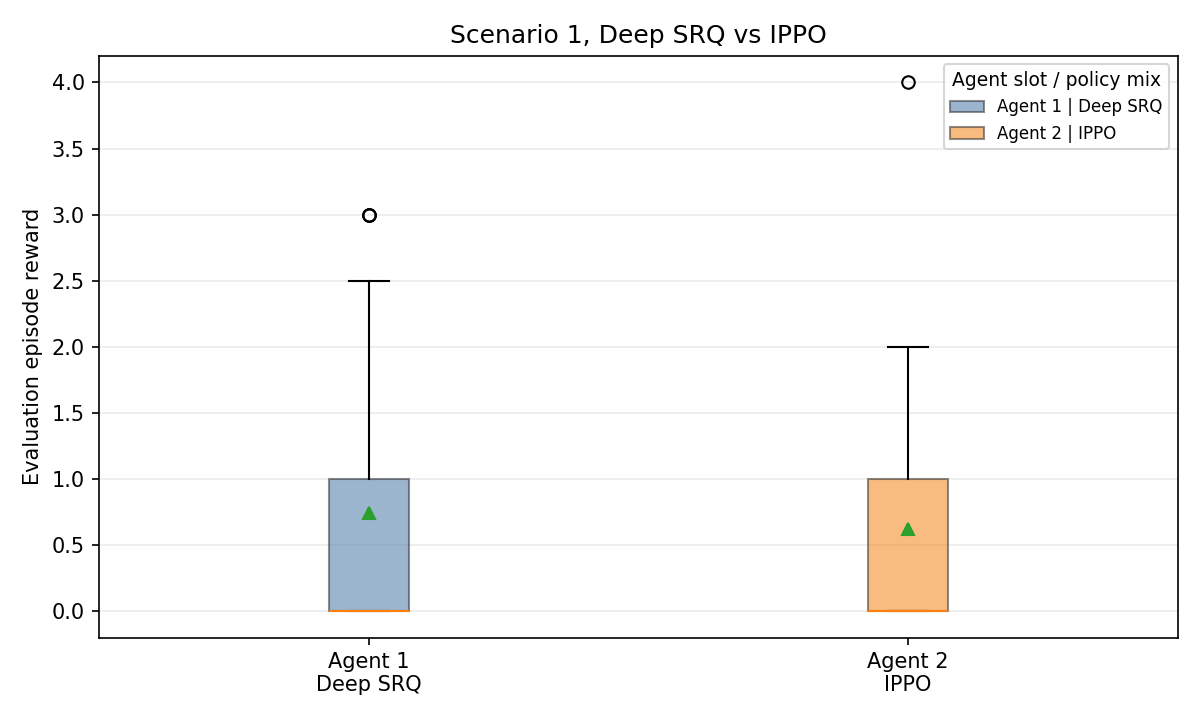

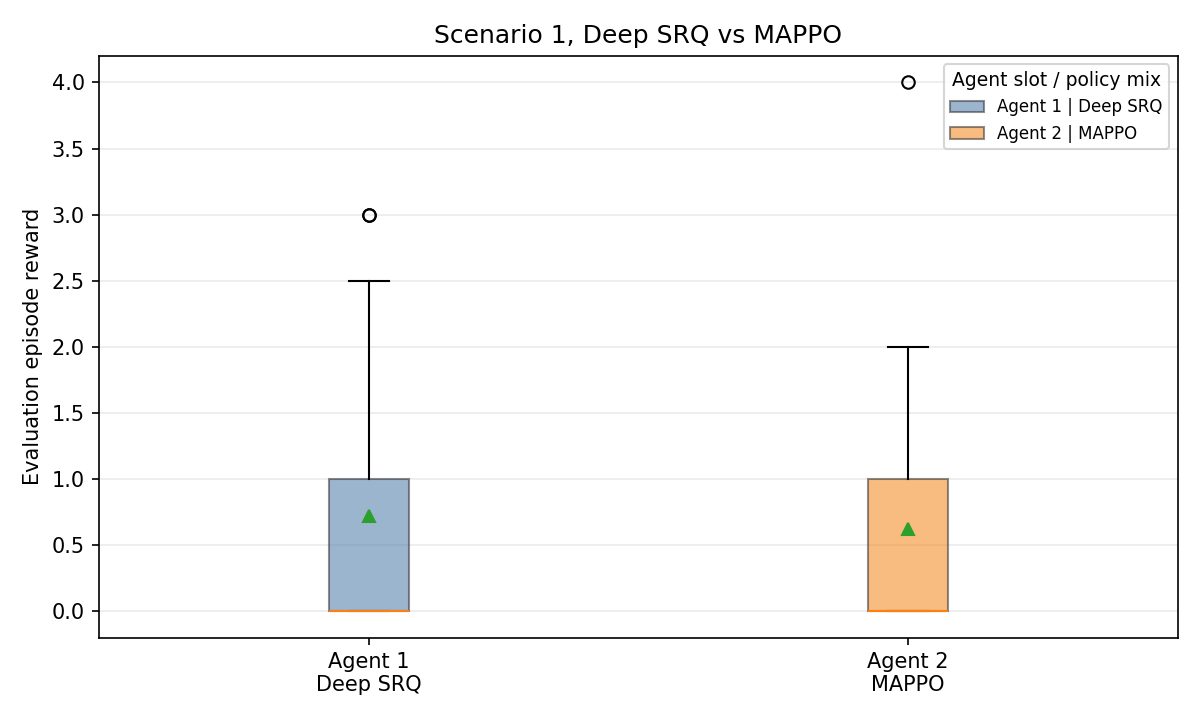

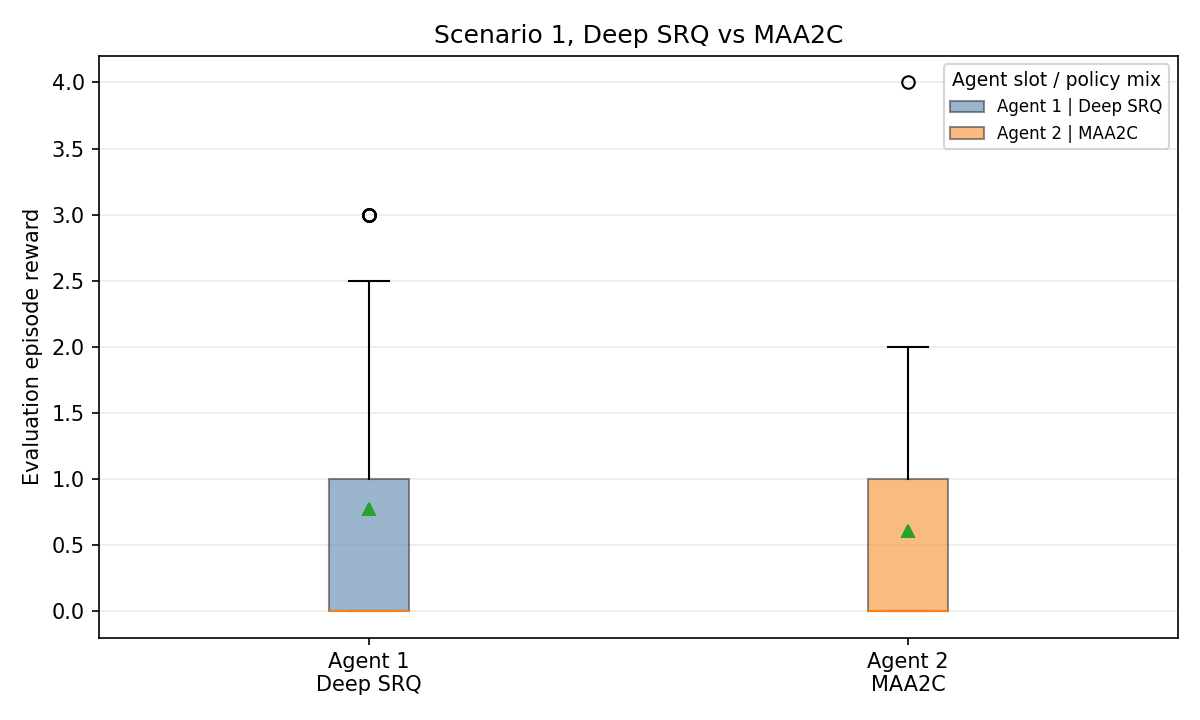

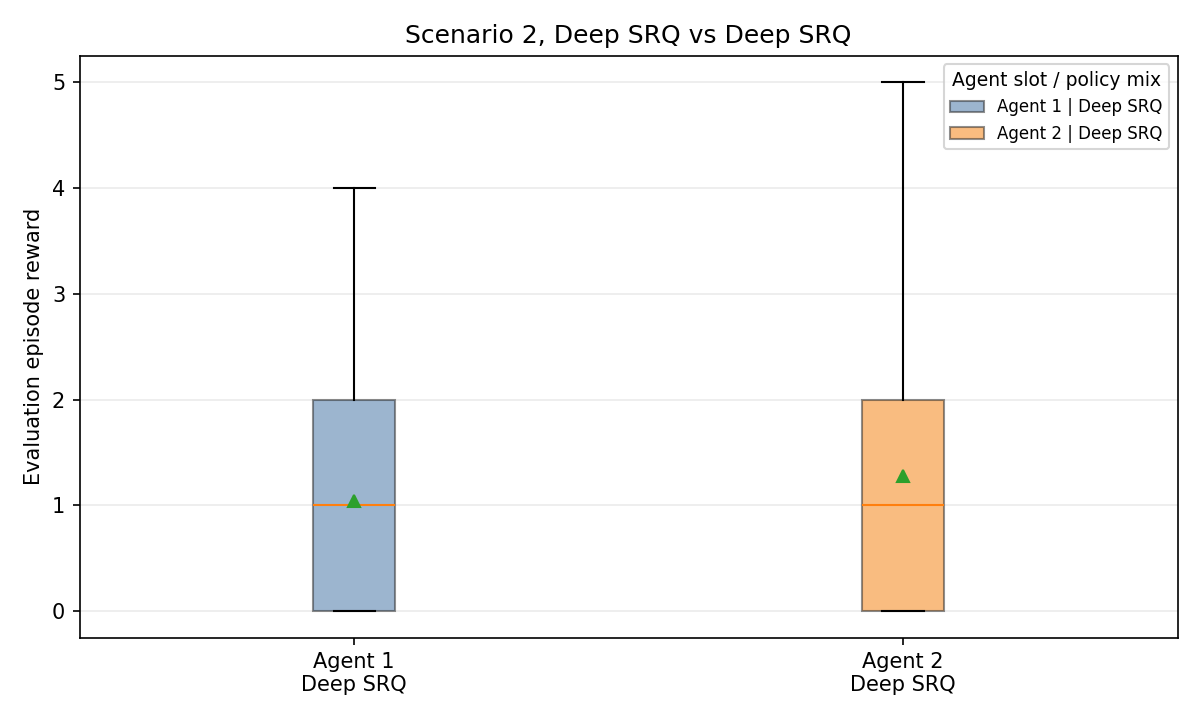

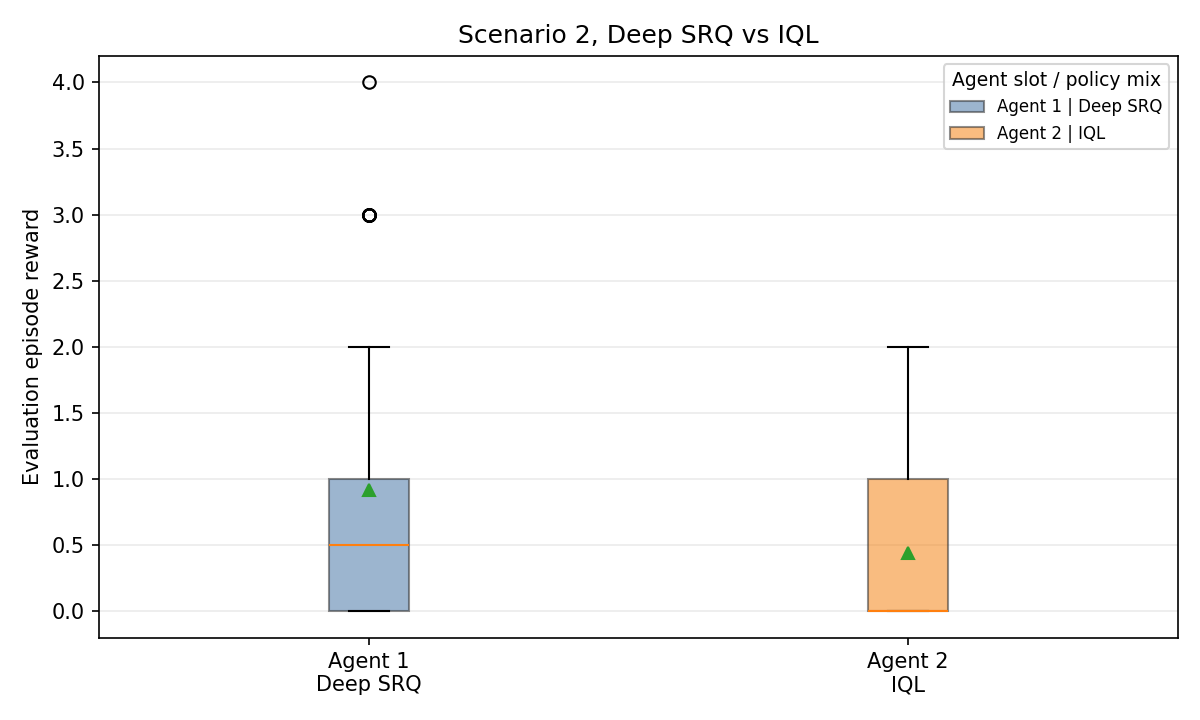

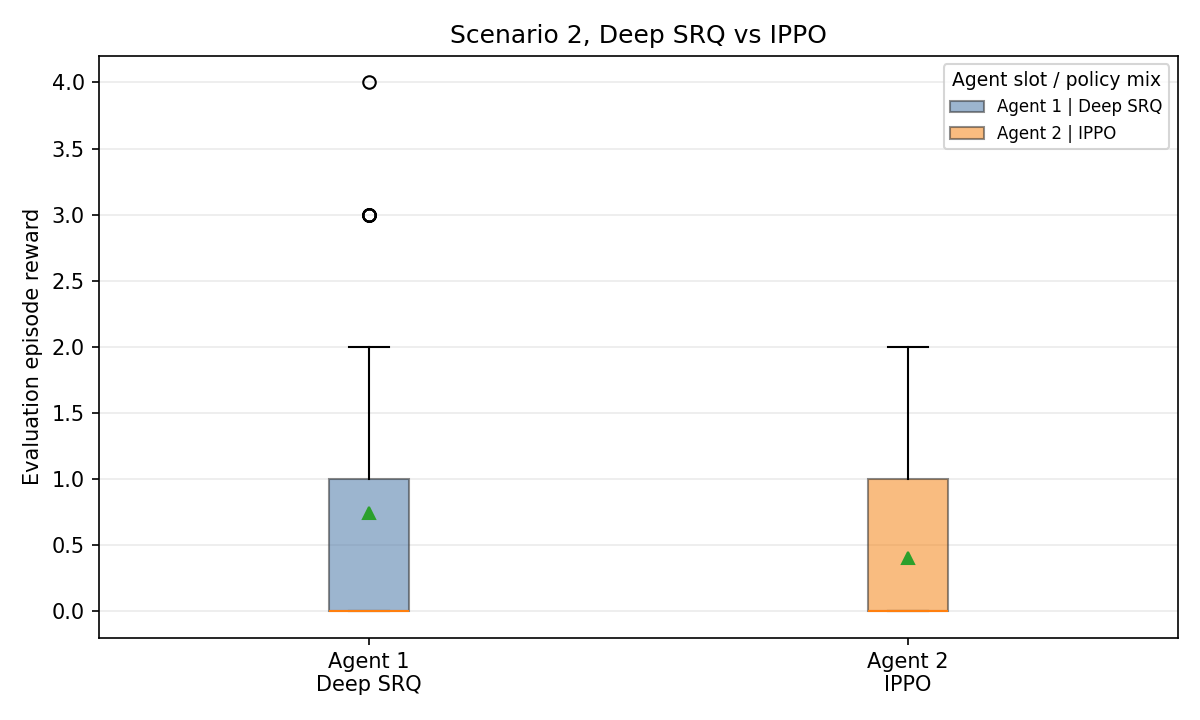

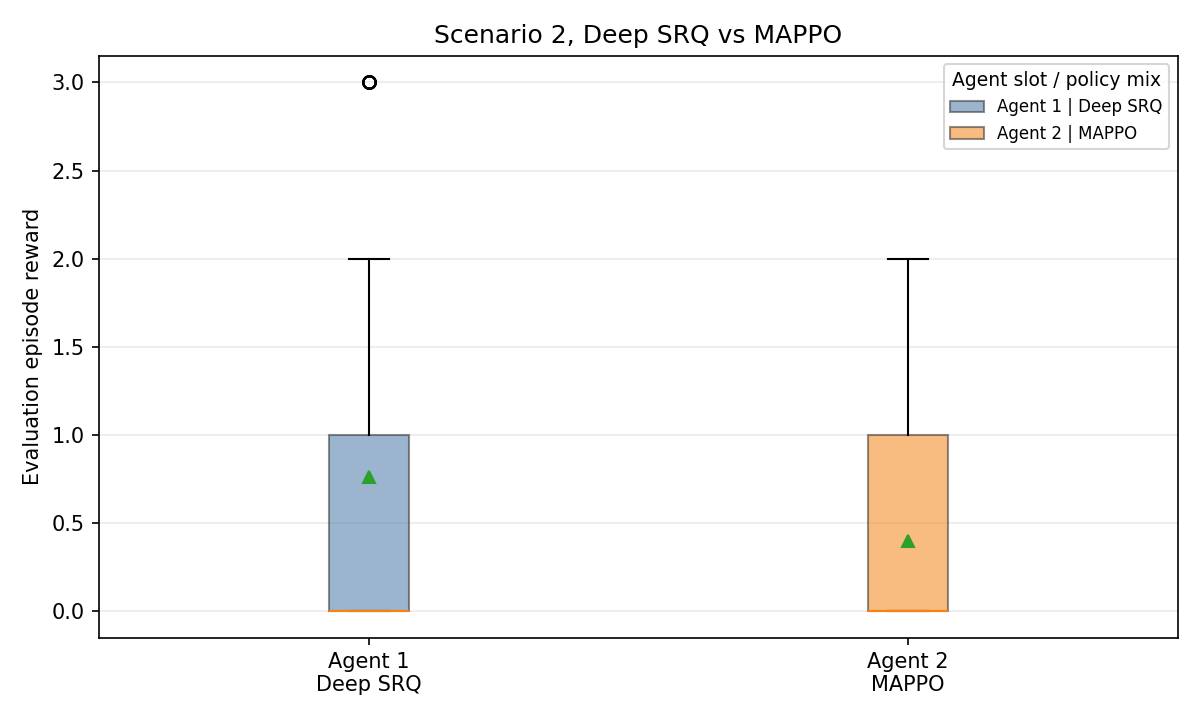

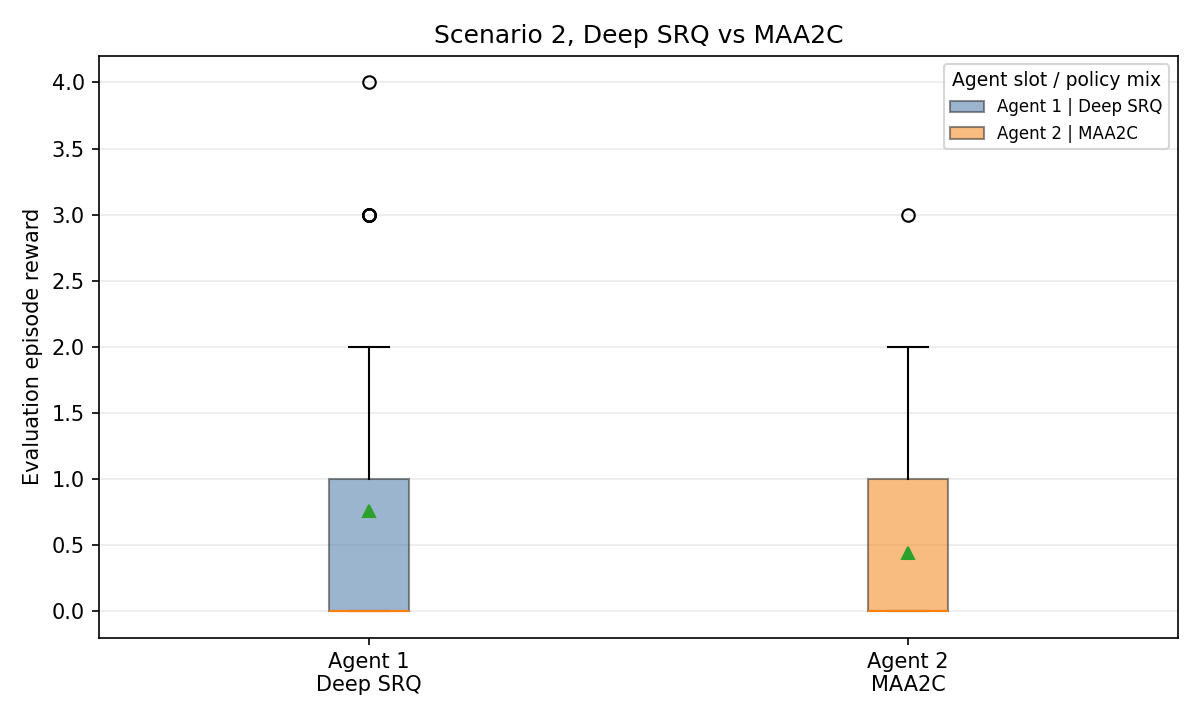

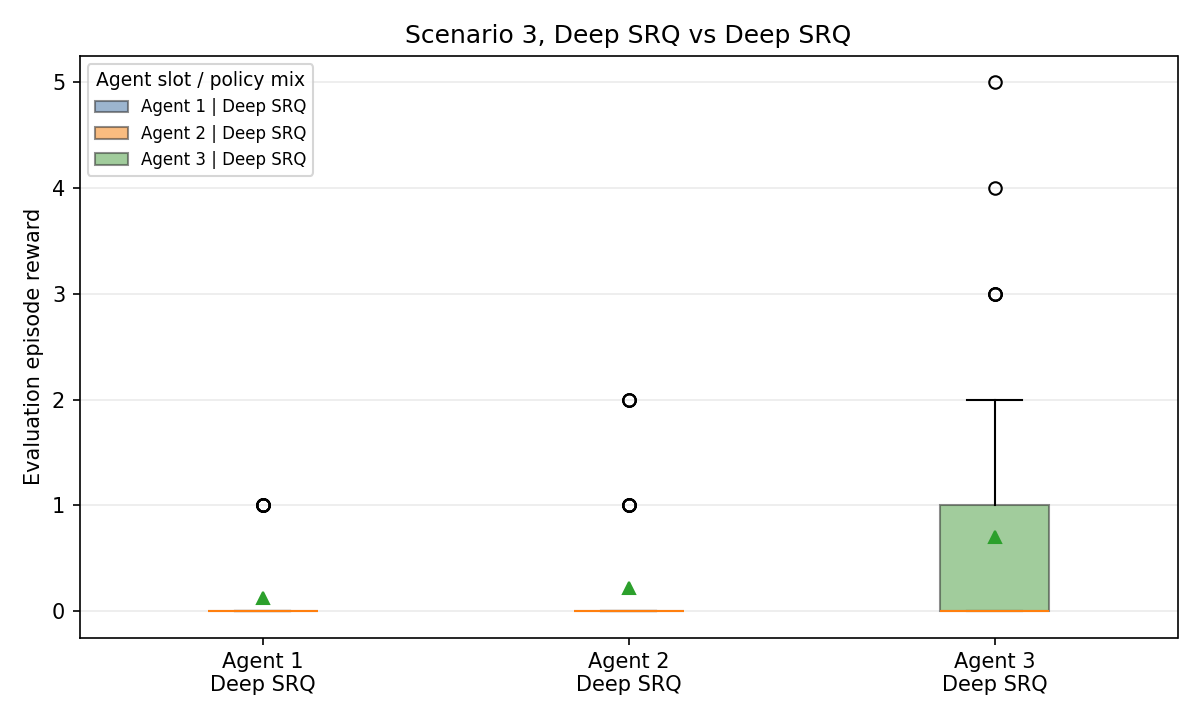

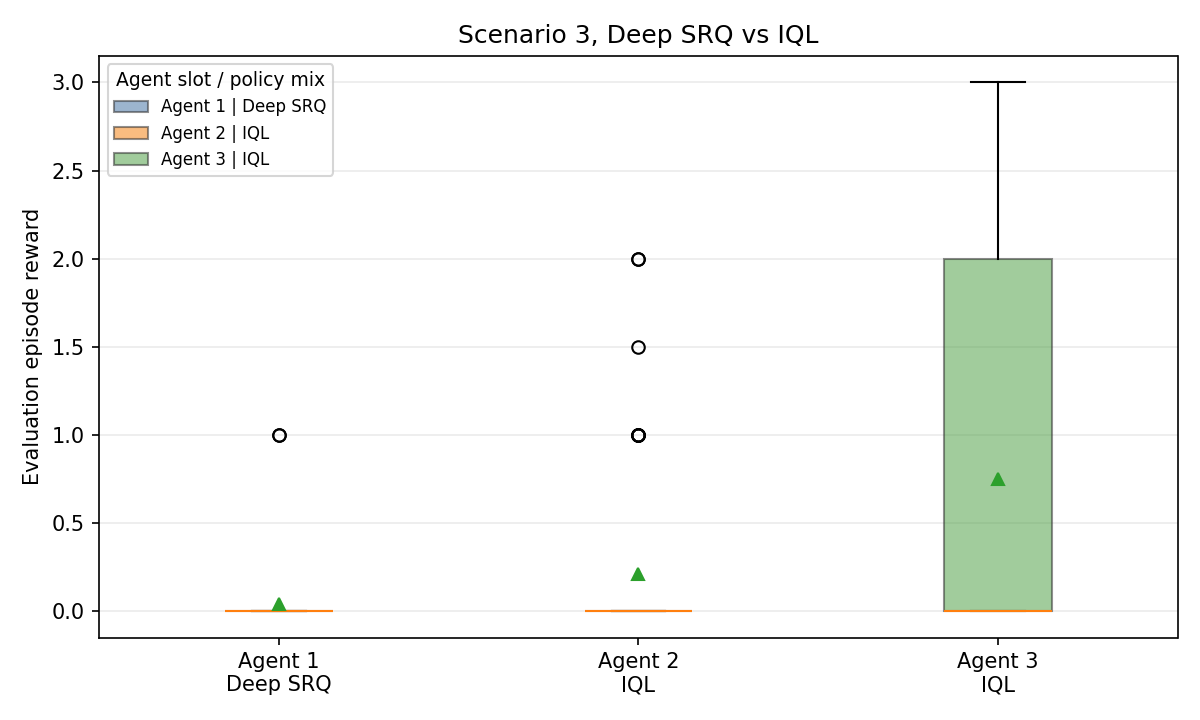

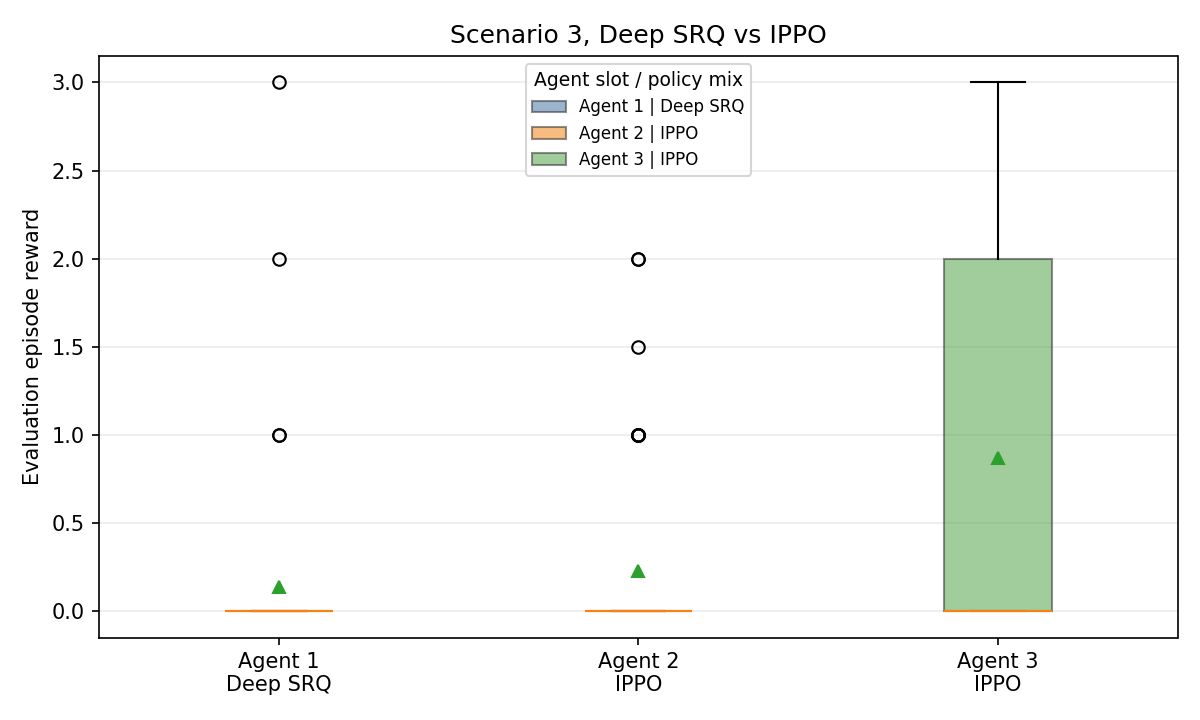

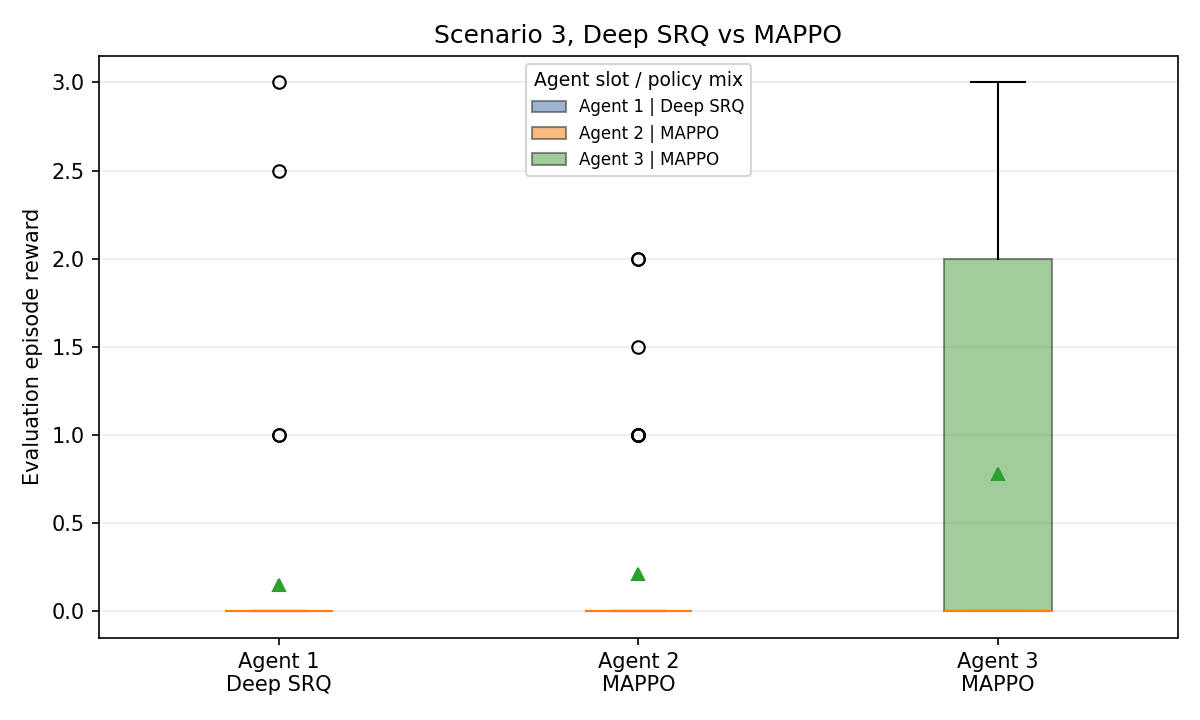

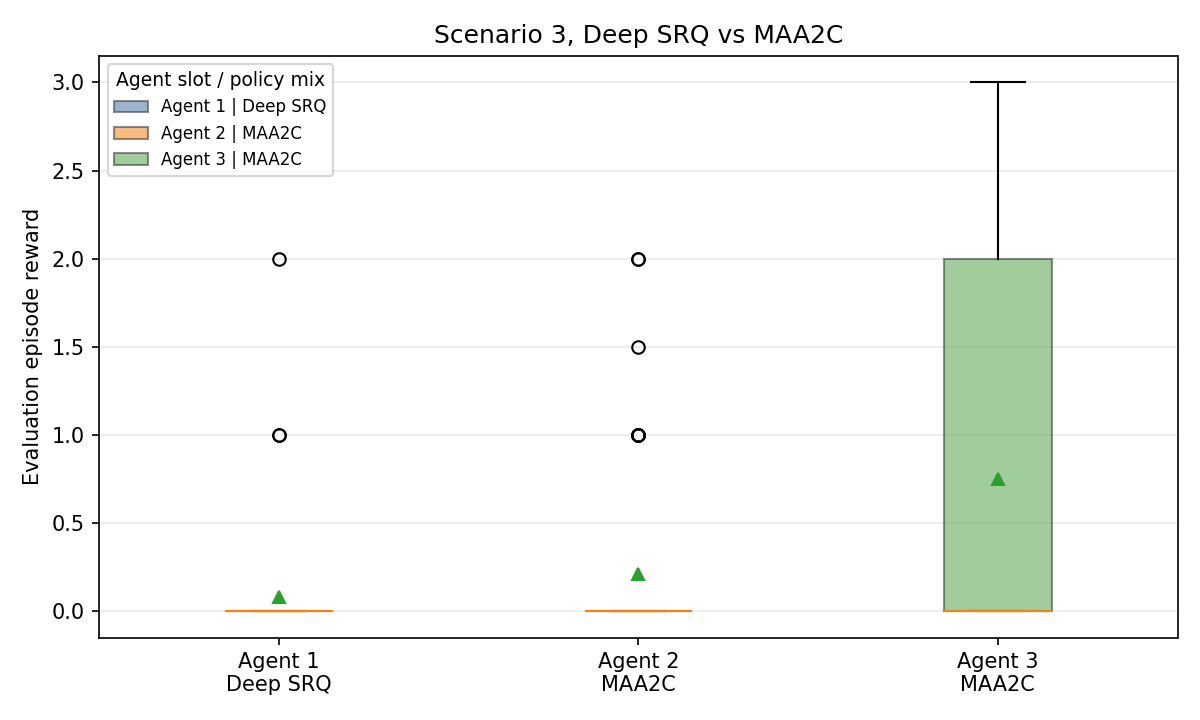

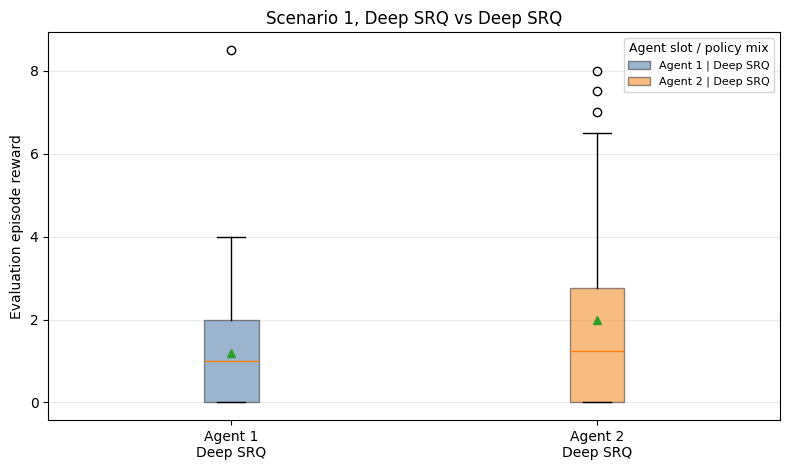

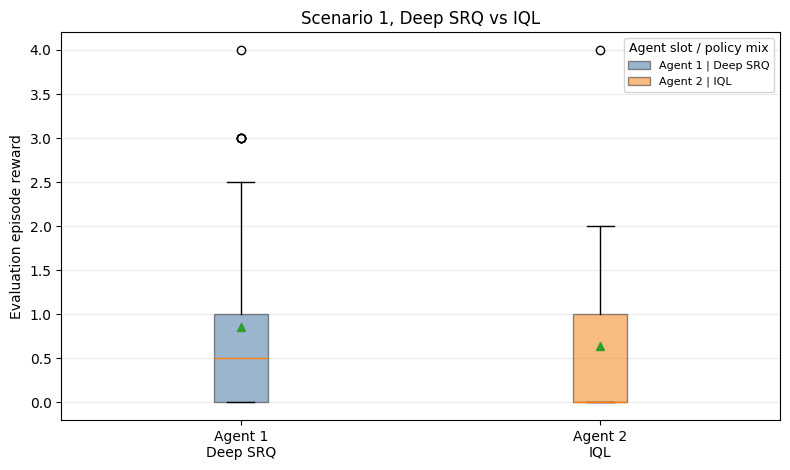

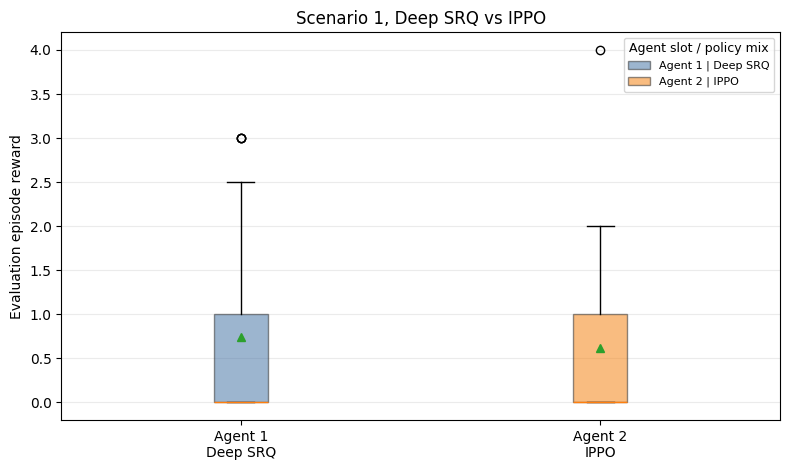

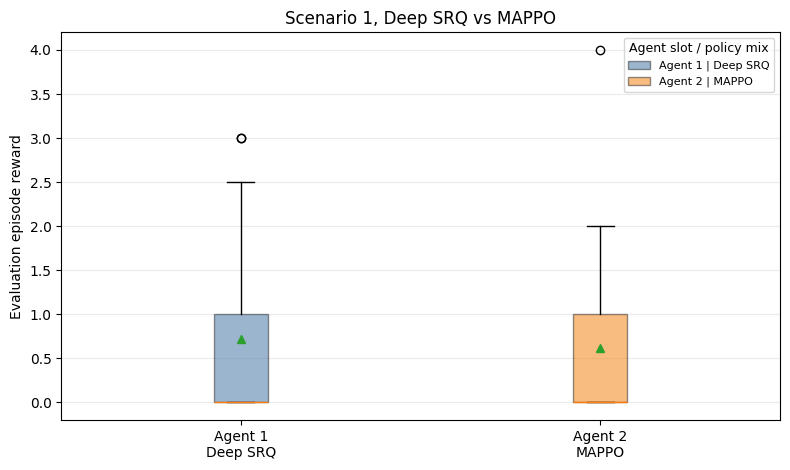

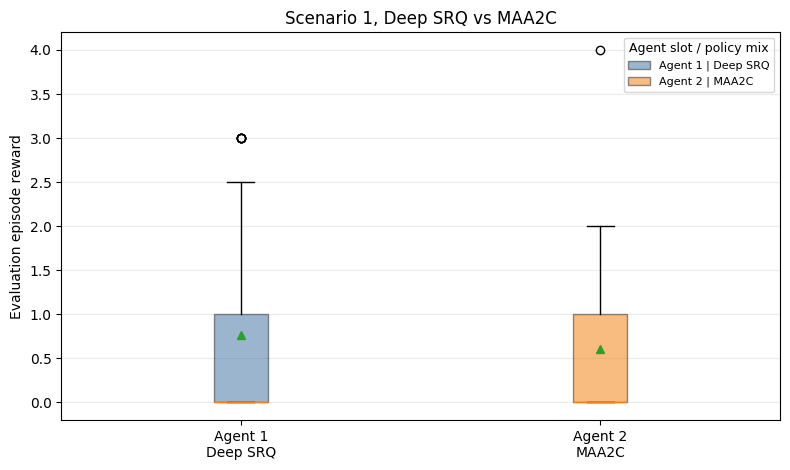

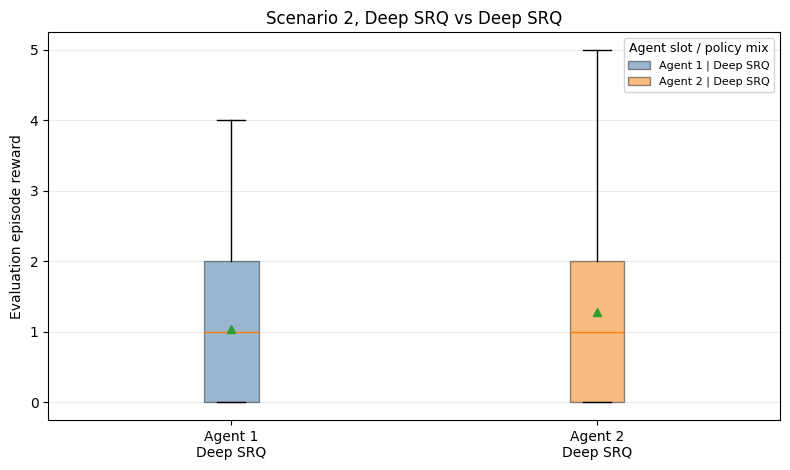

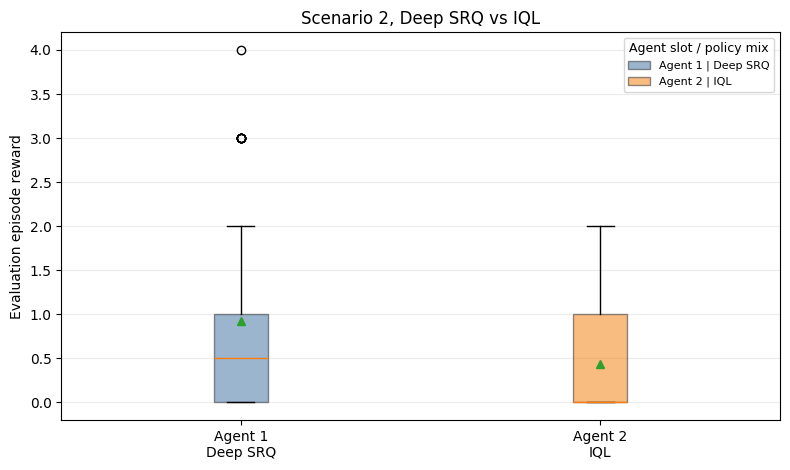

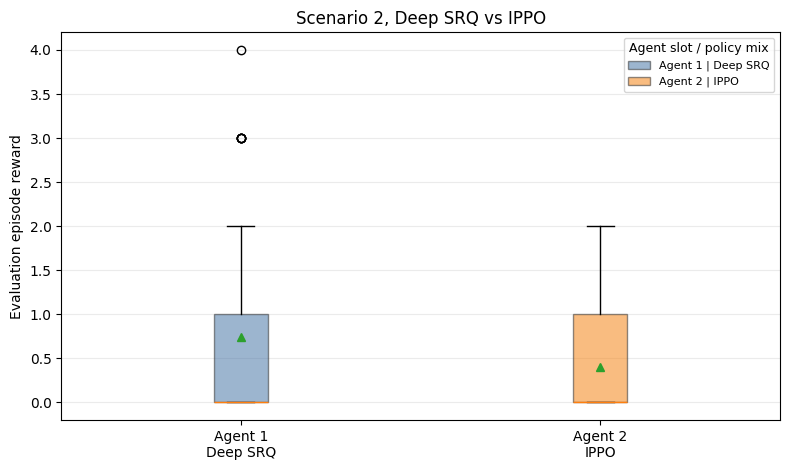

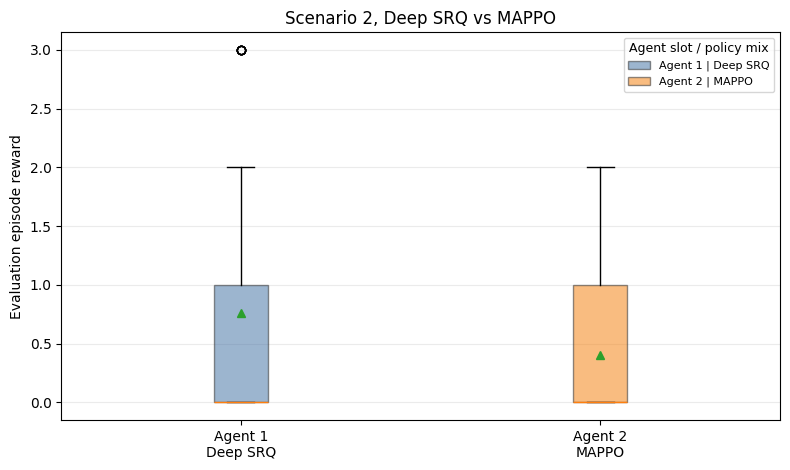

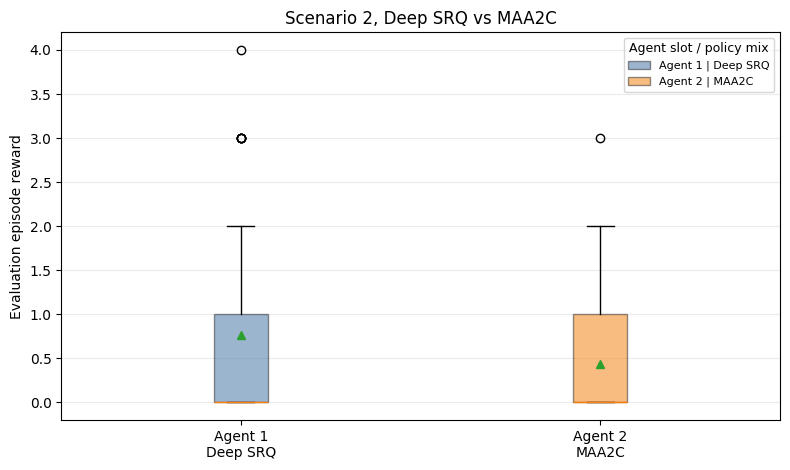

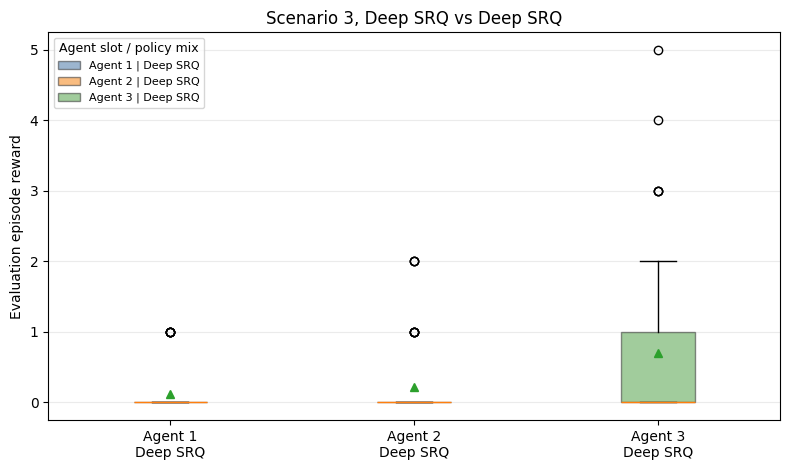

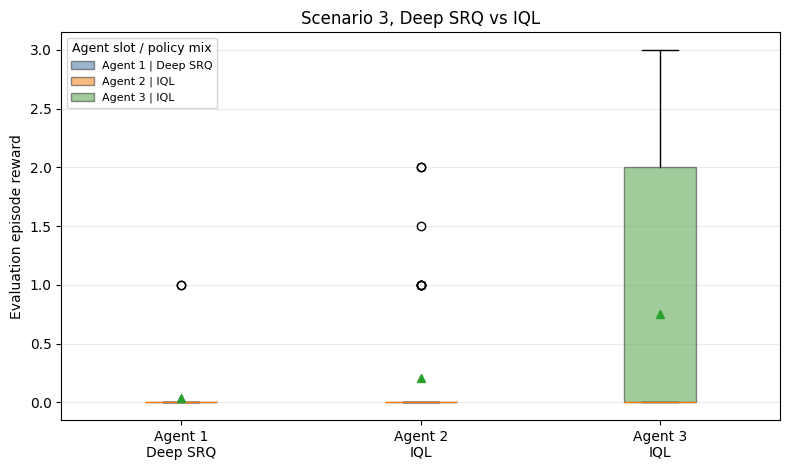

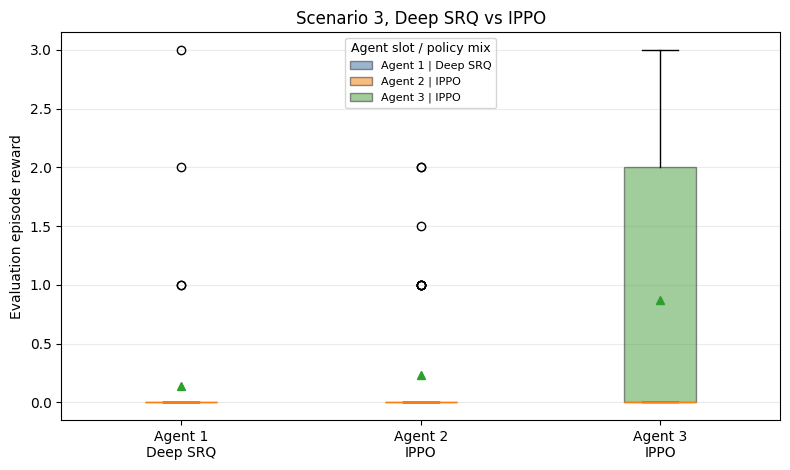

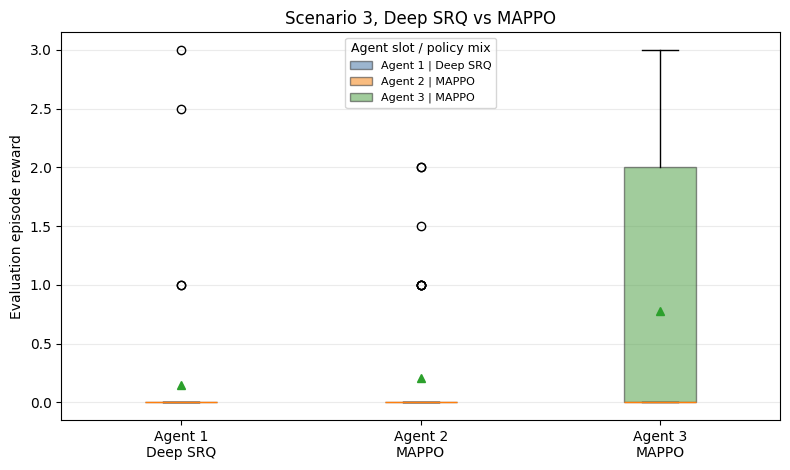

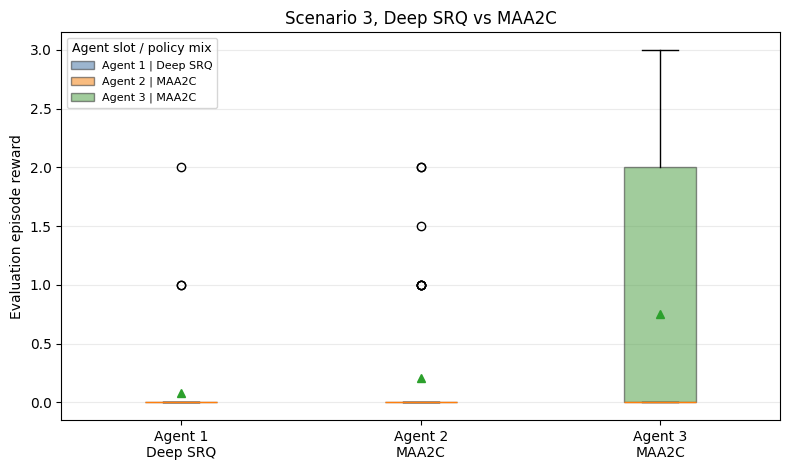

In [3]:
deep_srq_path_pool_eval_eps_0_01 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.01,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_01)


## Robust epsilon 0.1

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

...

lbf_10x10_3p_8f_levels123 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

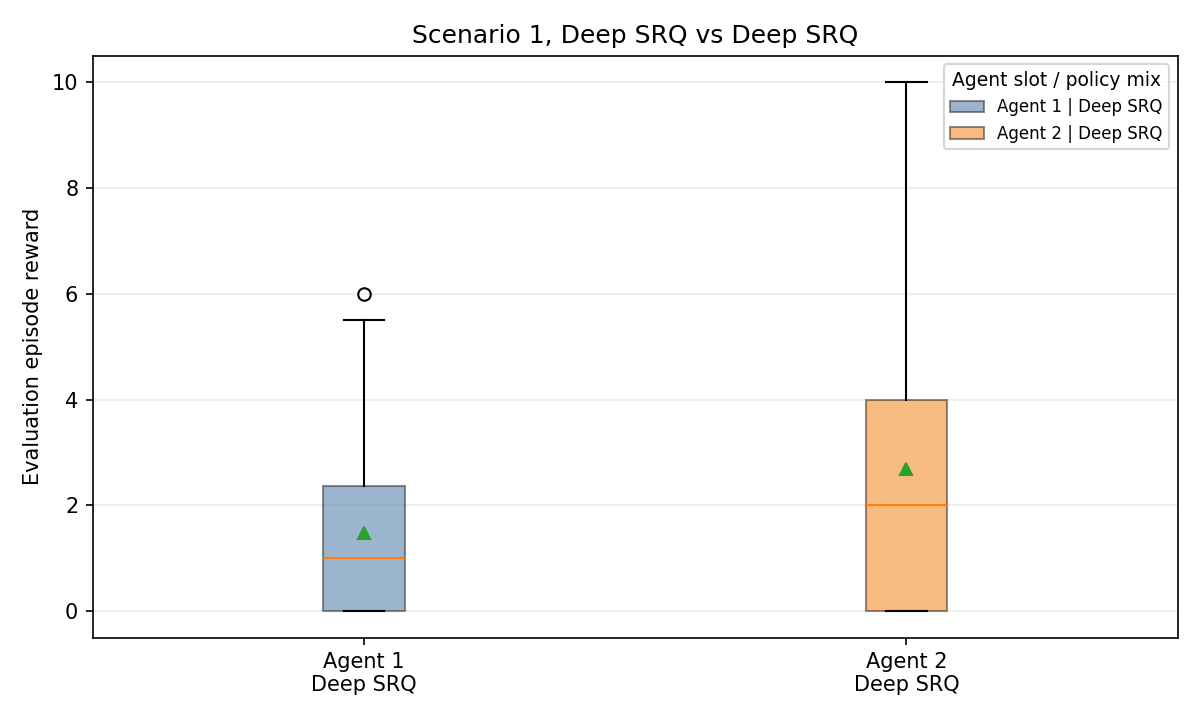

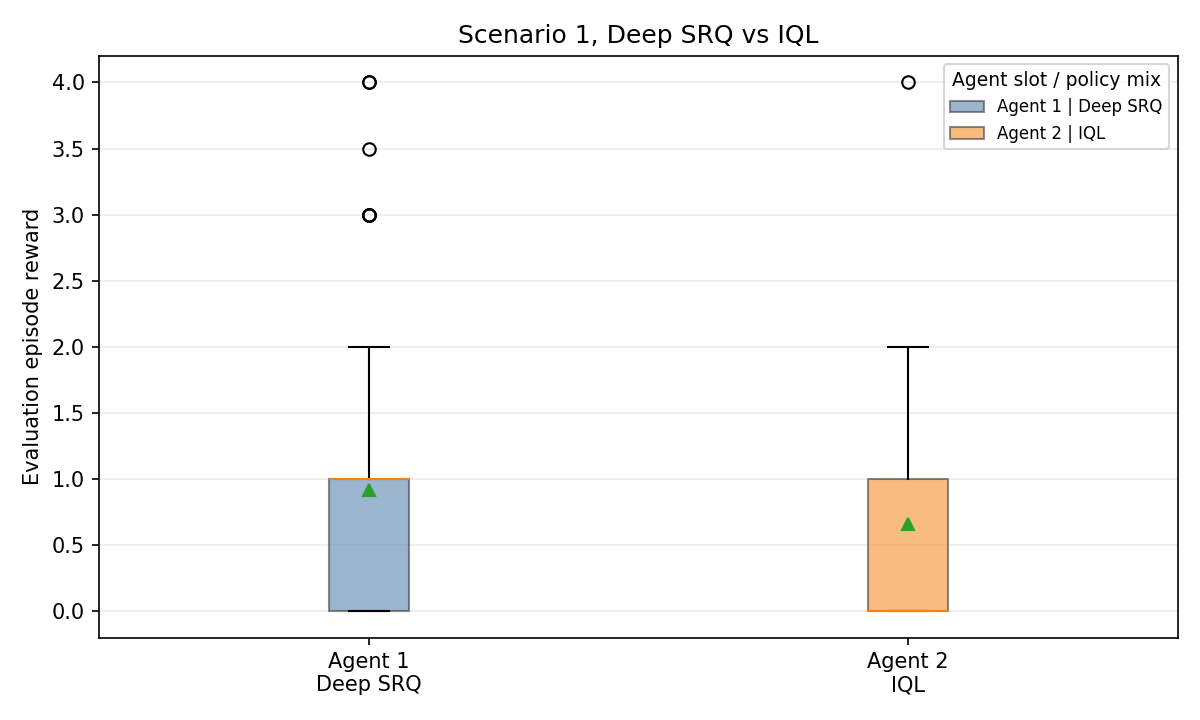

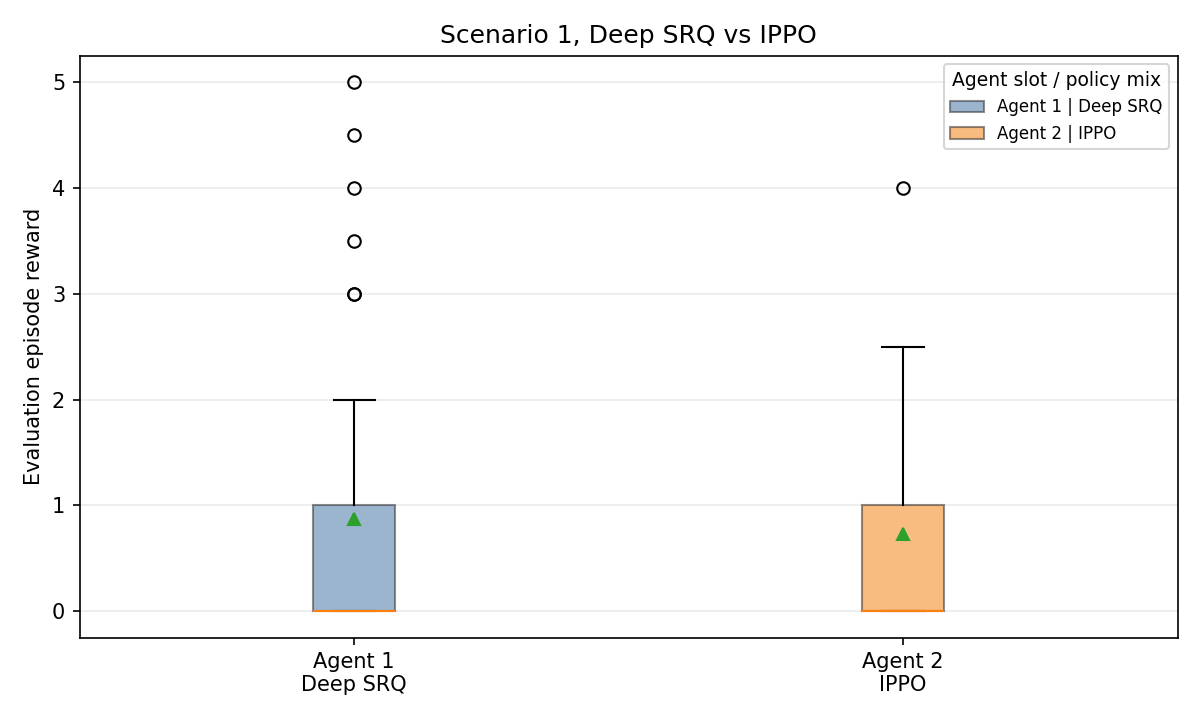

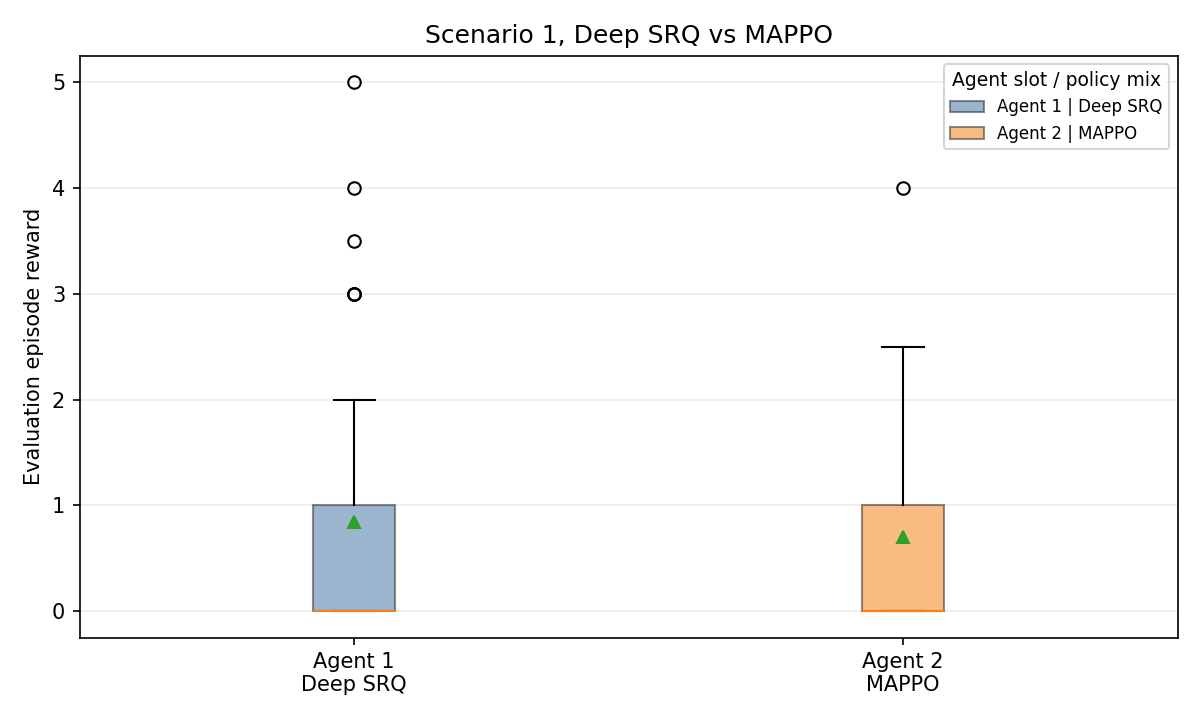

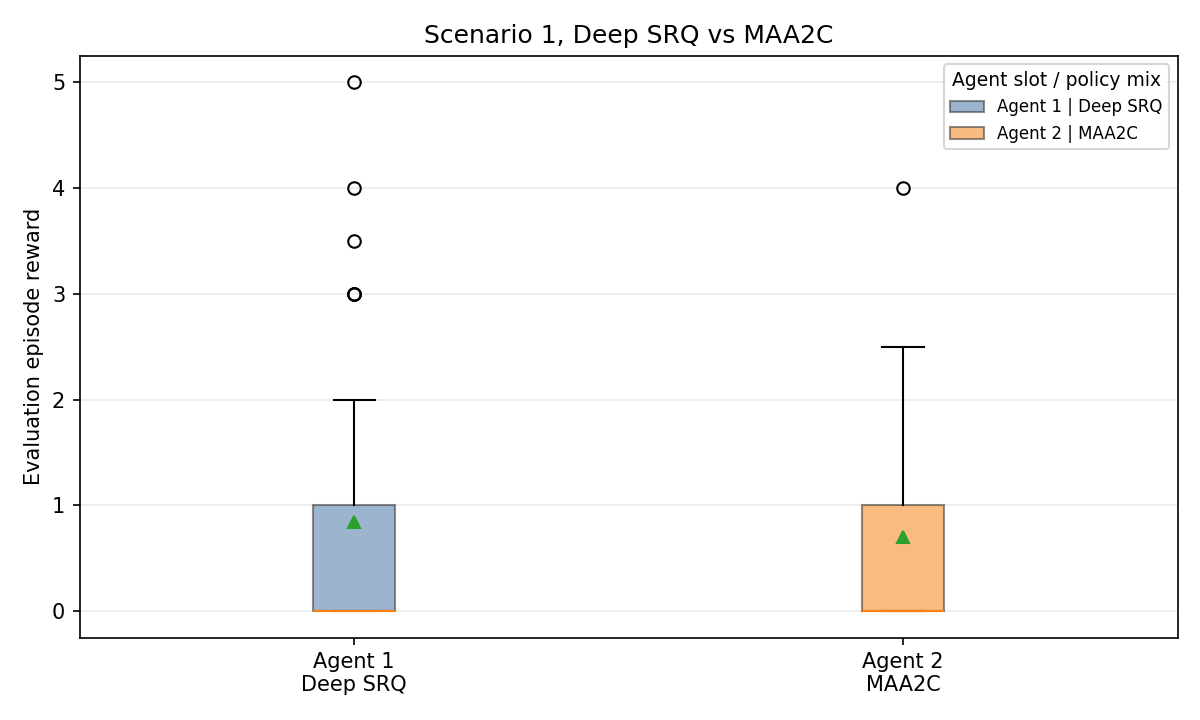

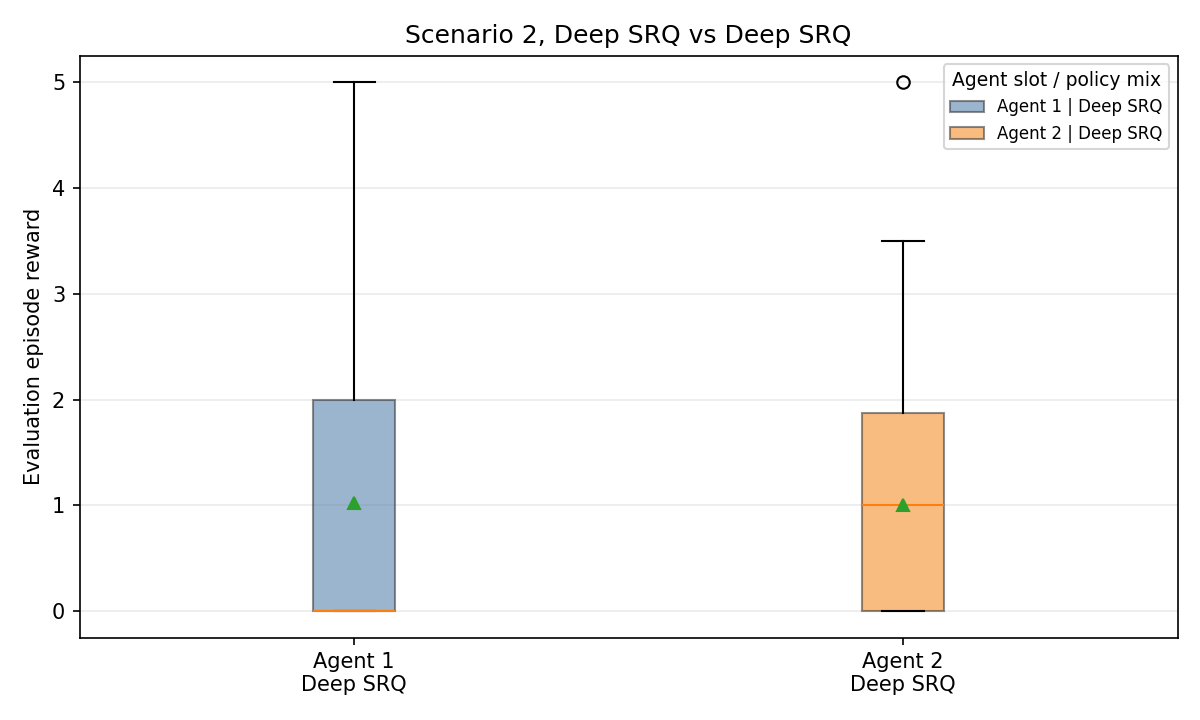

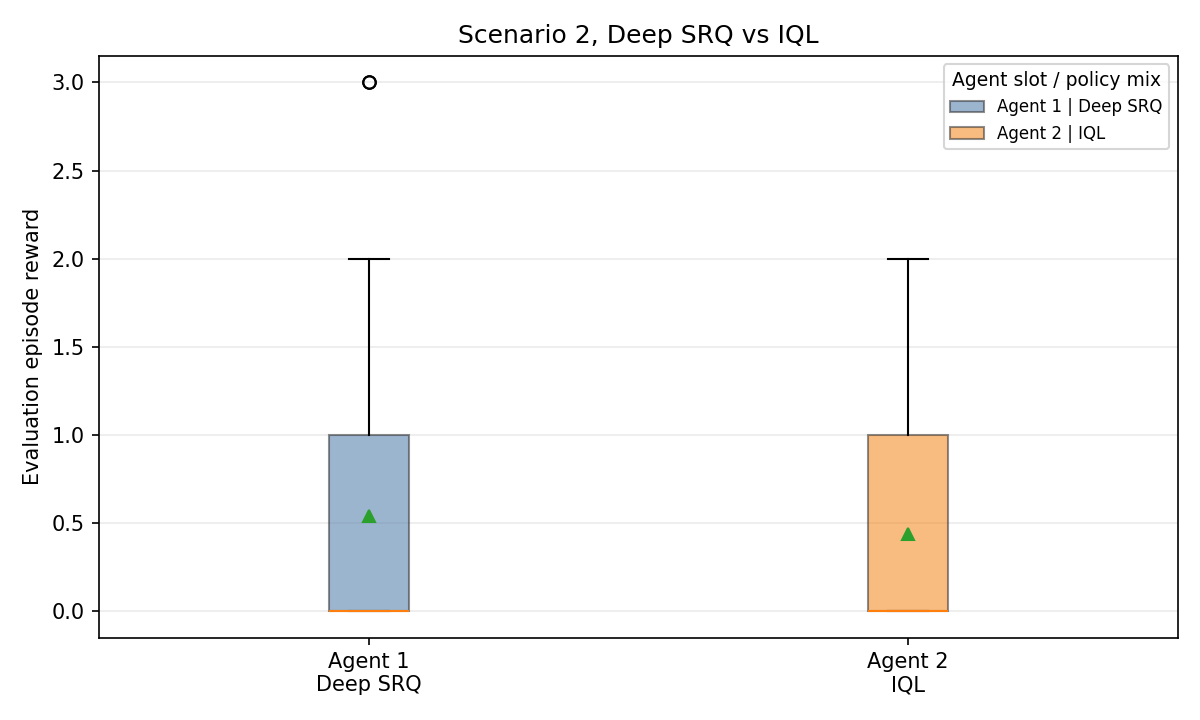

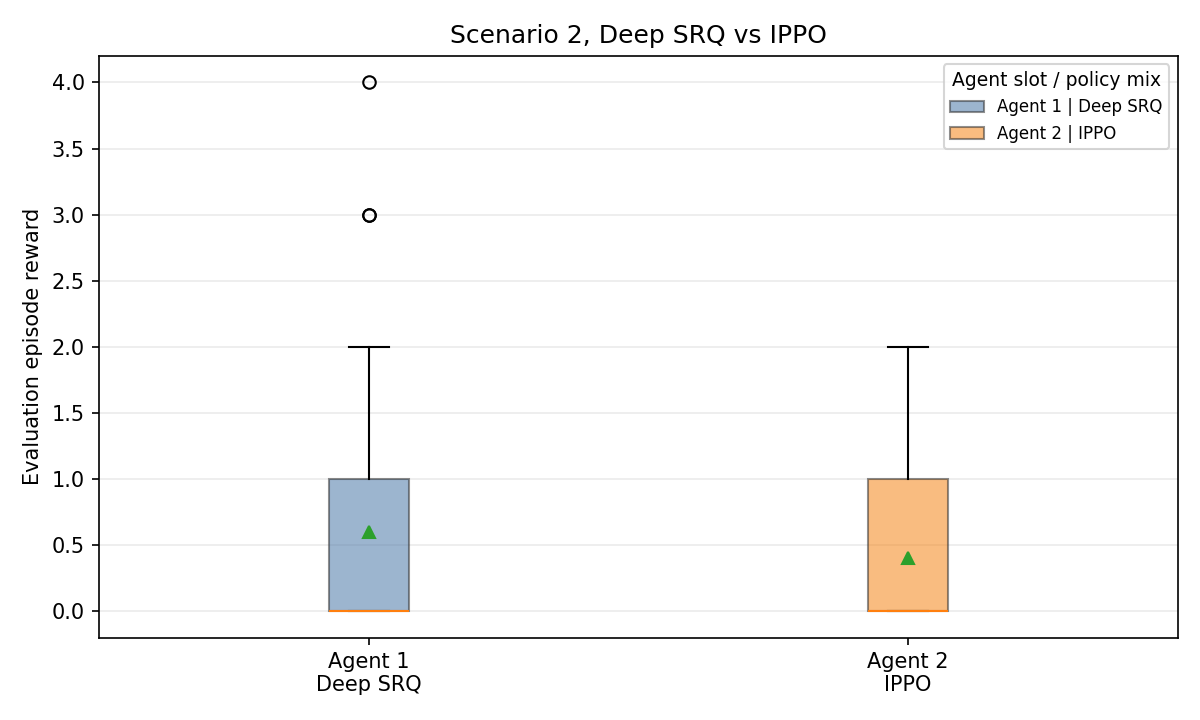

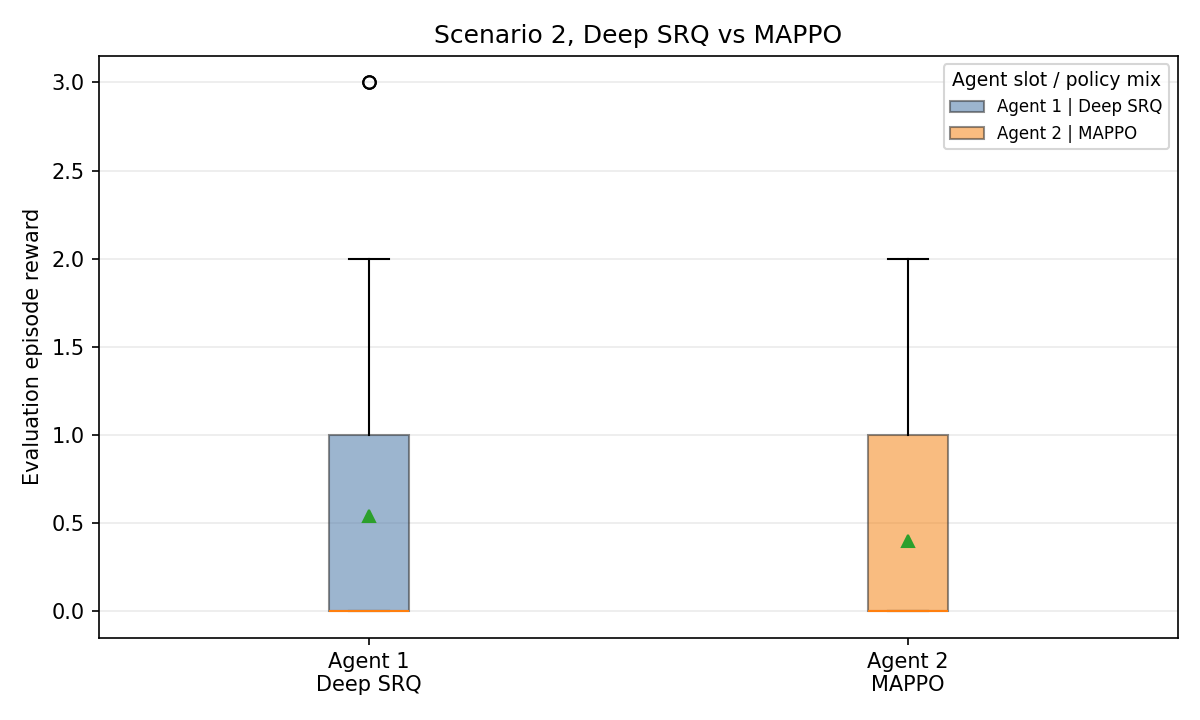

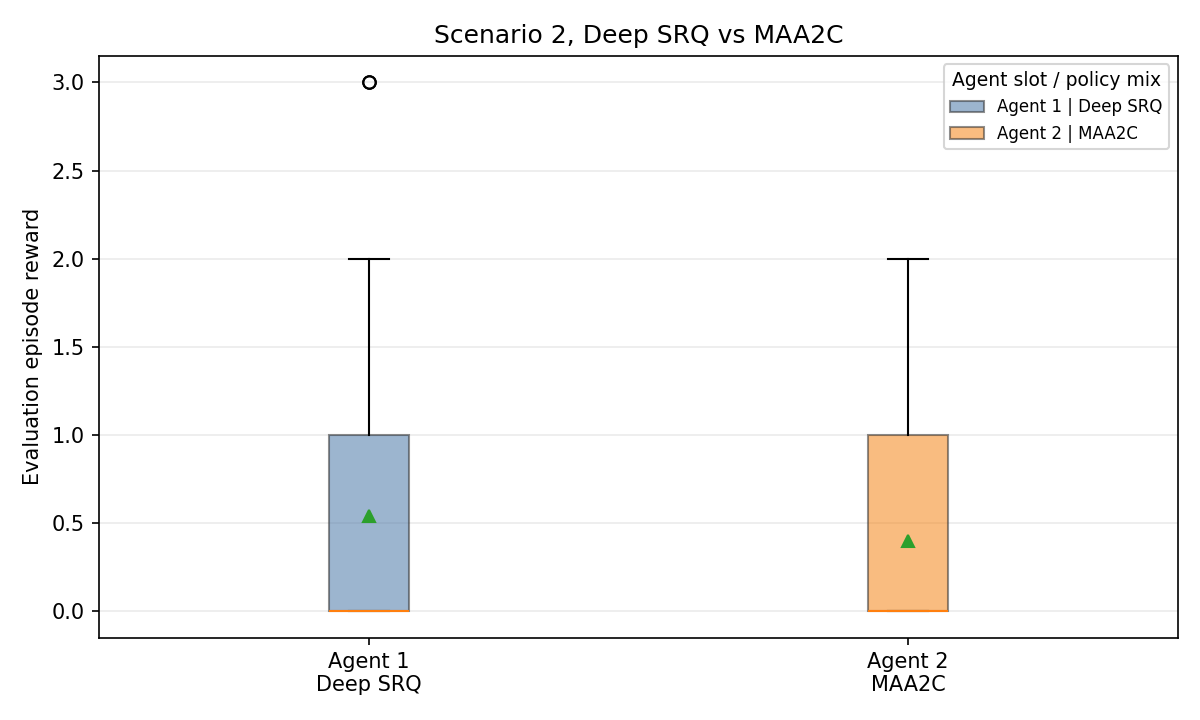

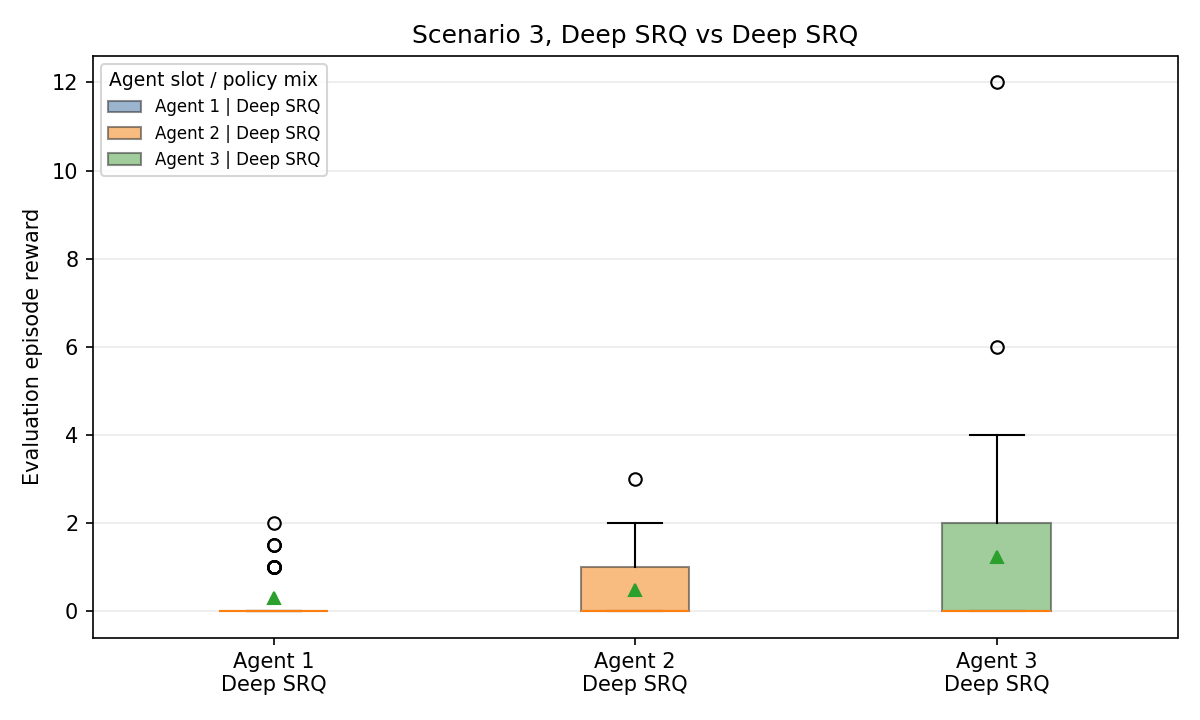

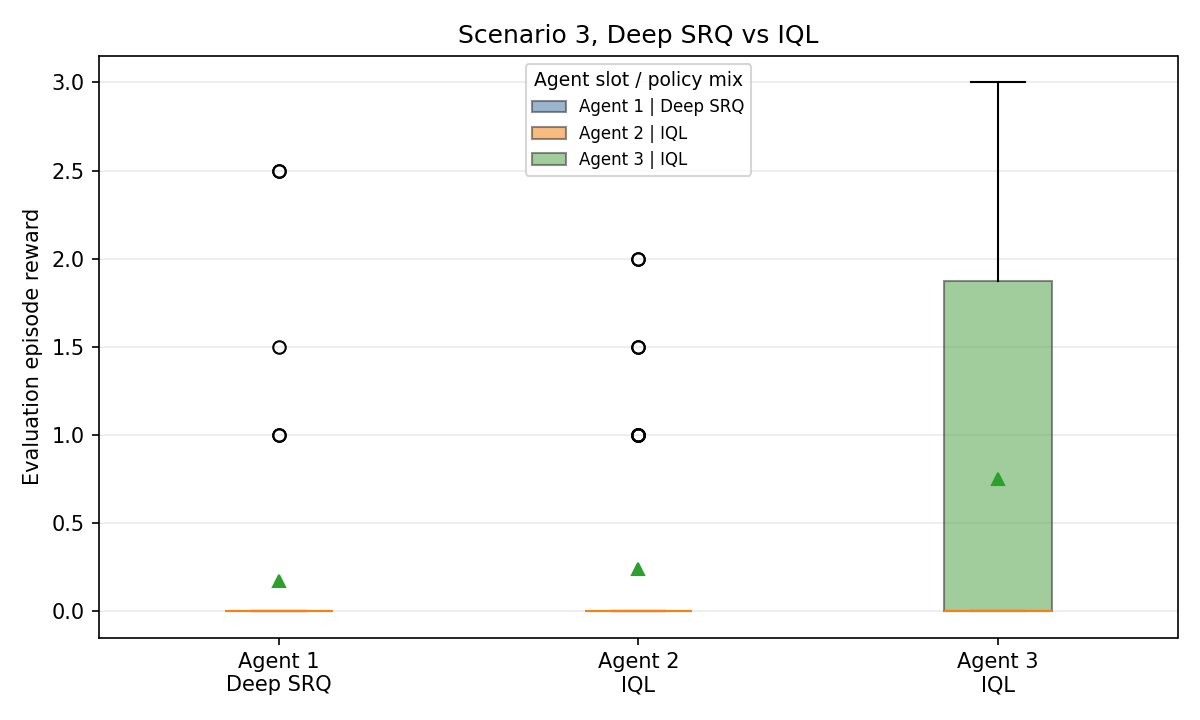

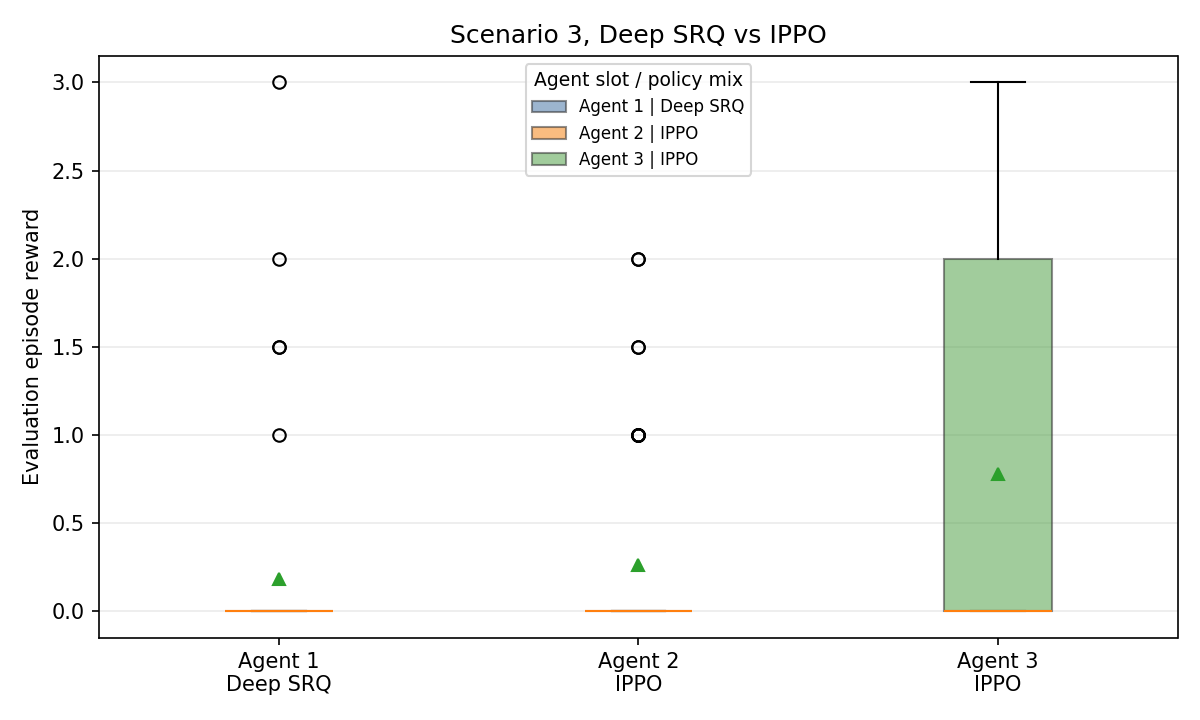

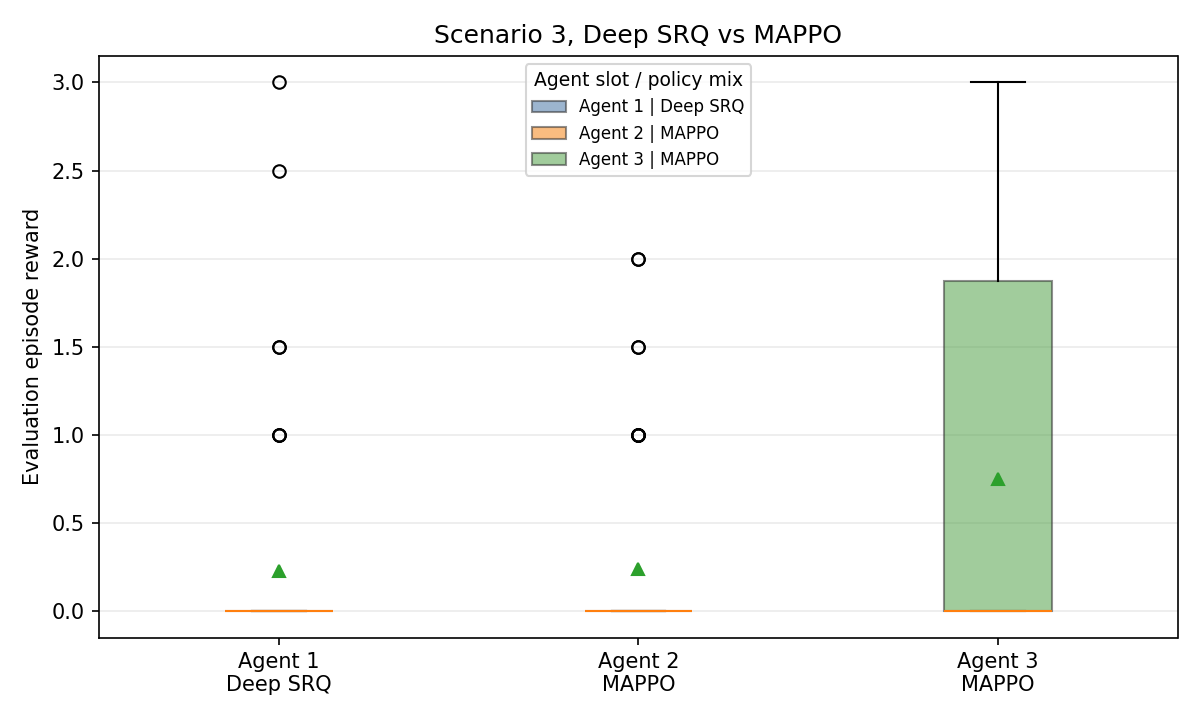

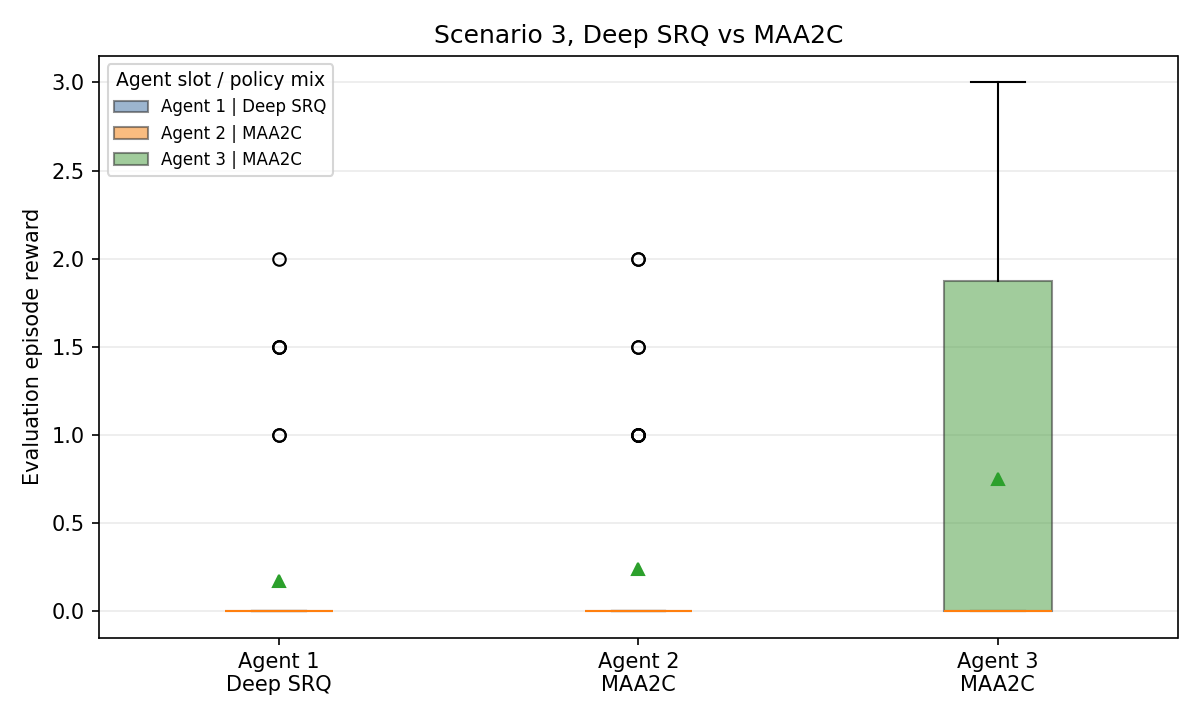

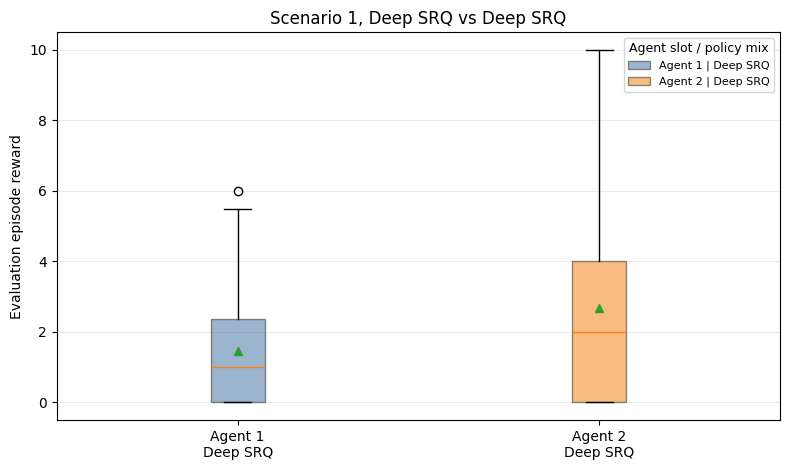

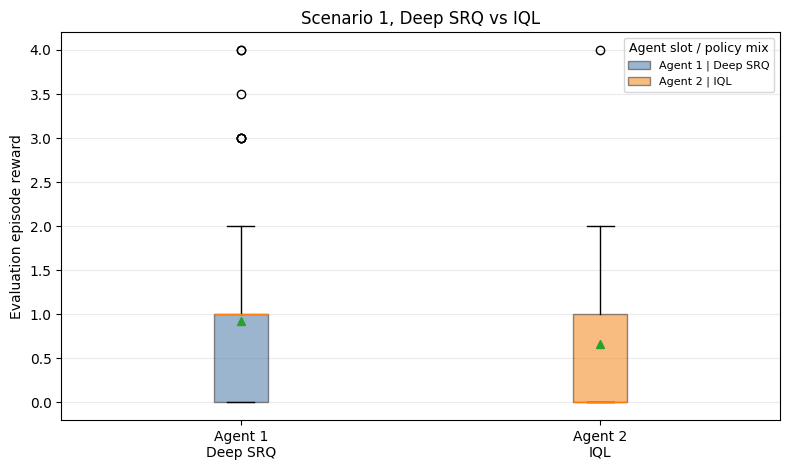

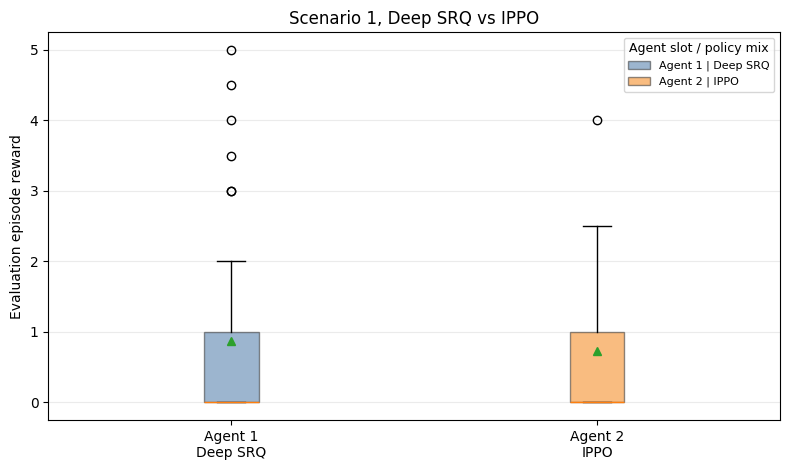

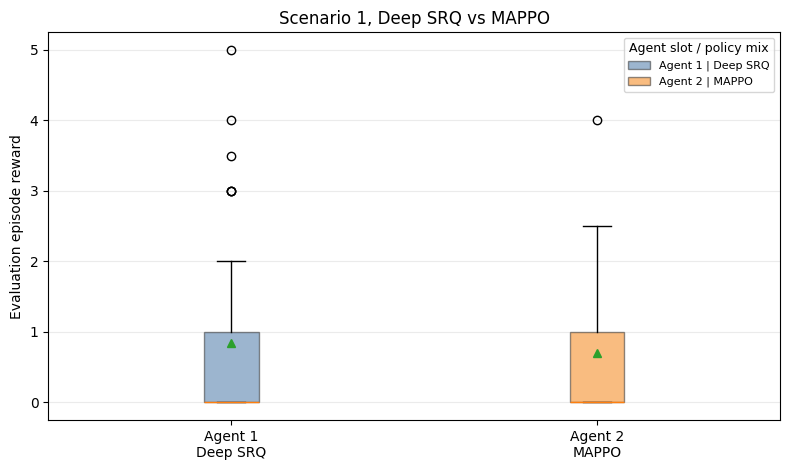

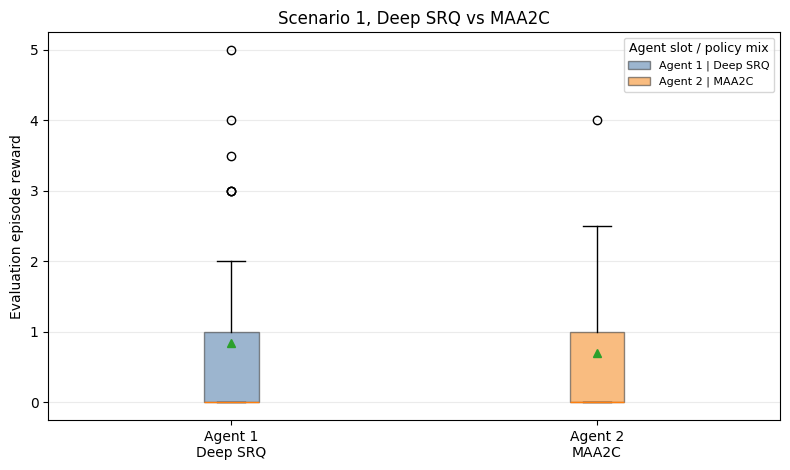

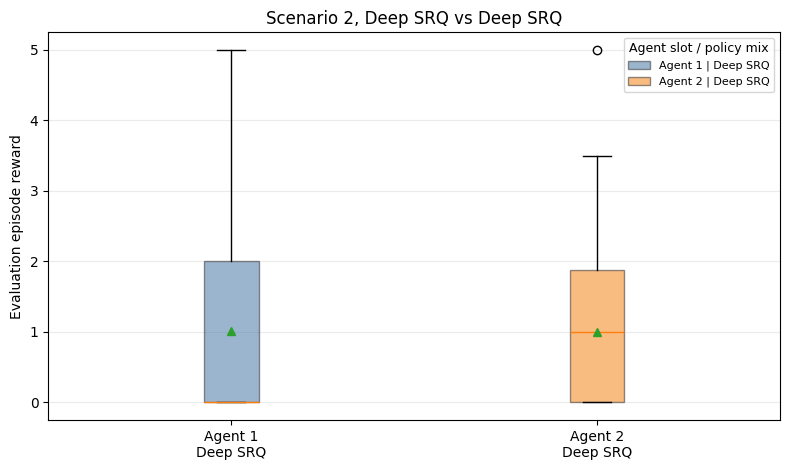

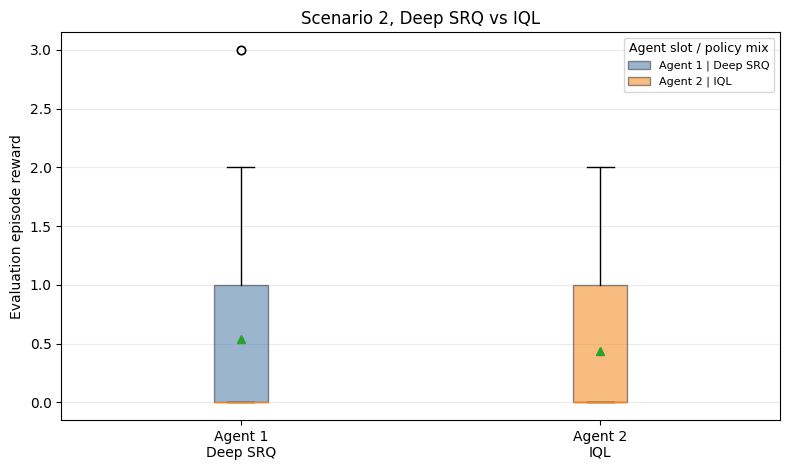

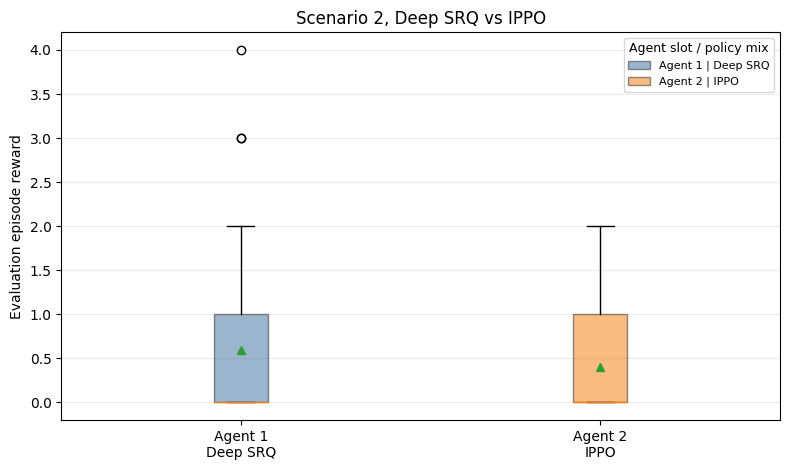

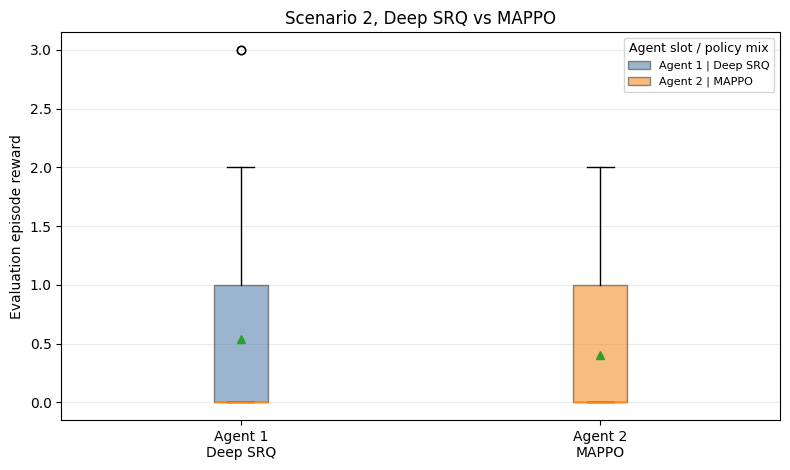

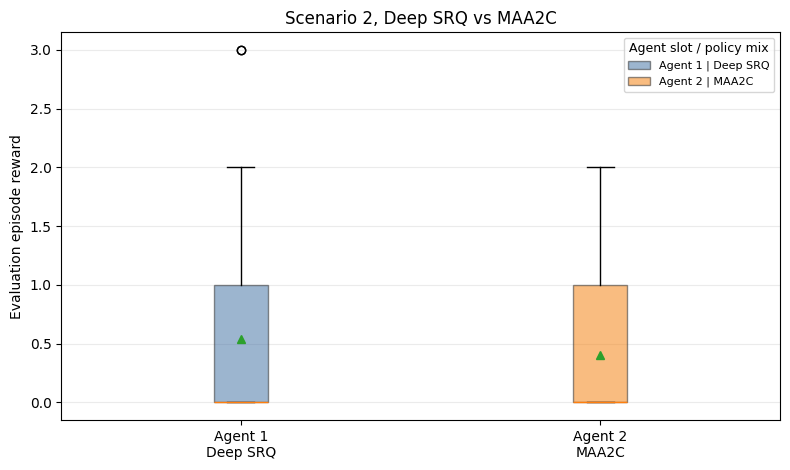

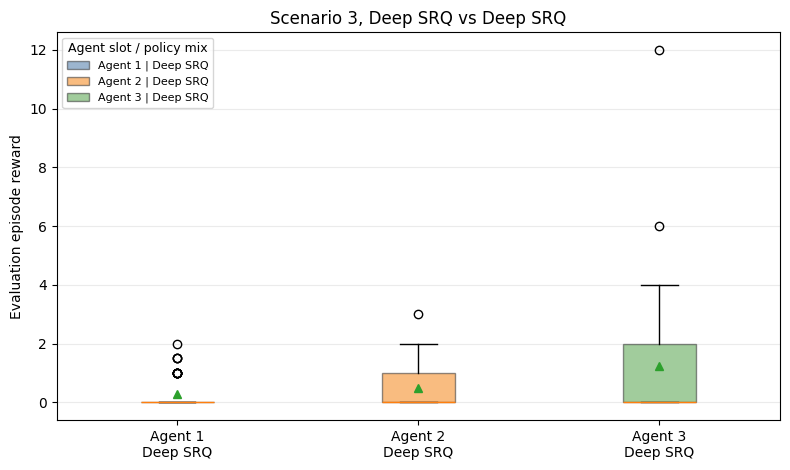

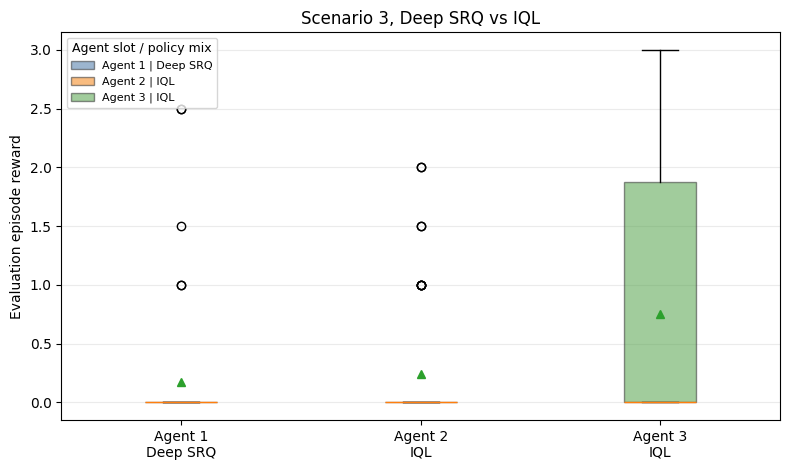

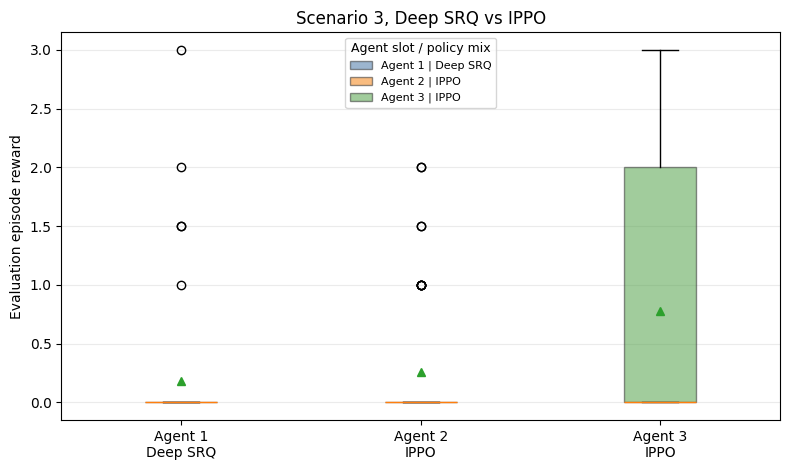

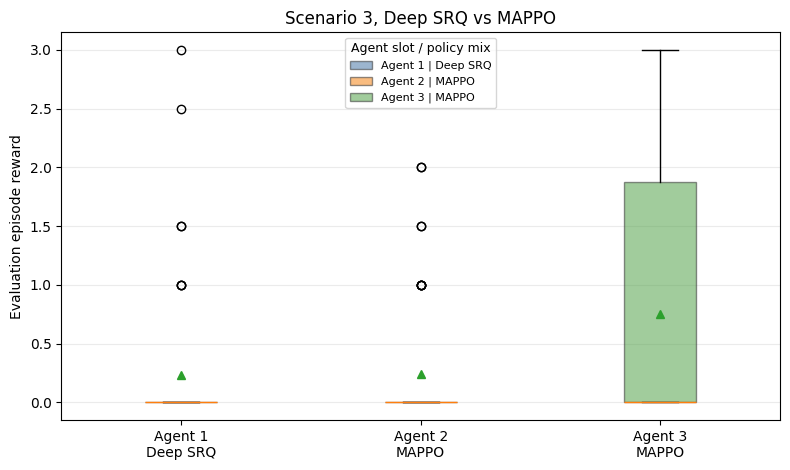

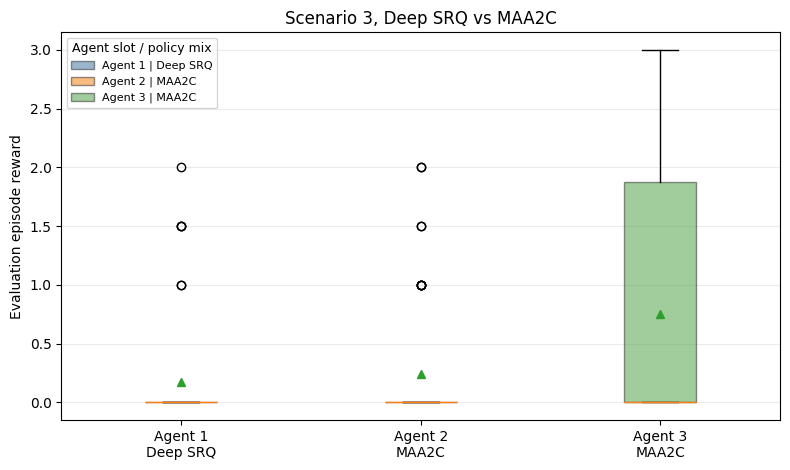

In [4]:
deep_srq_path_pool_eval_eps_0_1 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.1,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_1)


## Robust epsilon 0.5

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

...

lbf_10x10_3p_8f_levels123 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

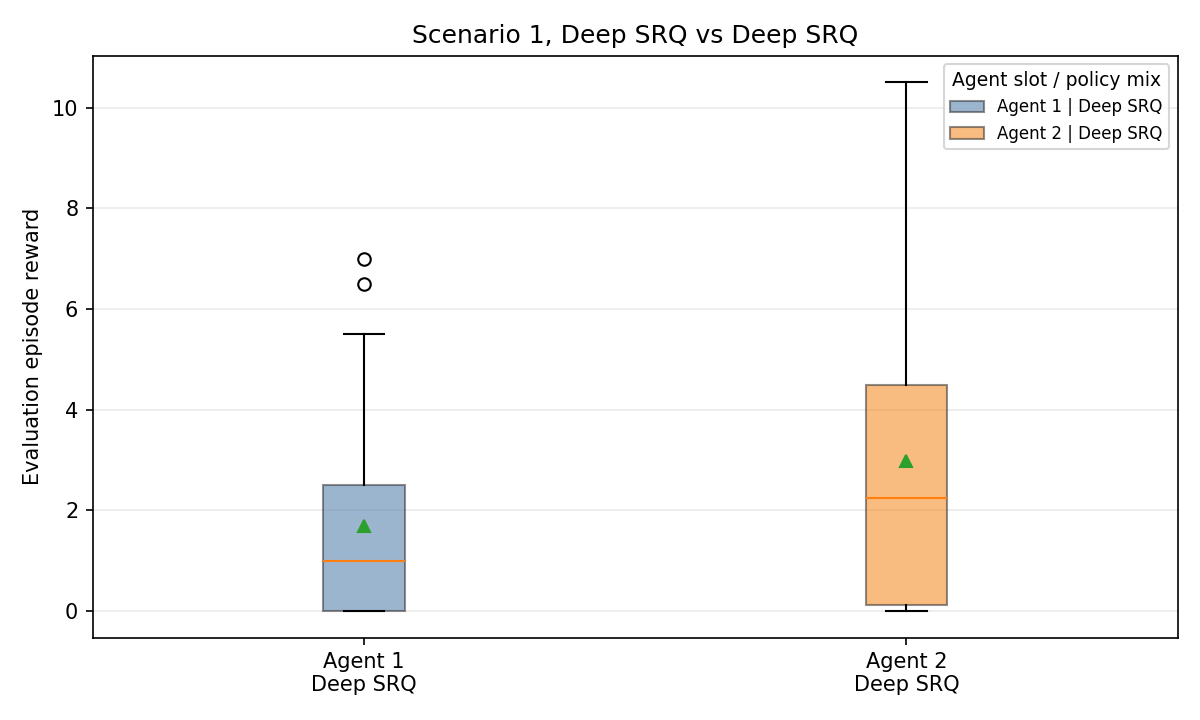

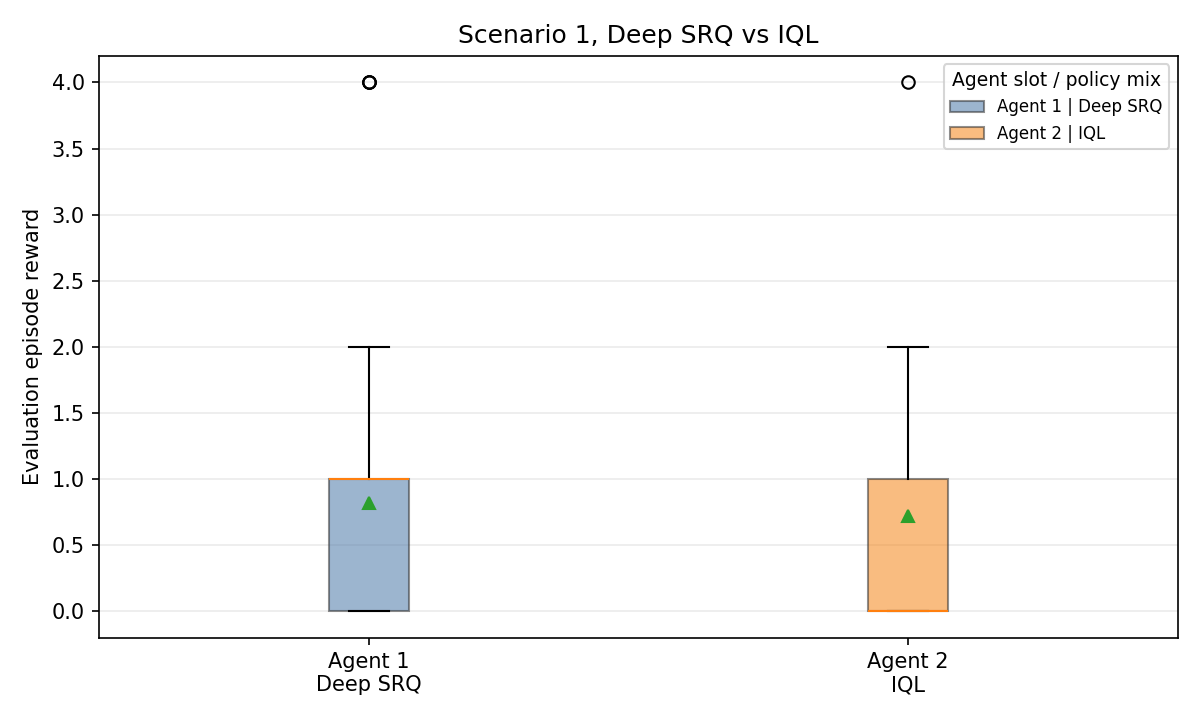

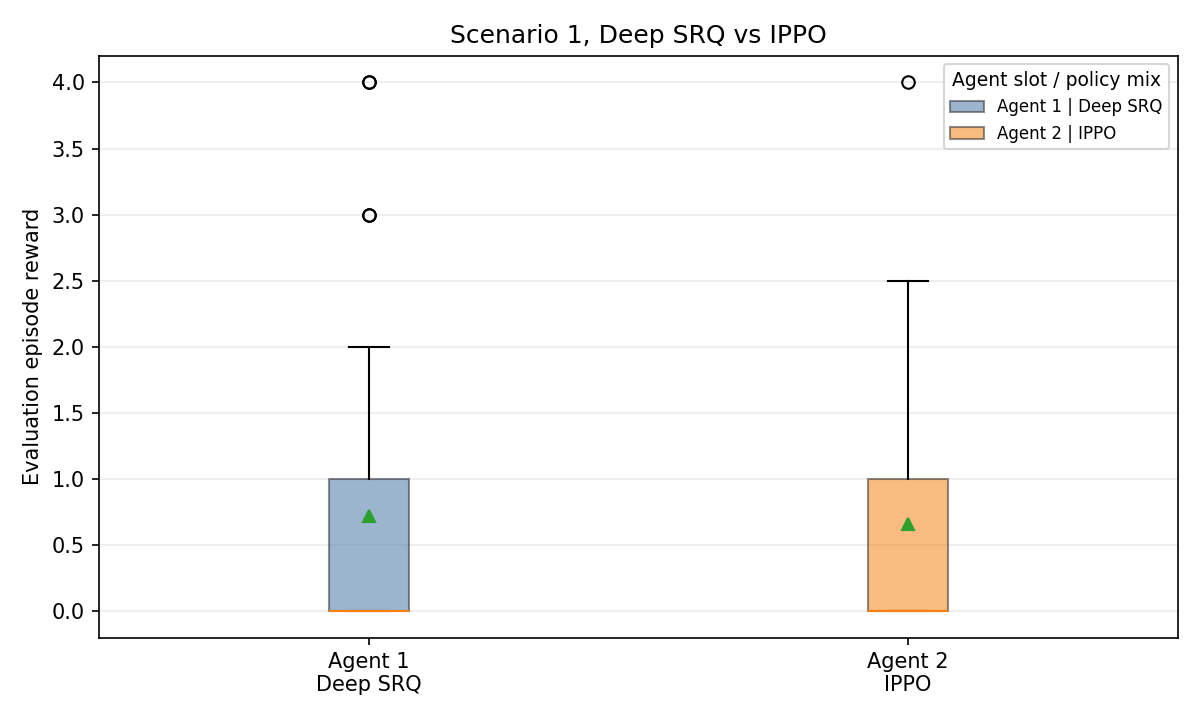

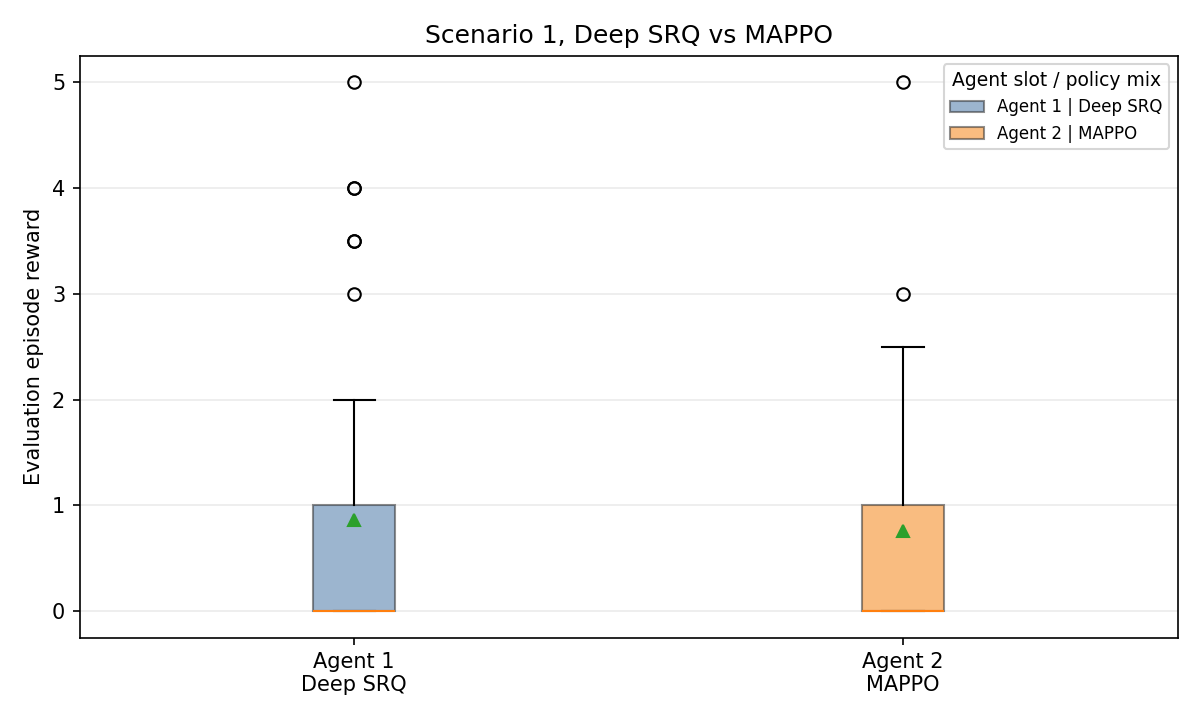

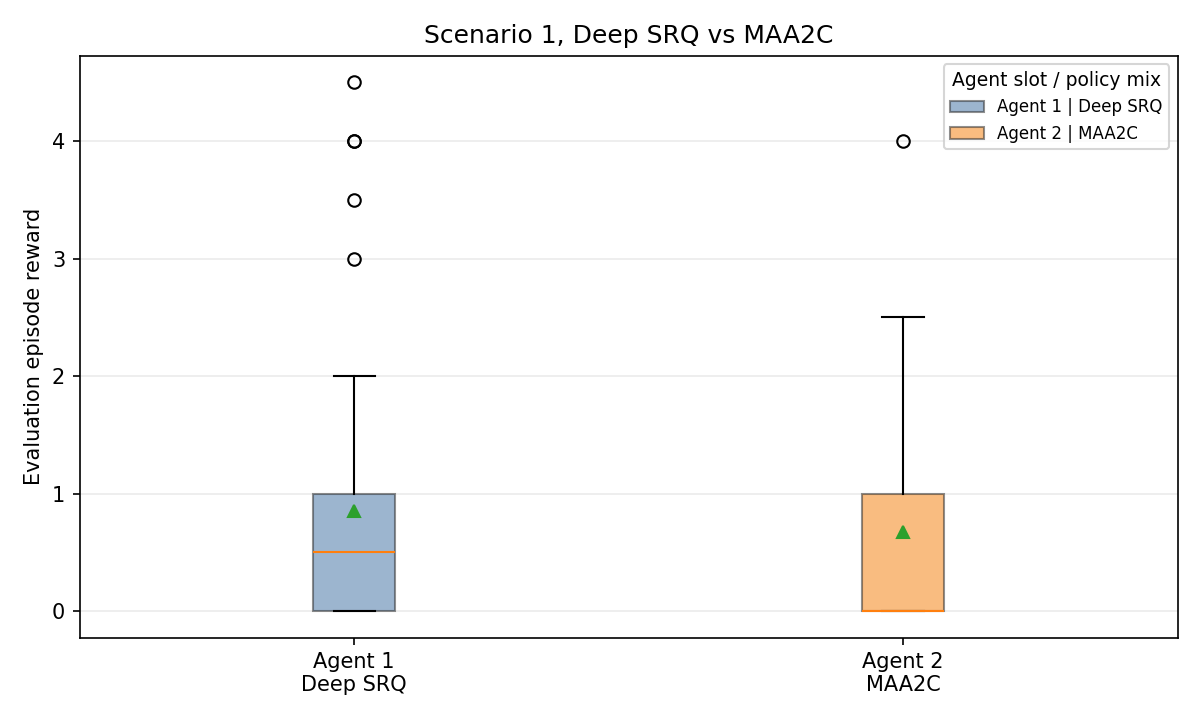

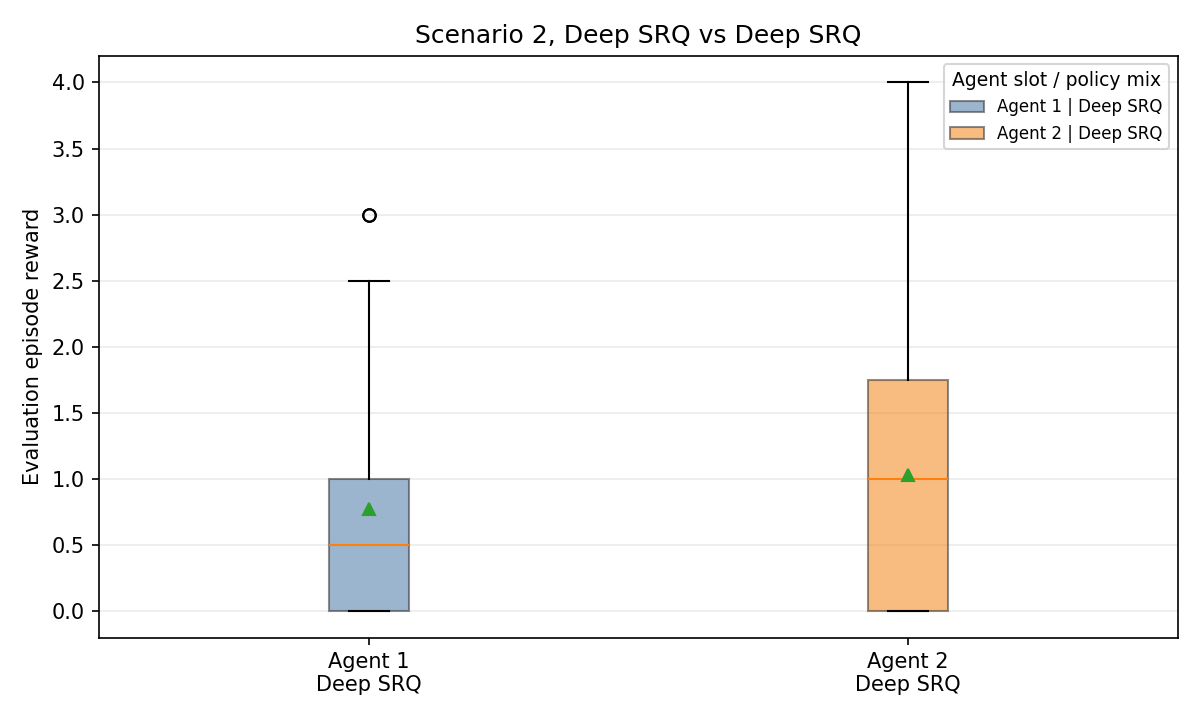

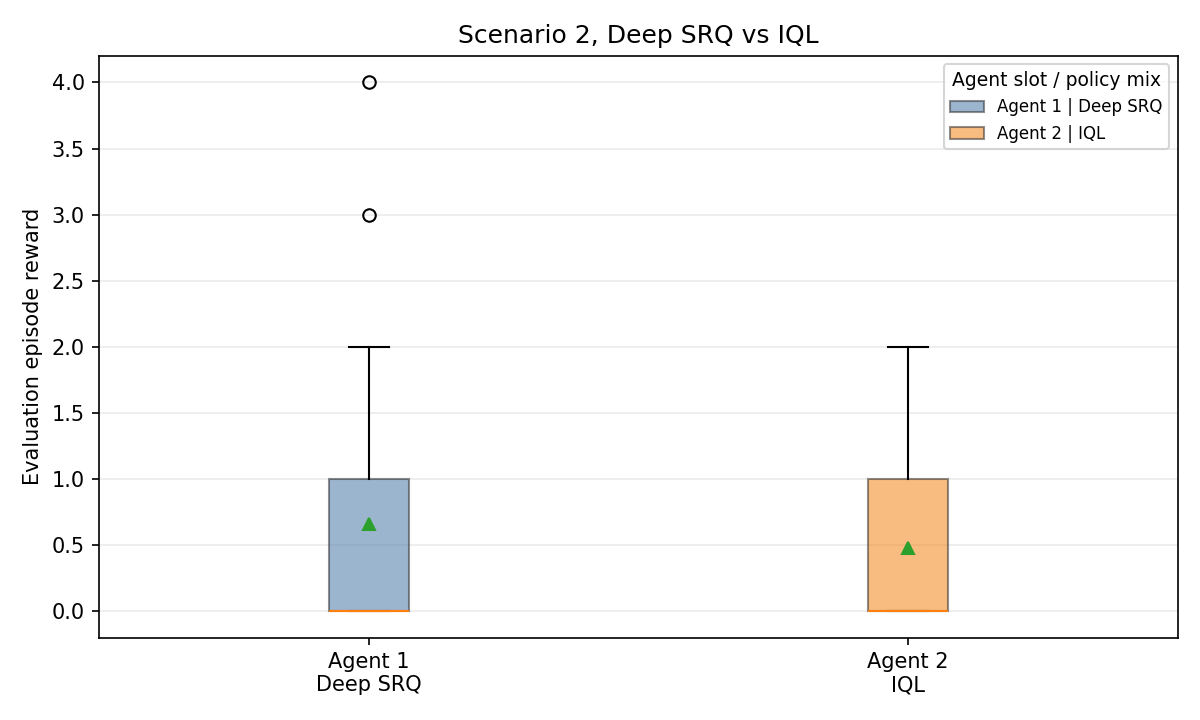

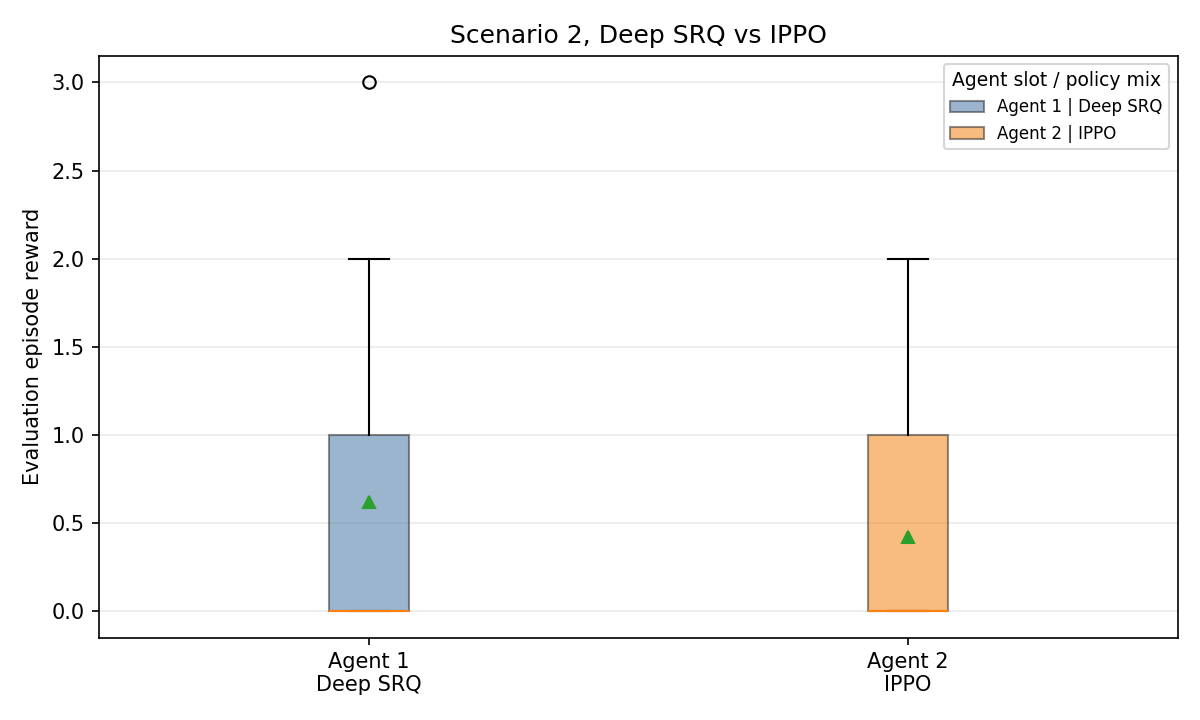

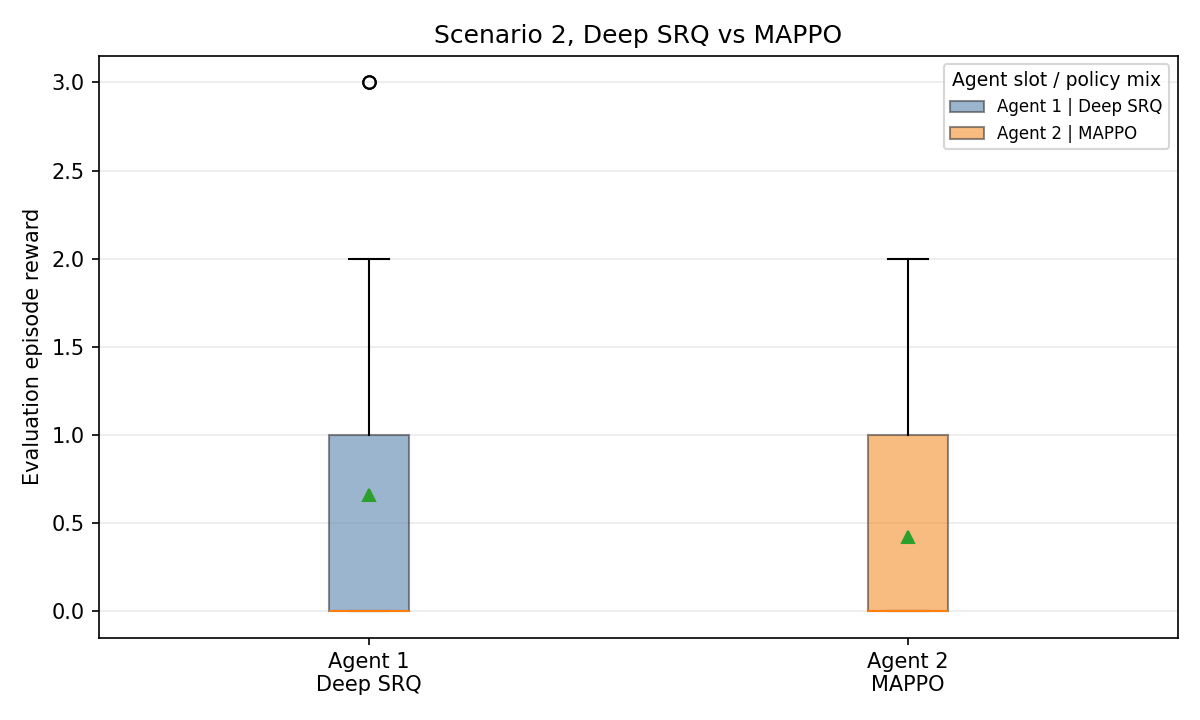

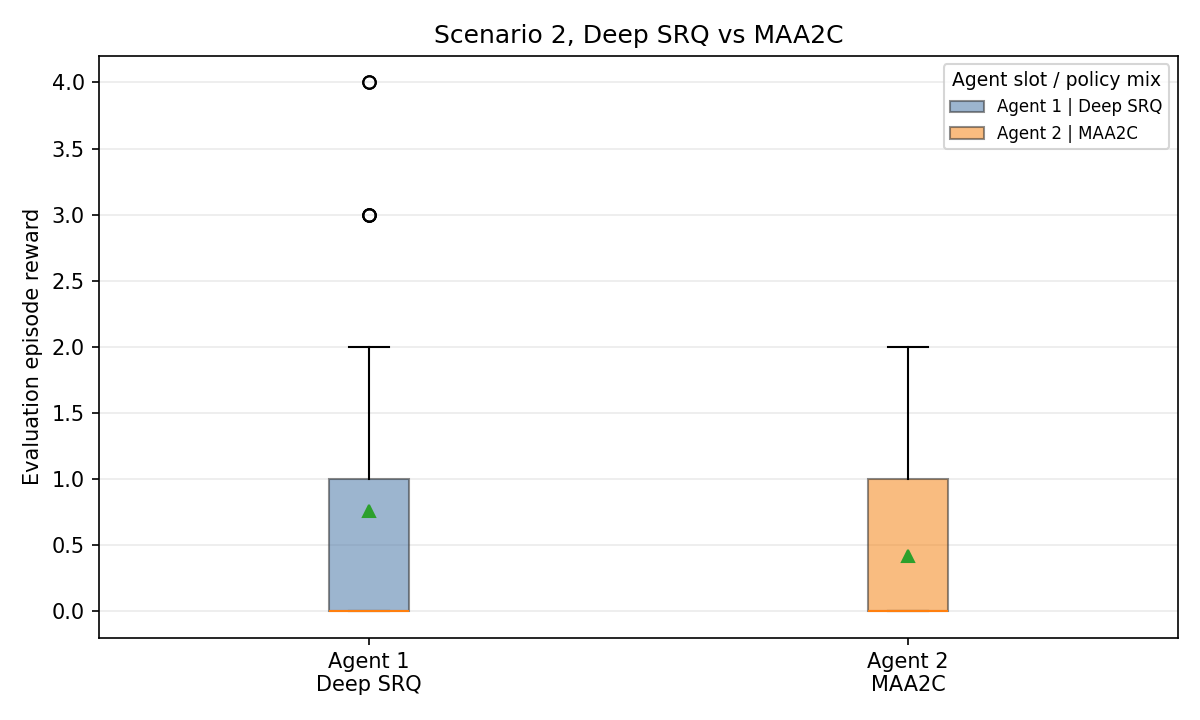

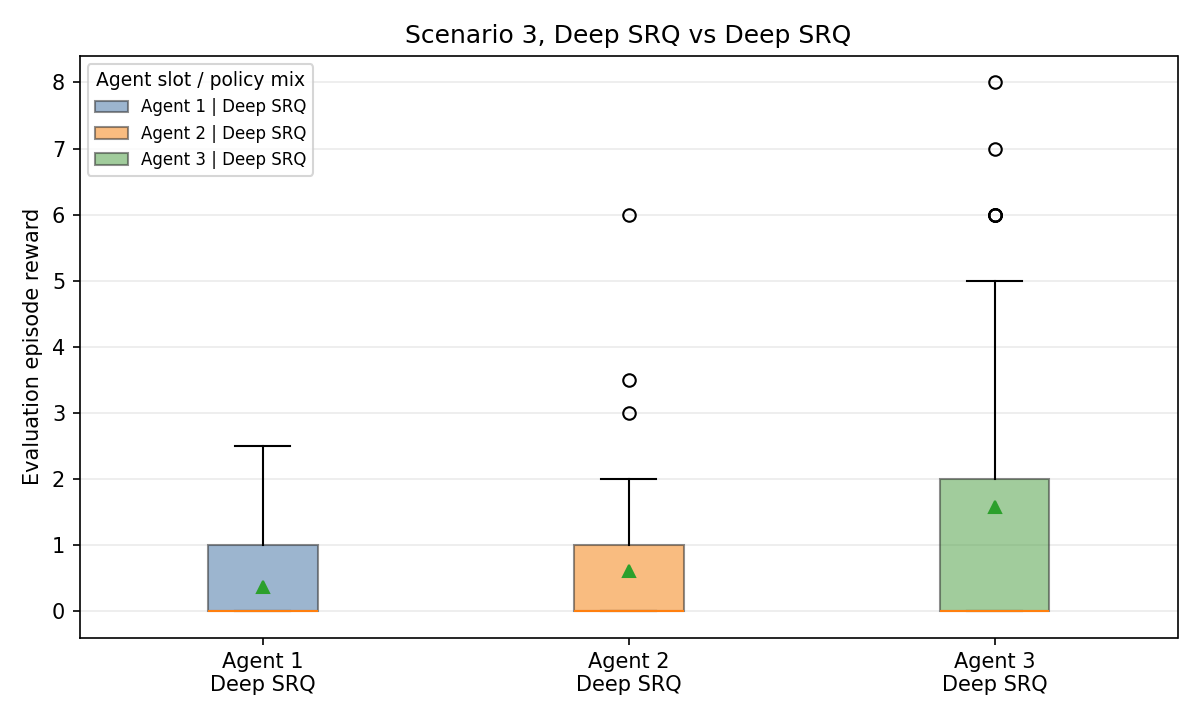

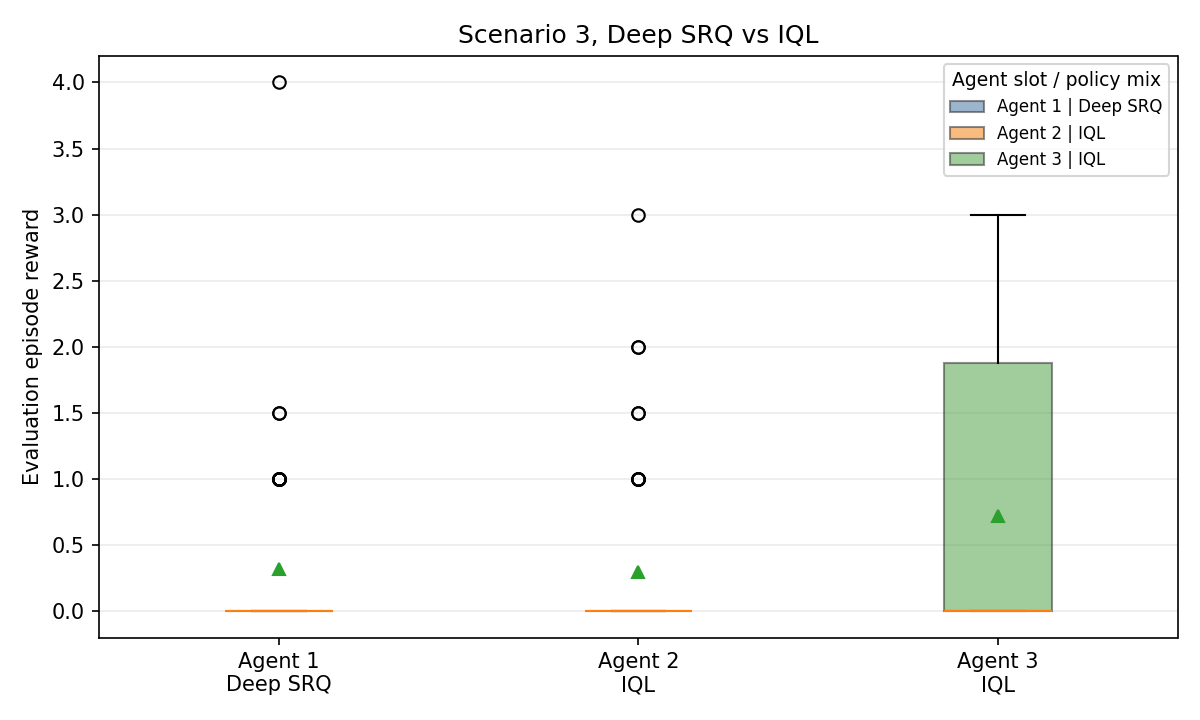

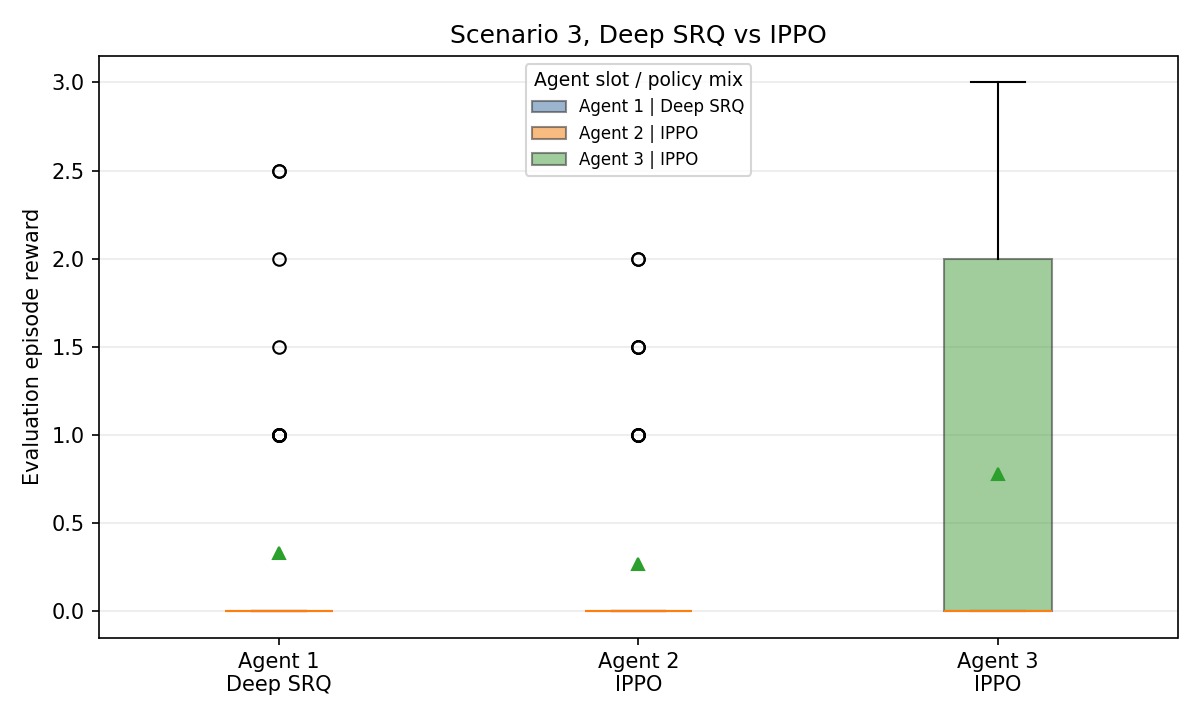

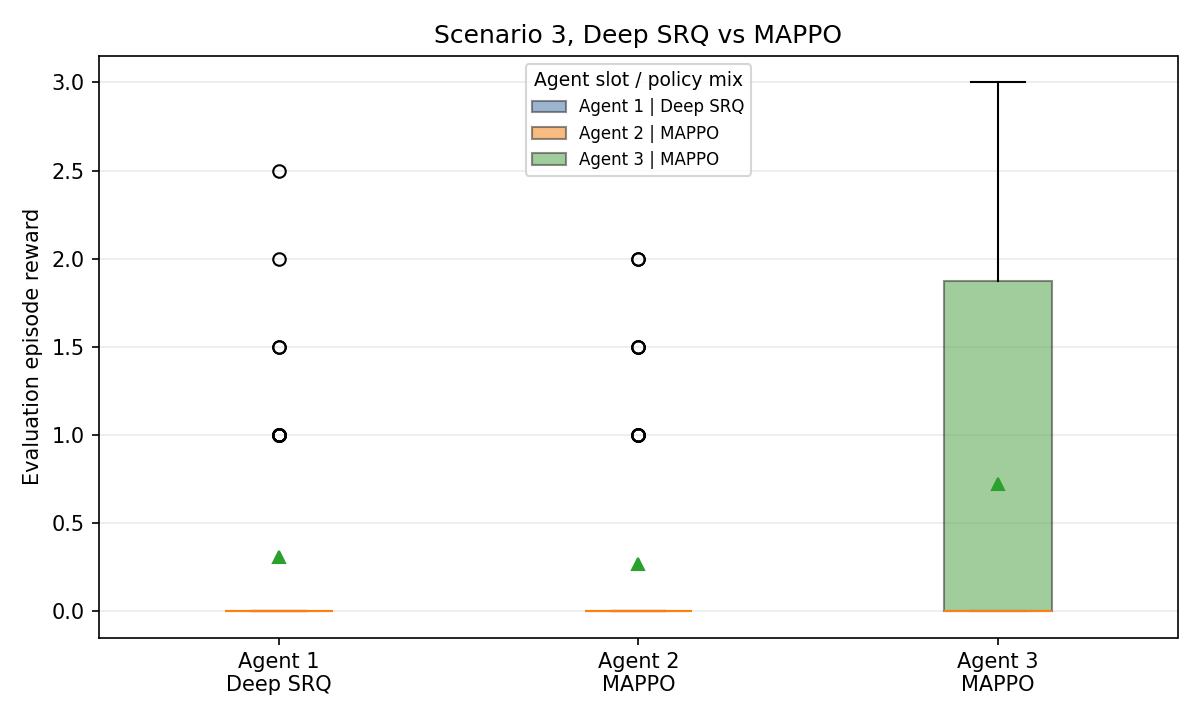

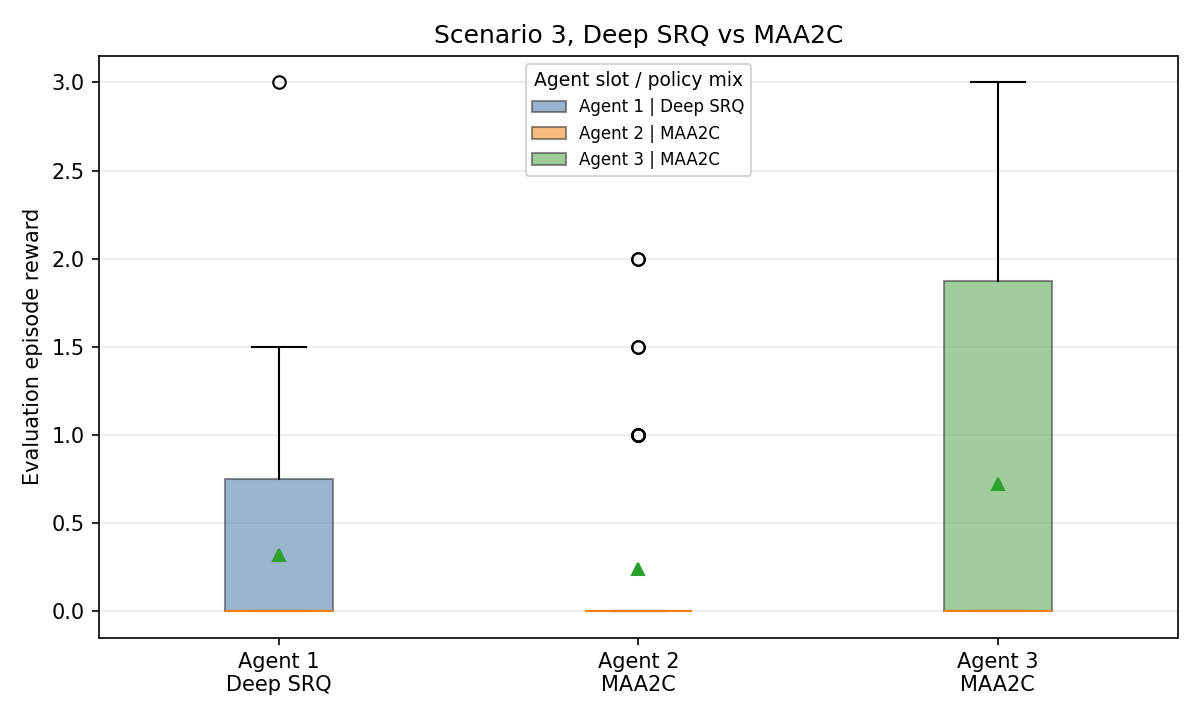

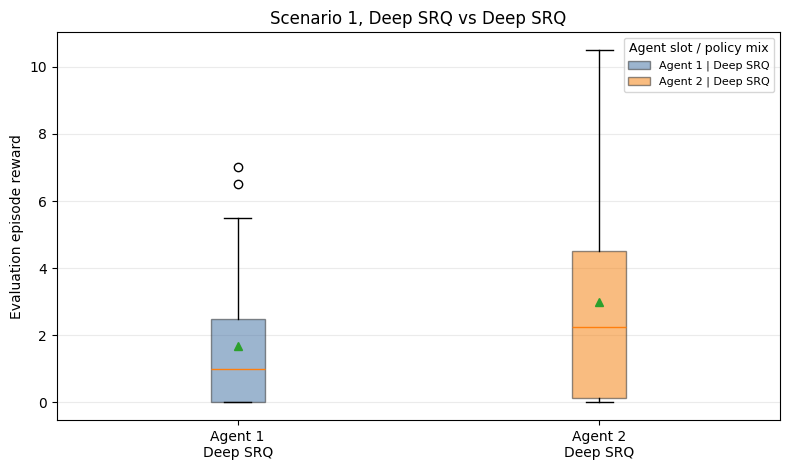

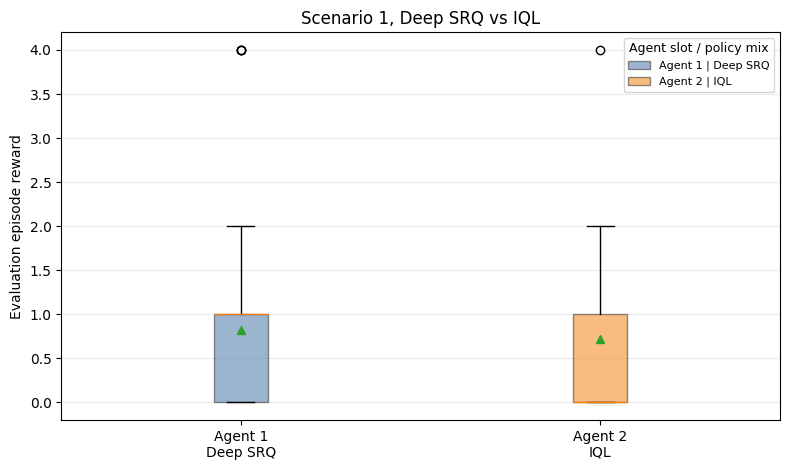

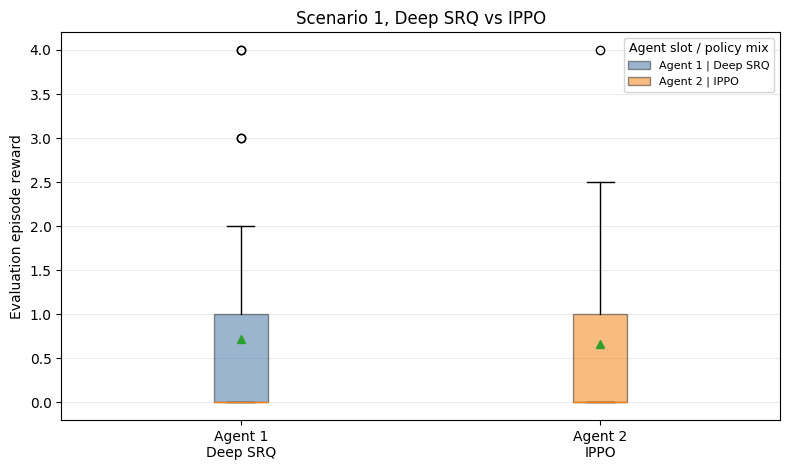

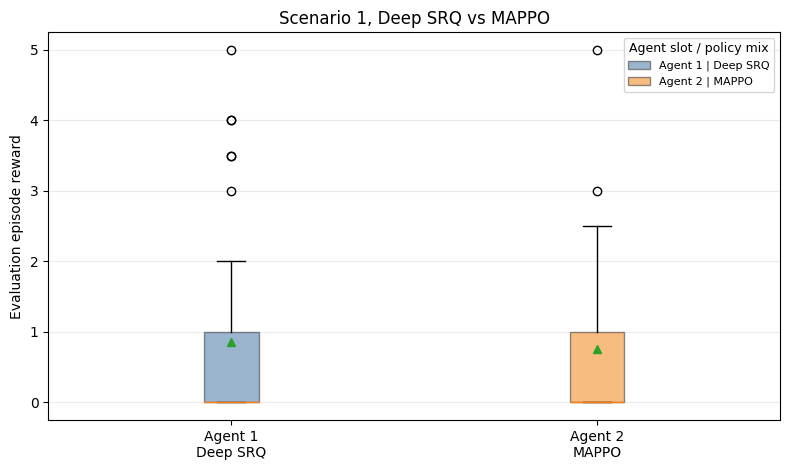

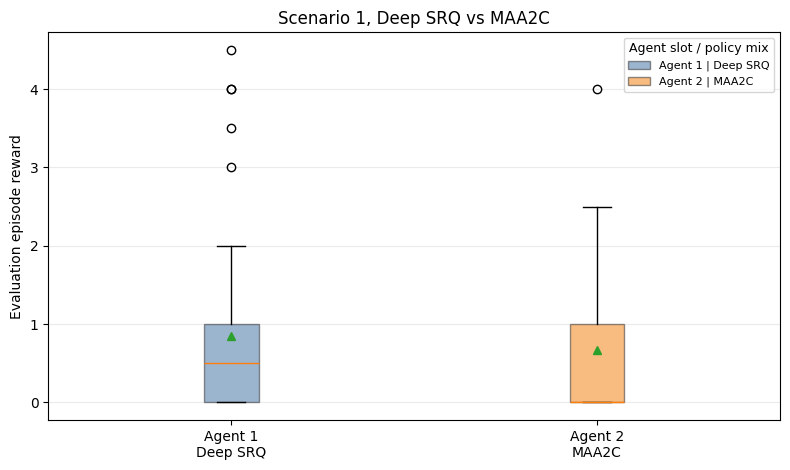

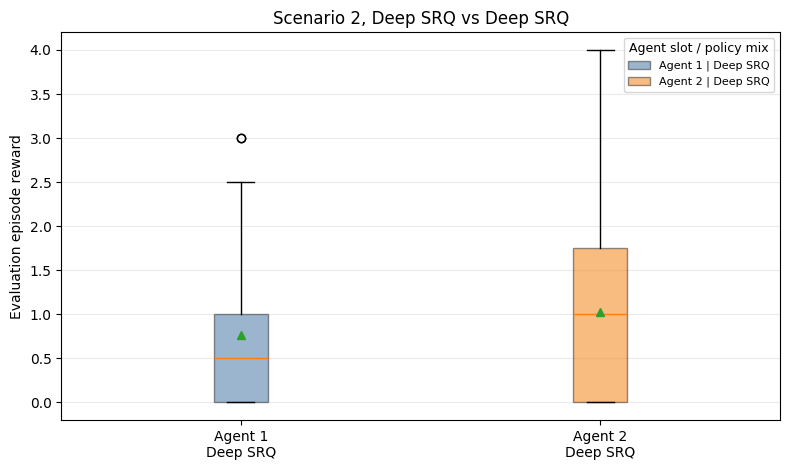

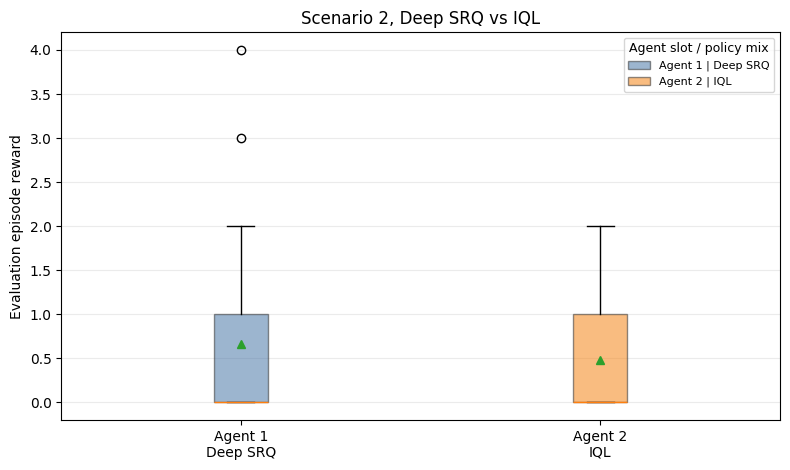

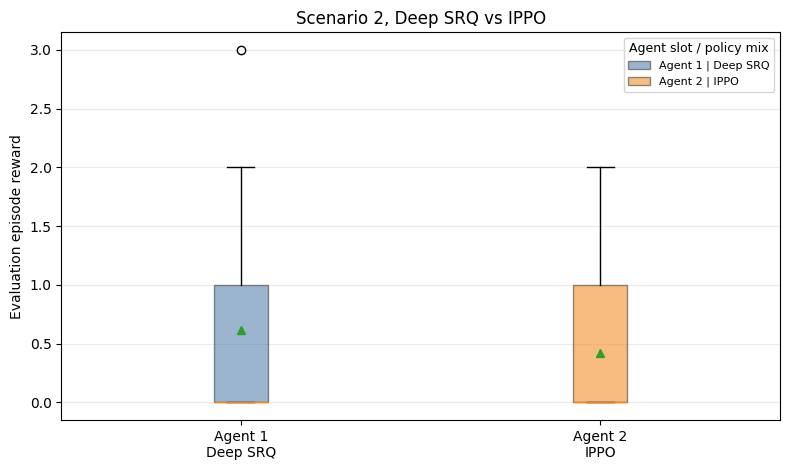

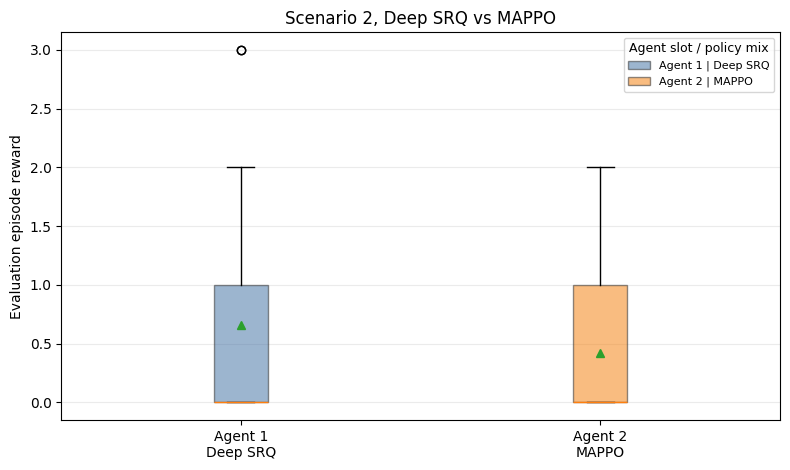

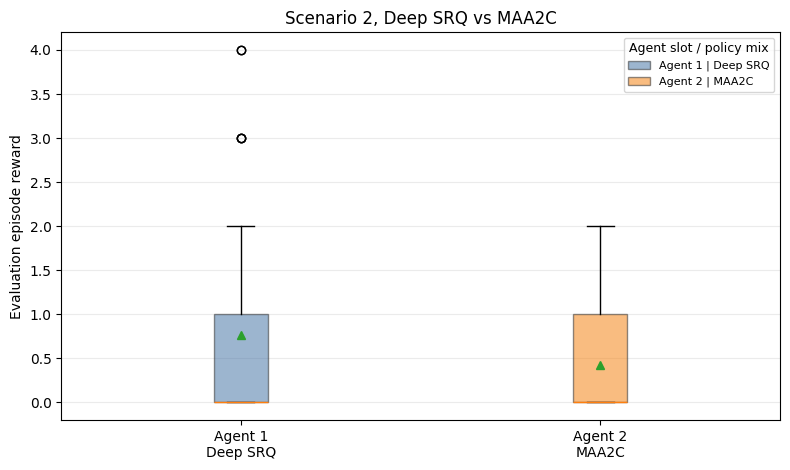

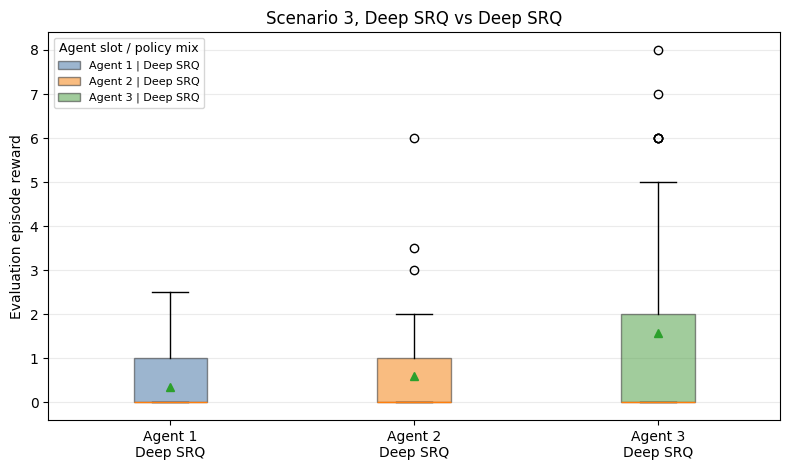

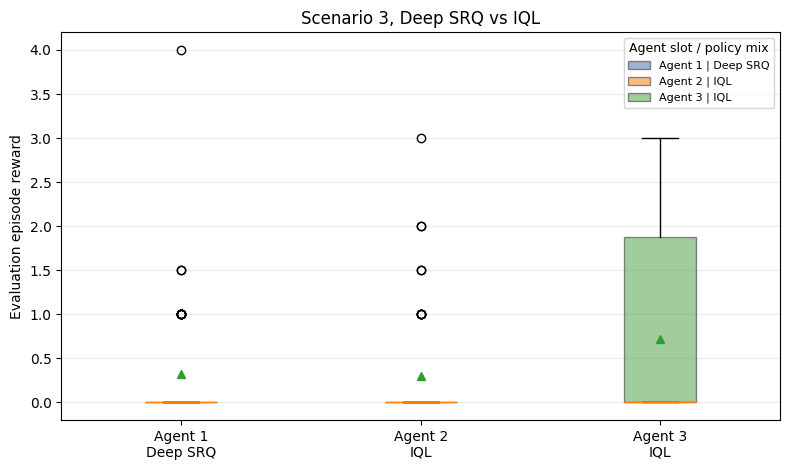

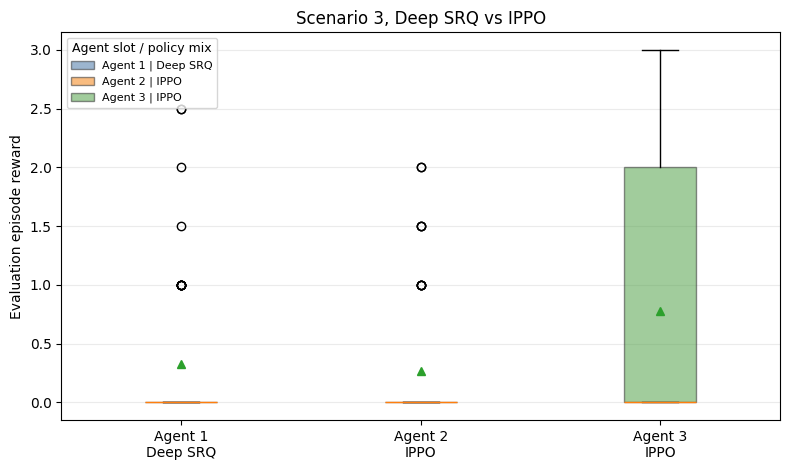

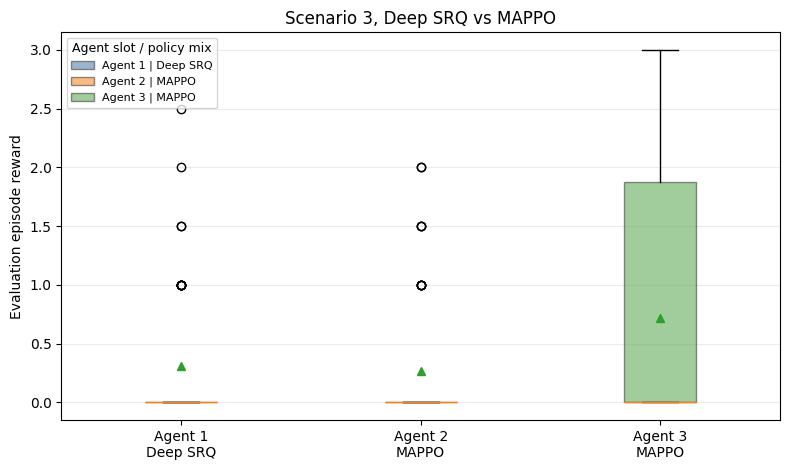

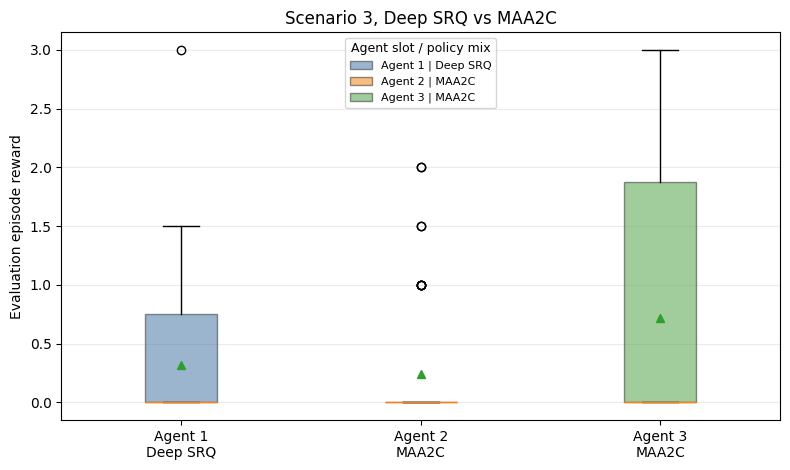

In [5]:
deep_srq_path_pool_eval_eps_0_5 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.5,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_5)


## Robust epsilon 1

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

...

lbf_10x10_3p_8f_levels123 | Deep SRQ:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IQL:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs IPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAPPO:   0%|          | 0/50 [00:00<?, ?episode/s]

lbf_10x10_3p_8f_levels123 | Deep SRQ vs MAA2C:   0%|          | 0/50 [00:00<?, ?episode/s]

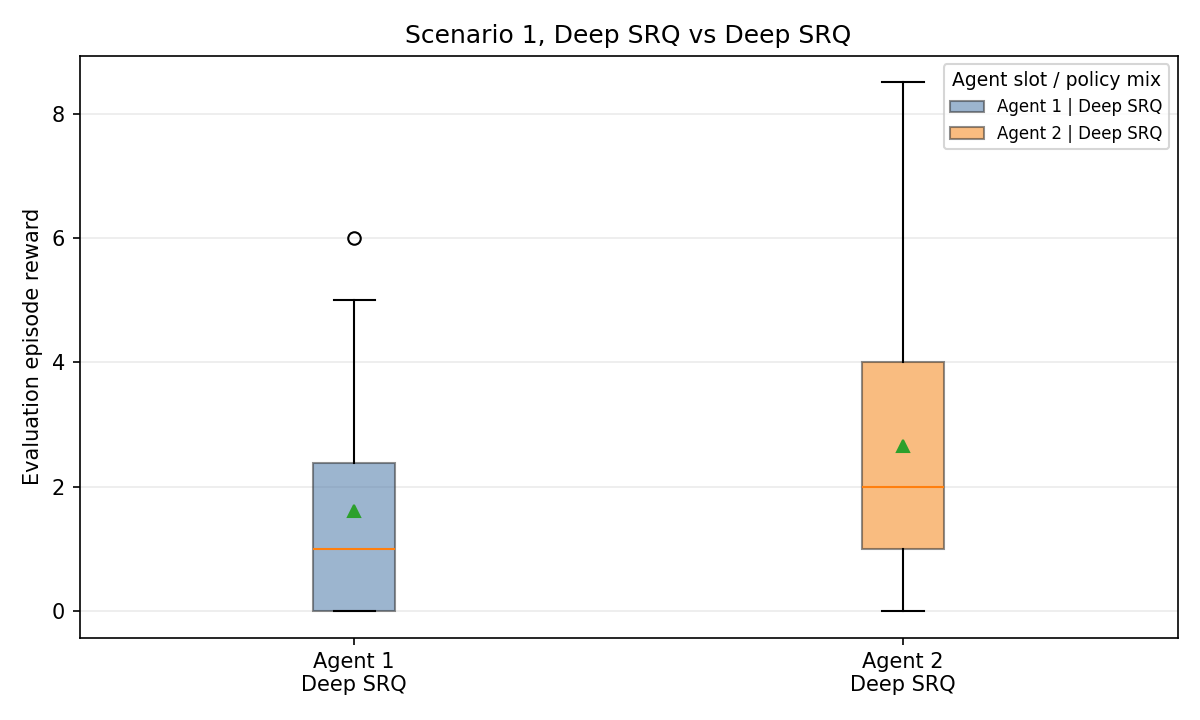

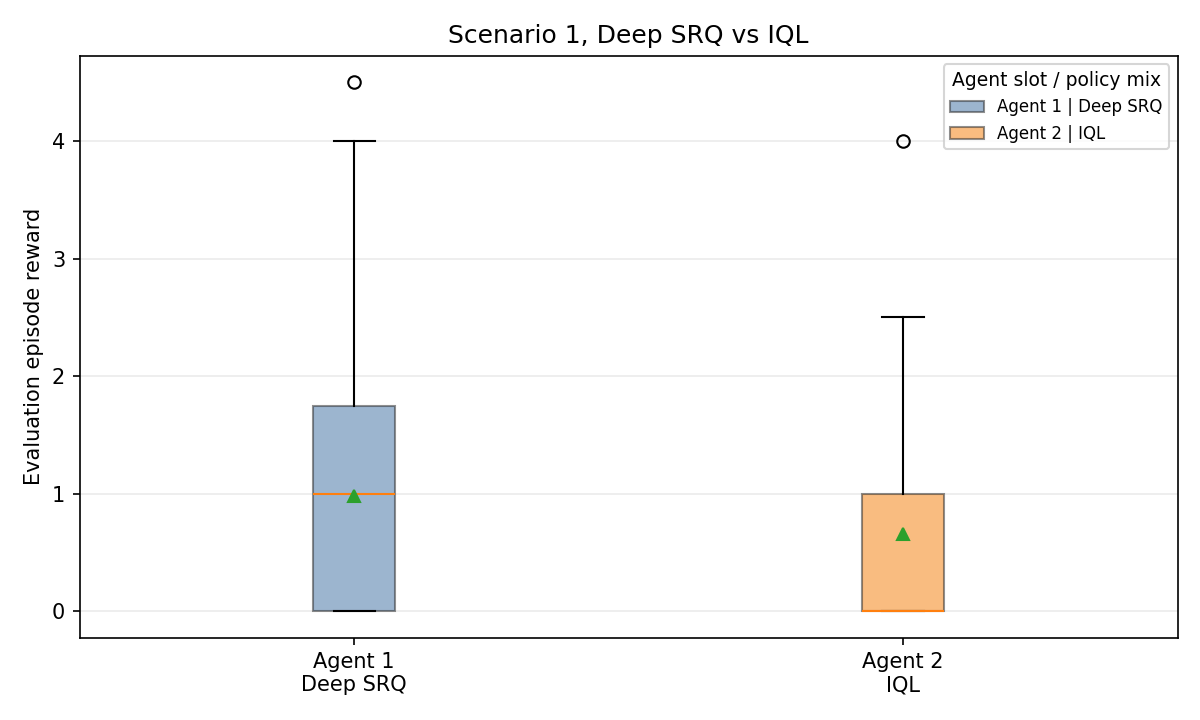

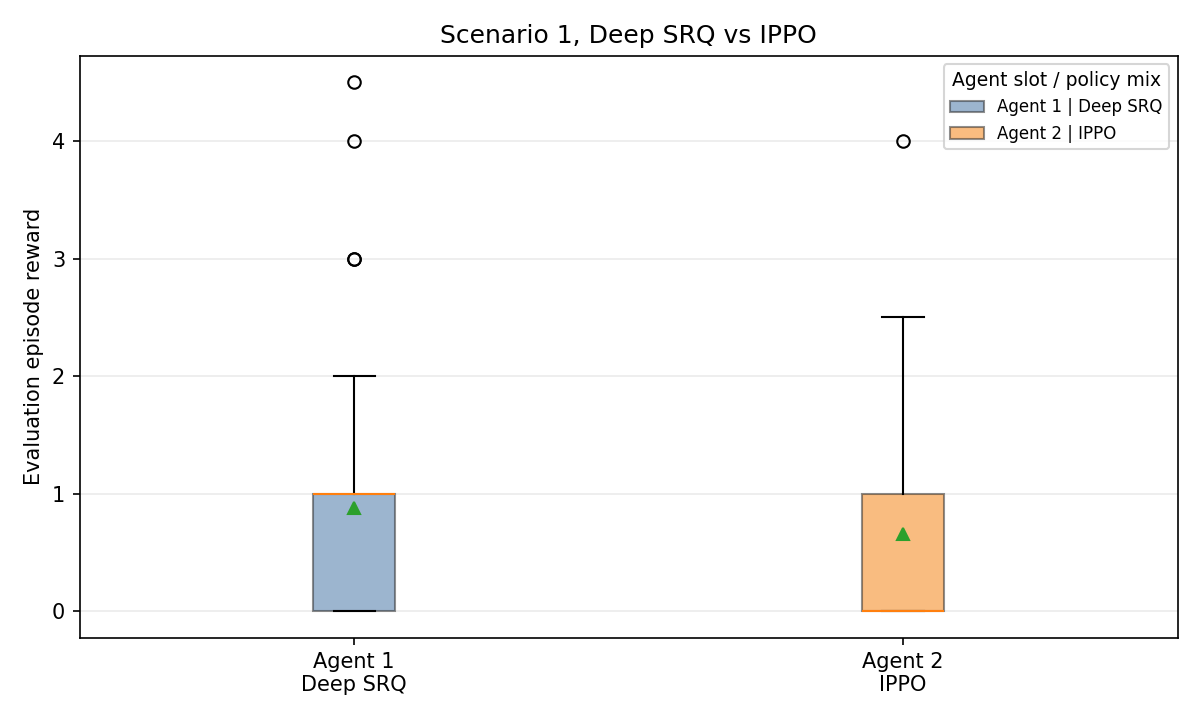

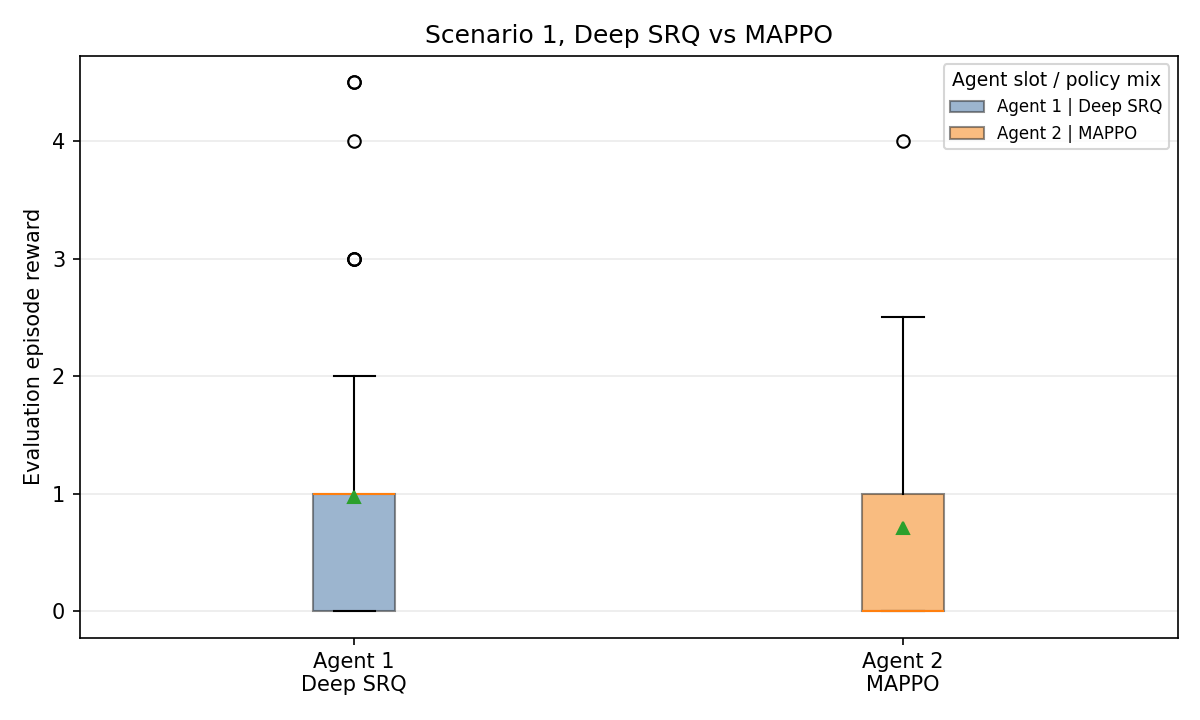

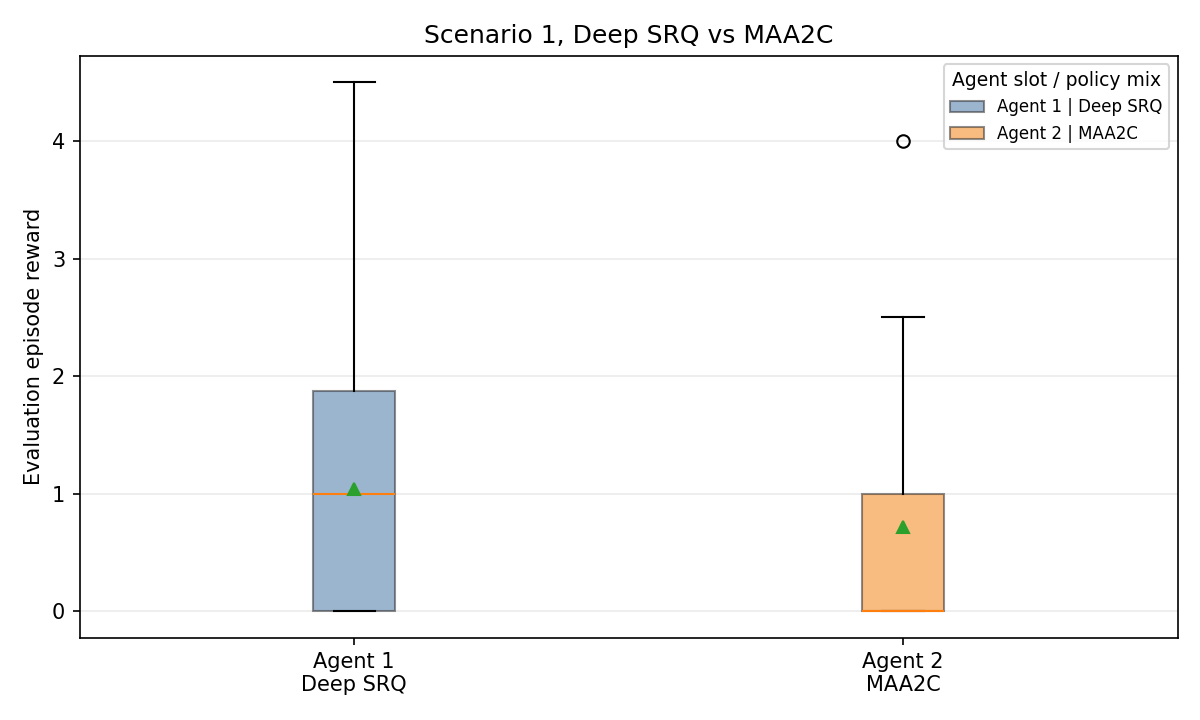

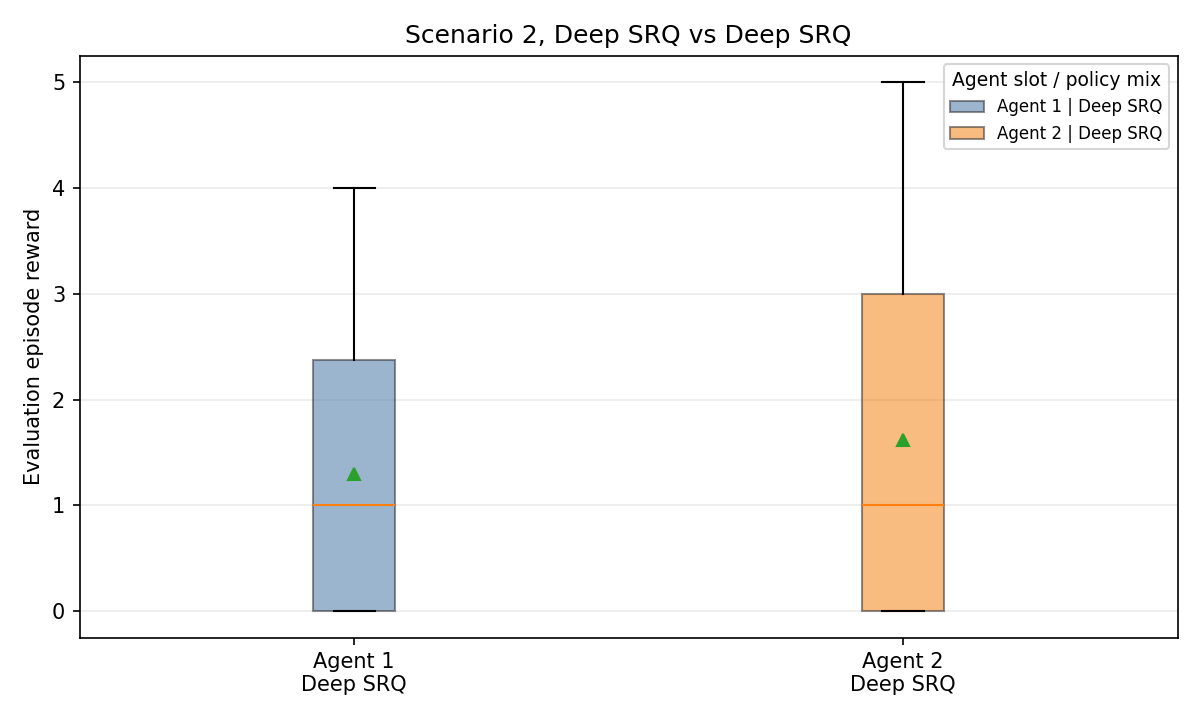

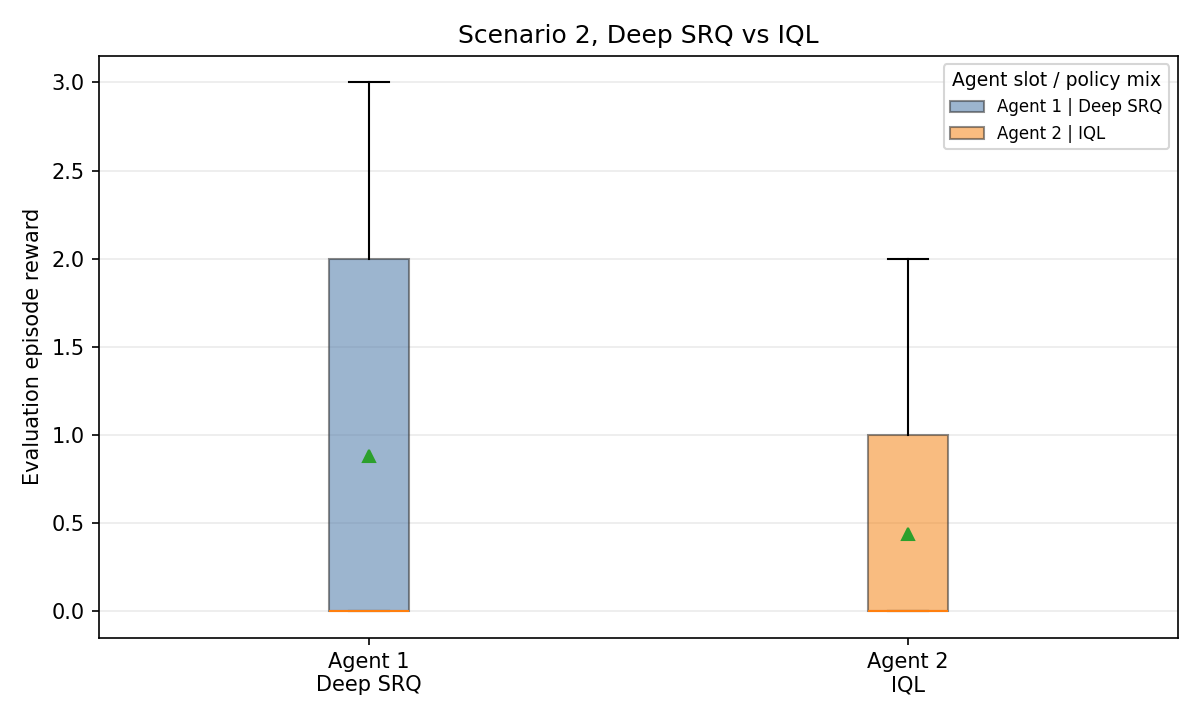

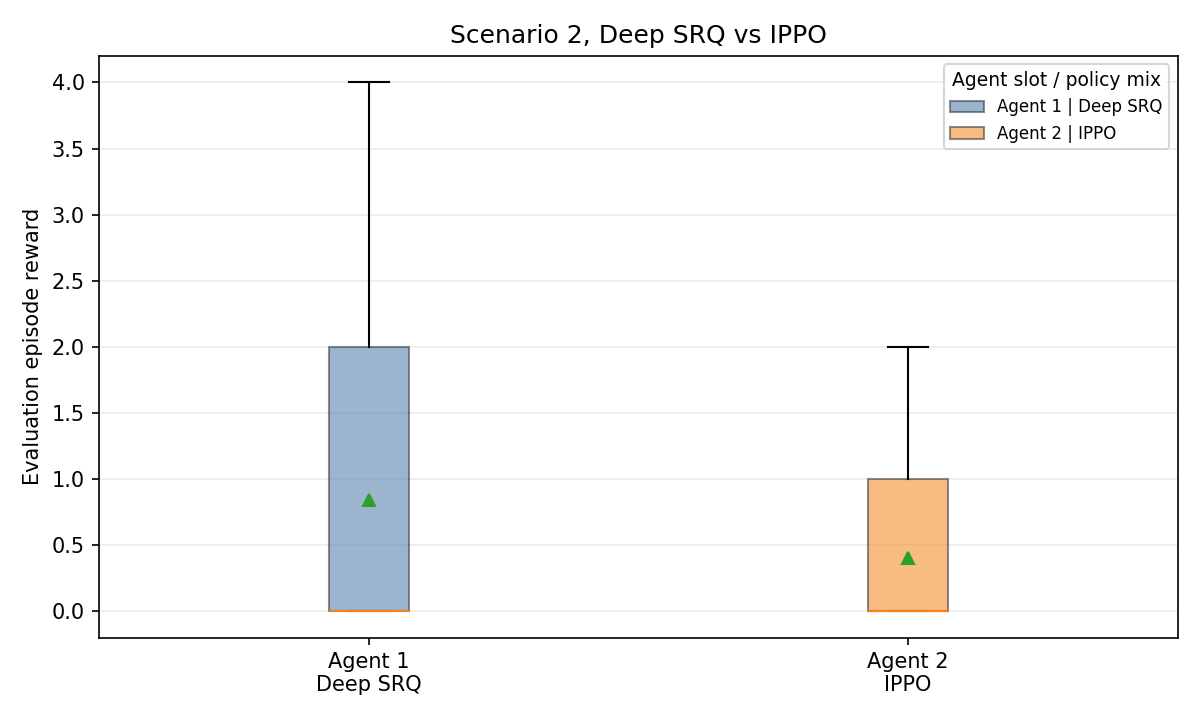

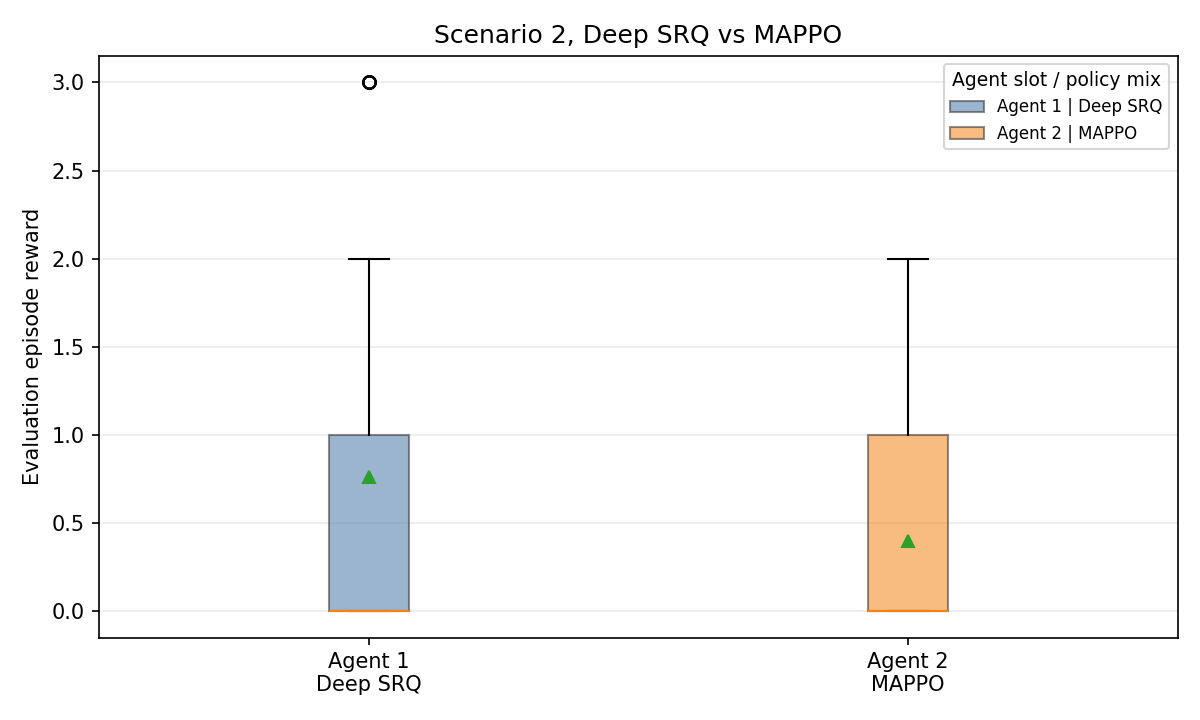

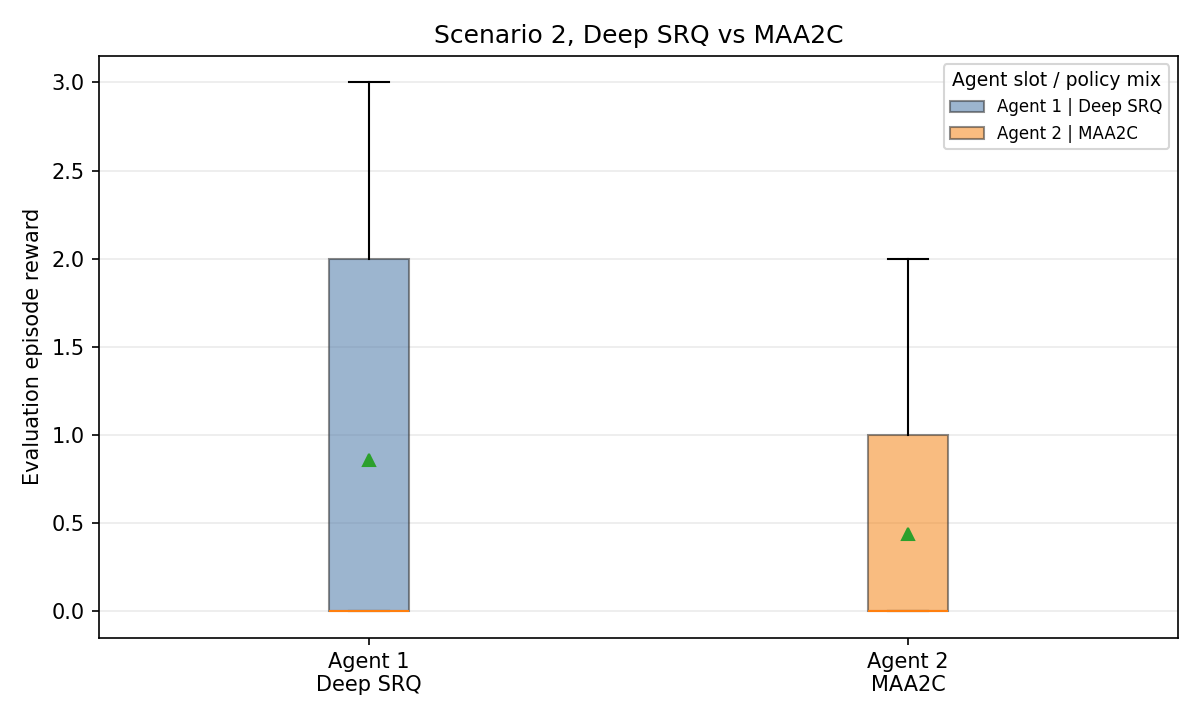

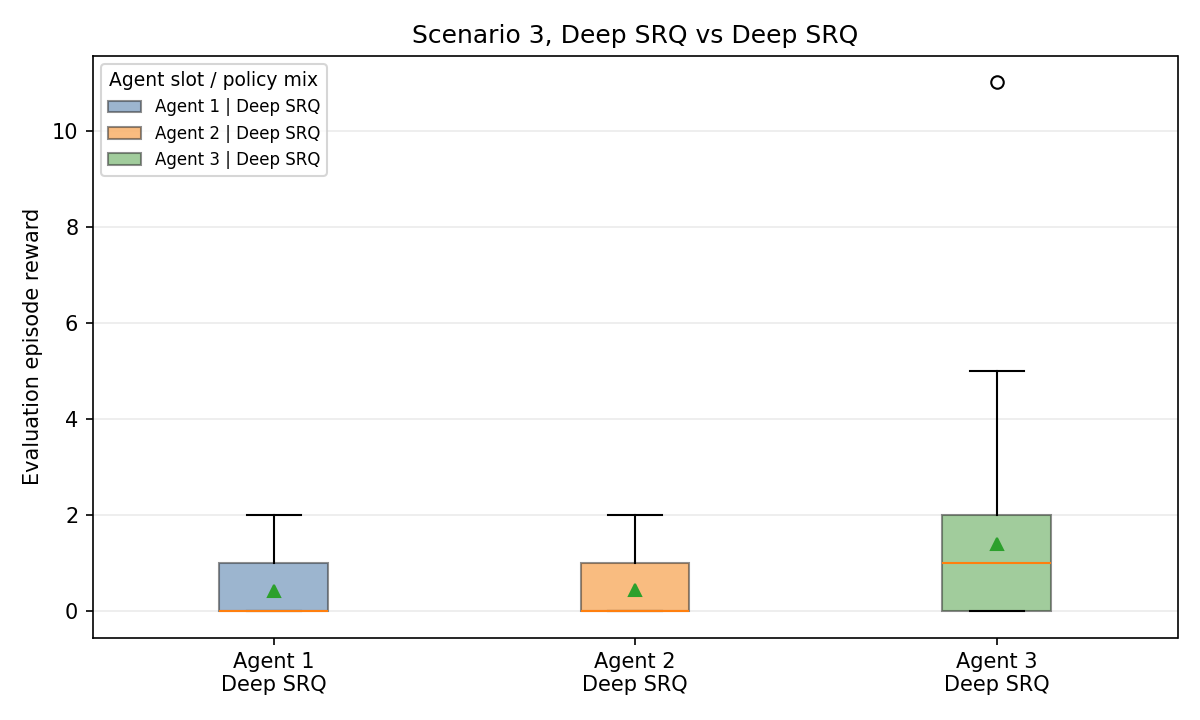

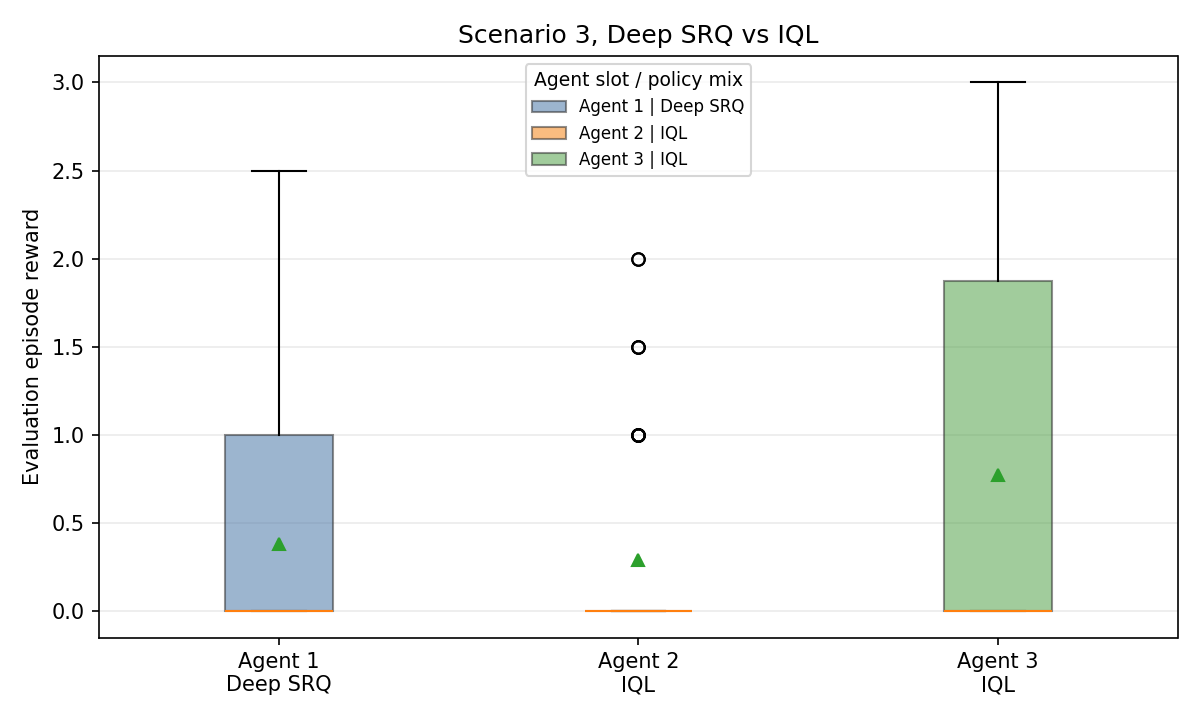

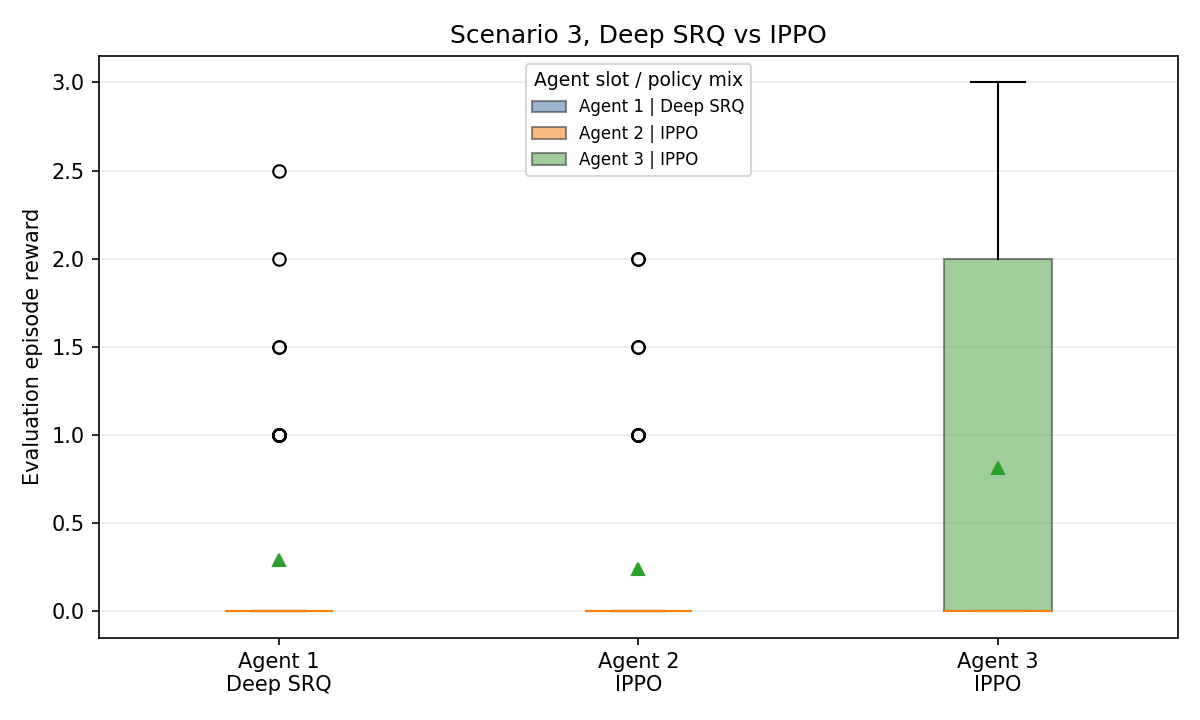

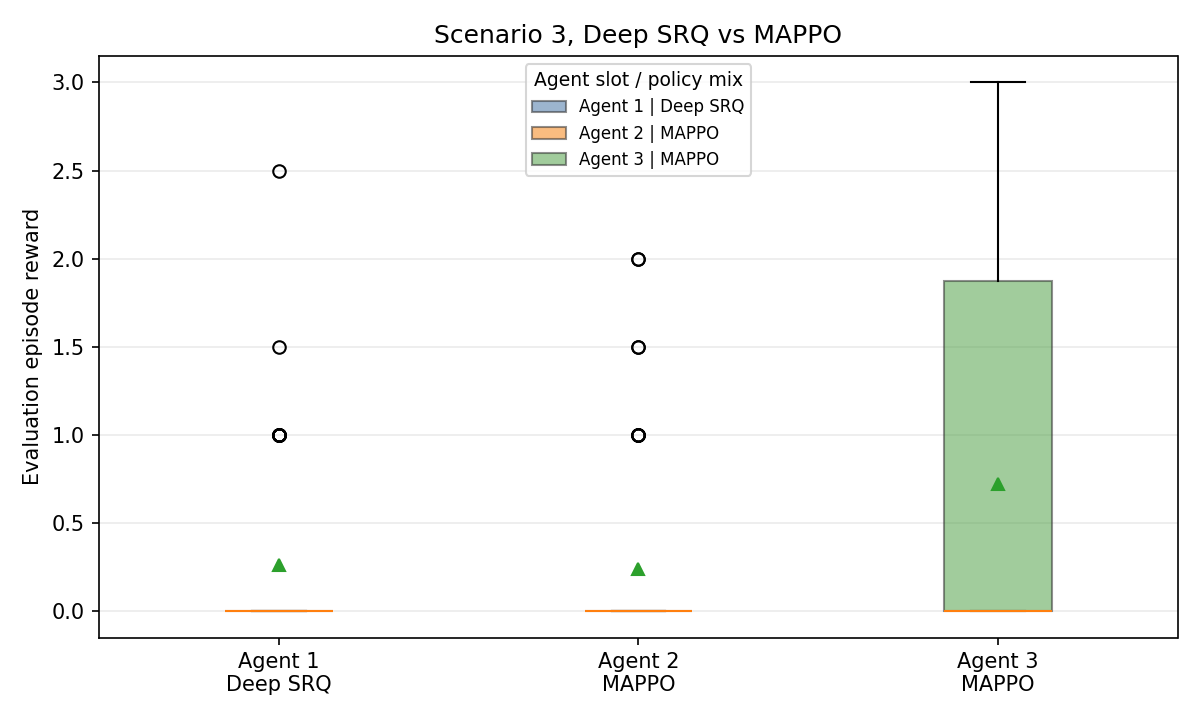

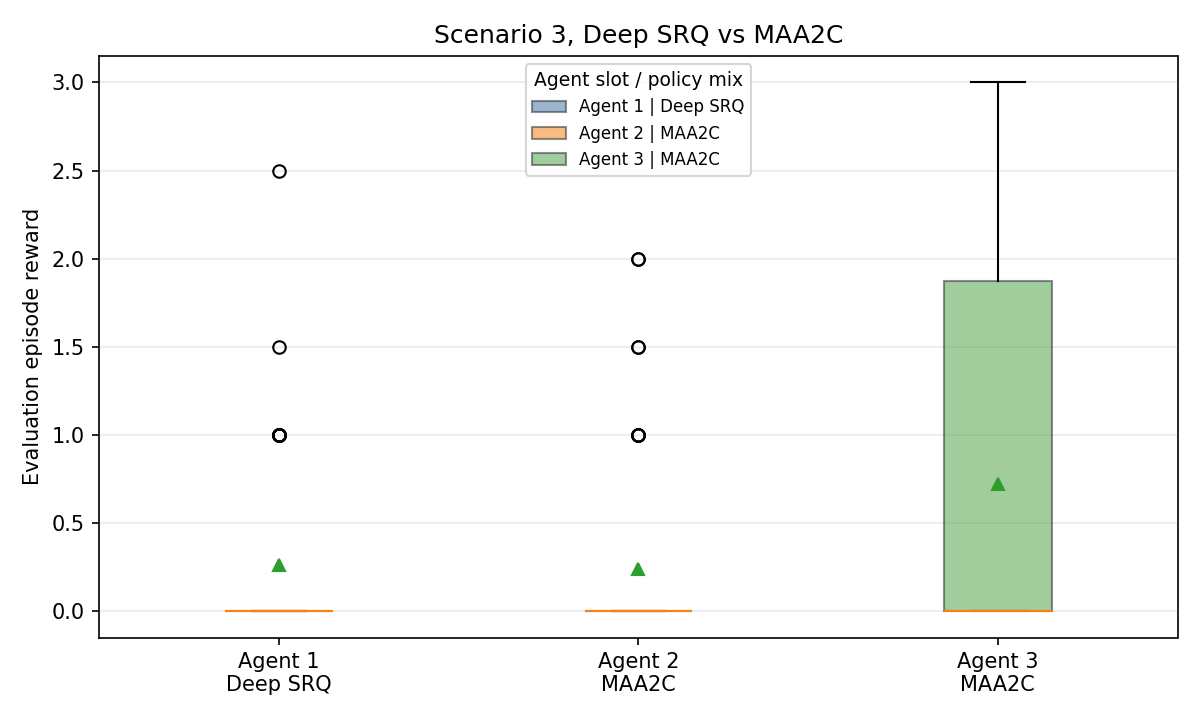

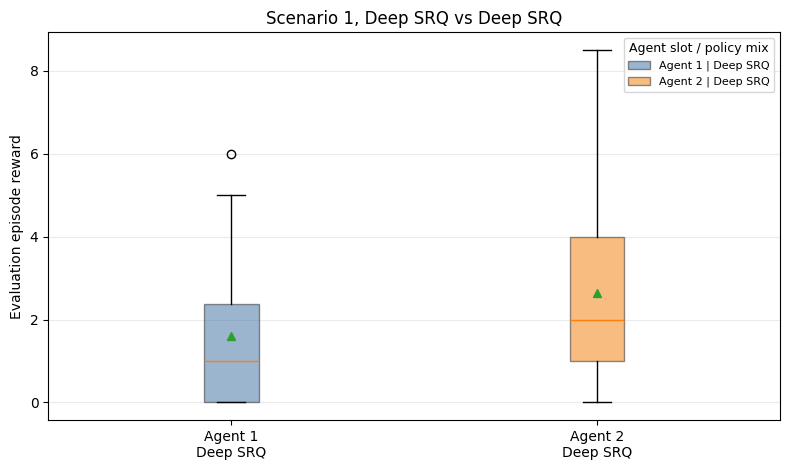

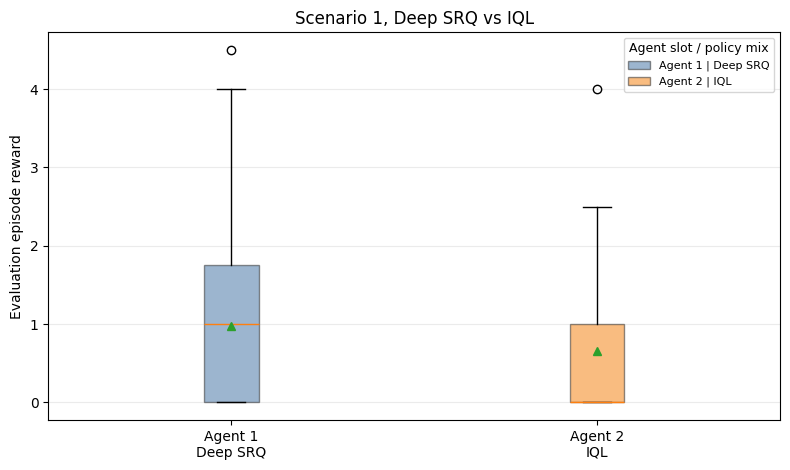

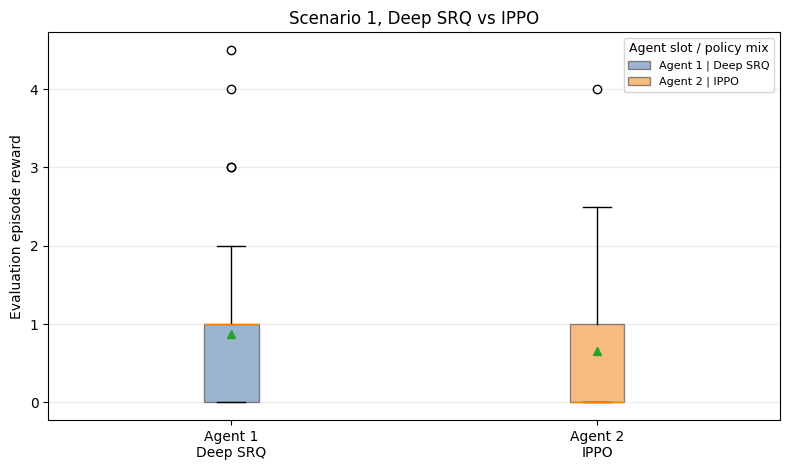

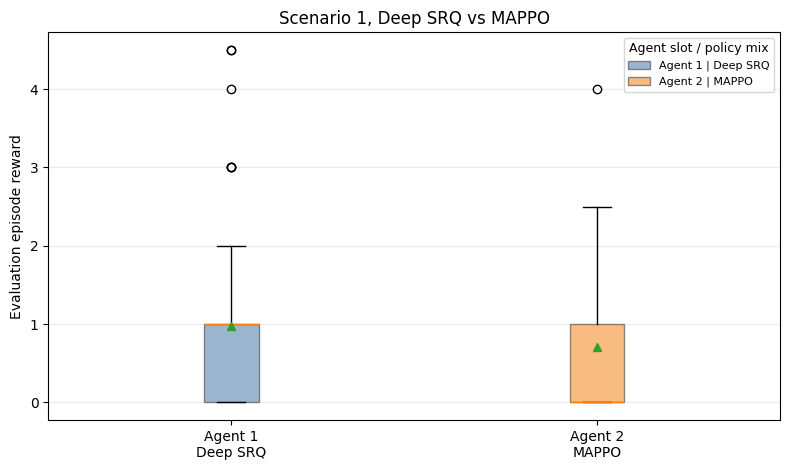

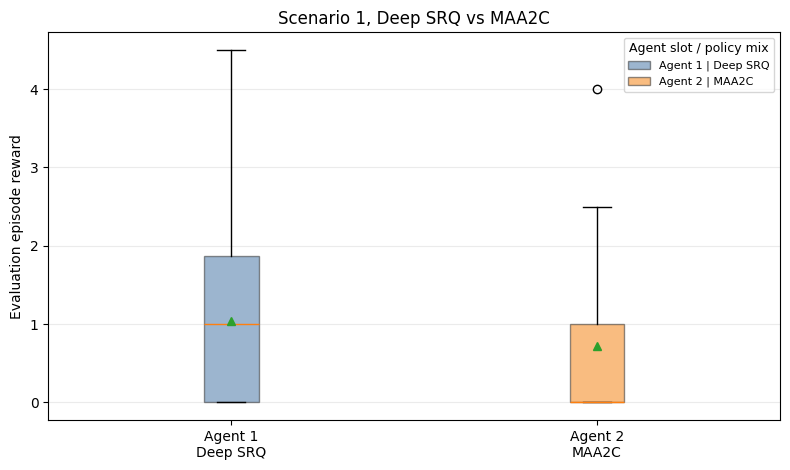

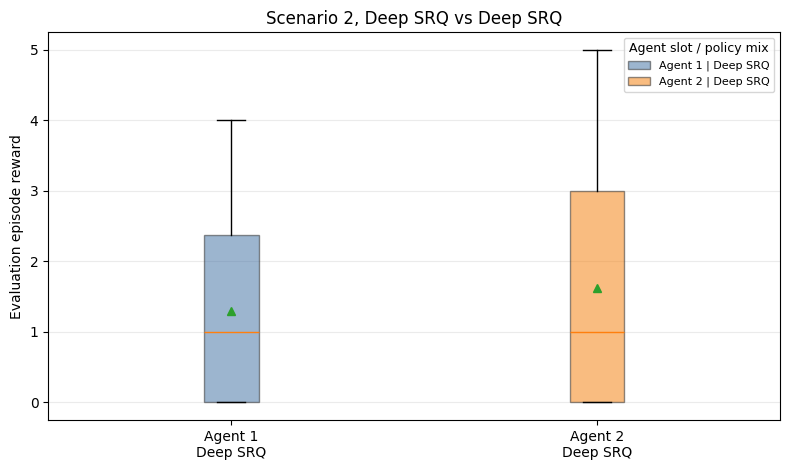

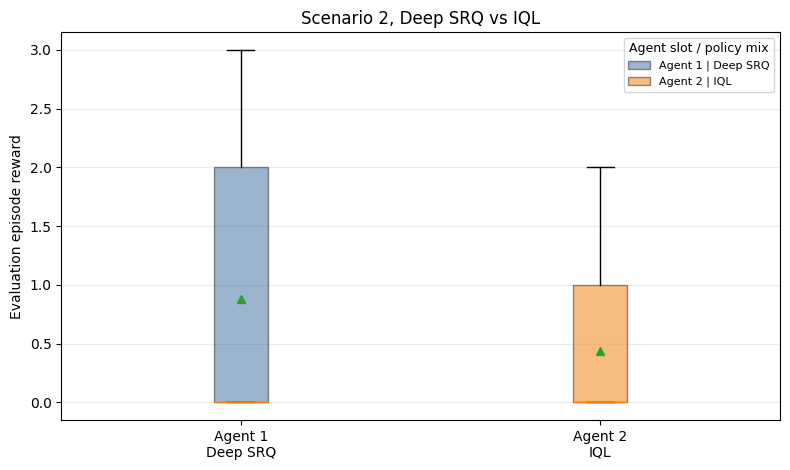

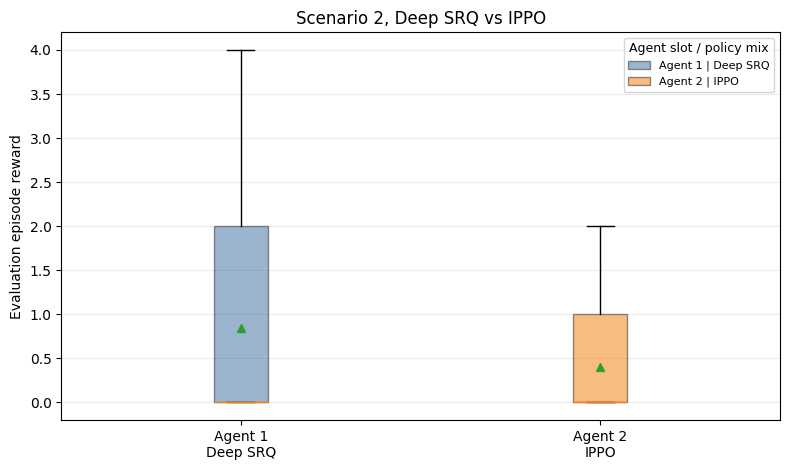

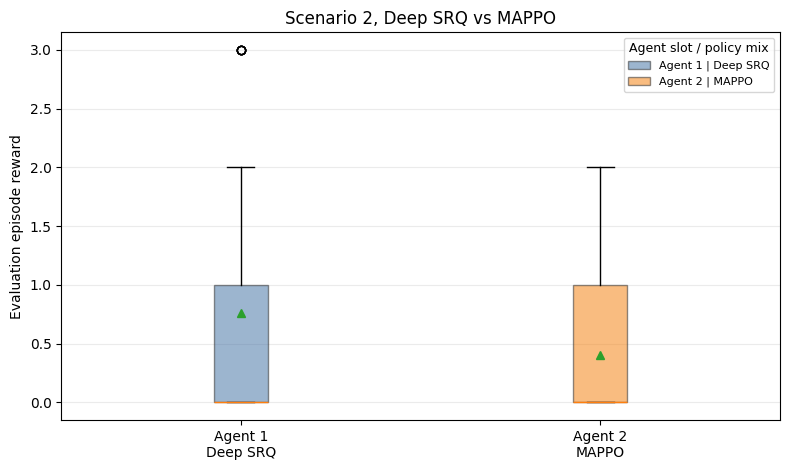

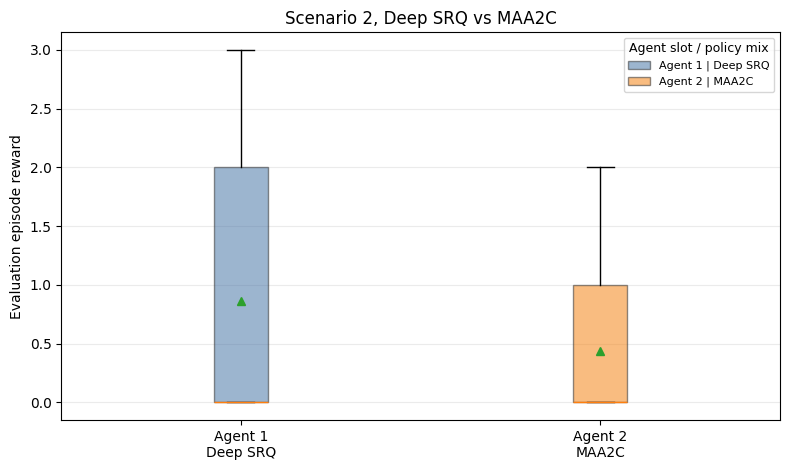

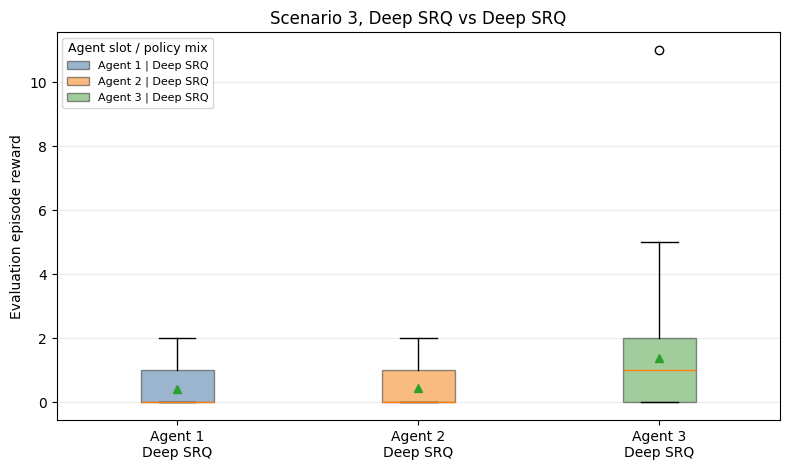

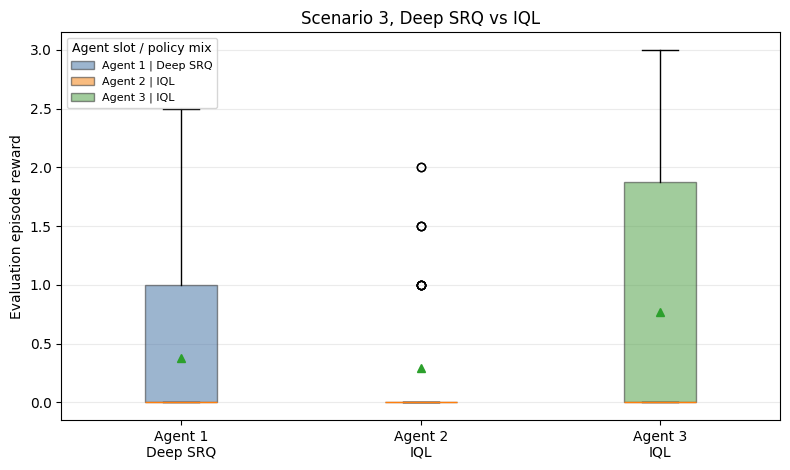

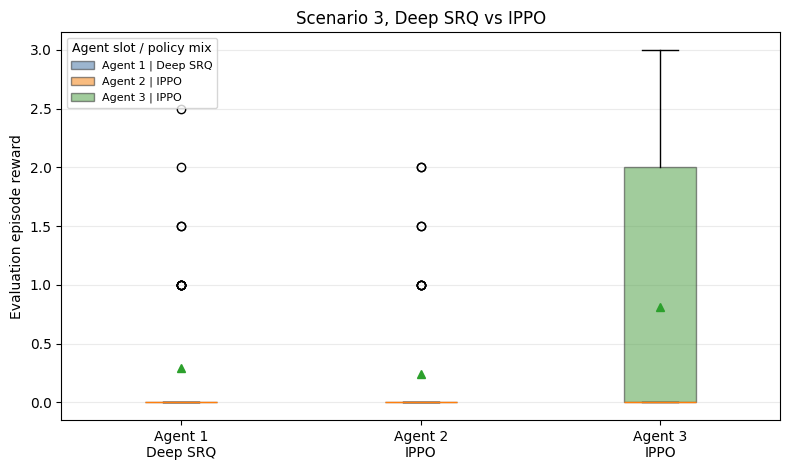

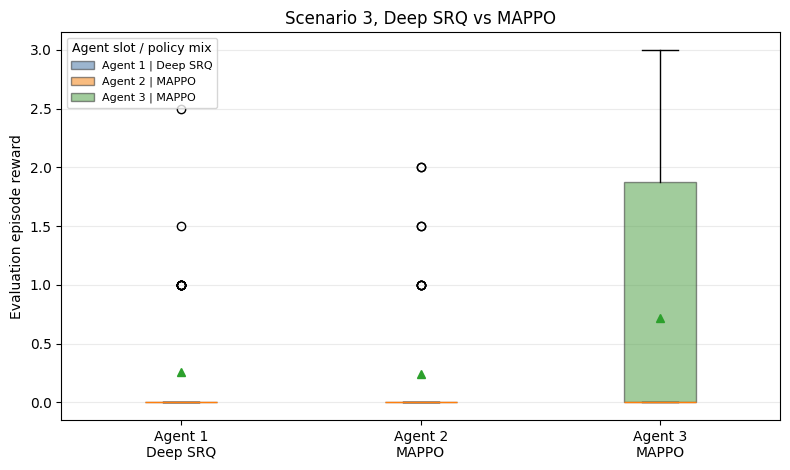

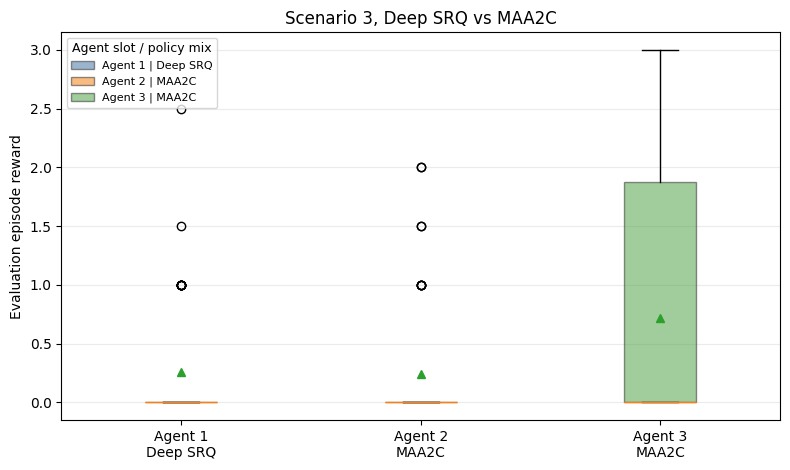

In [6]:
deep_srq_path_pool_eval_eps_1_0 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    1.0,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_1_0)
